In [13]:
import numpy as np

def load_rowland_sessions(npz_path):
    """Load sessions from the exported .npz file."""
    data = np.load(npz_path, allow_pickle=True)
    session_ids = data['session_ids']
    
    sessions = {}
    for sid in session_ids:
        prefix = f"session_{sid}_"
        sessions[sid] = {
            'signature': str(data[f'{prefix}signature']),
            'mouse': str(data[f'{prefix}mouse']),
            'run_number': int(data[f'{prefix}run_number']),
            'name': str(data[f'{prefix}name']),
            'filter_ps_time': data[f'{prefix}filter_ps_time'],
            'behaviour_trials': data[f'{prefix}behaviour_trials'],
            'is_target': data[f'{prefix}is_target'],
            'trial_subsets': data[f'{prefix}trial_subsets'],
            'n_cells': int(data[f'{prefix}n_cells']),
            'n_trials': int(data[f'{prefix}n_trials']),
            'n_times': int(data[f'{prefix}n_times']),
            's1_bool': data[f'{prefix}s1_bool'],
            's2_bool': data[f'{prefix}s2_bool'],
            'outcome': data[f'{prefix}outcome'],
            'frequency': float(data[f'{prefix}frequency']),
        }
    return sessions

In [14]:
sessions=load_rowland_sessions('/home/patriciobarber/AdaptiveLatents/workspace/datasets/rowland23/all_sessions.npz')

In [15]:
s0 = sessions[0]

In [16]:
# --- CORRECTION OF TIMING ---
# Shift timing so that t=0 is one timepoint earlier
time_axis = s0['filter_ps_time']
dt = time_axis[1] - time_axis[0]
print(f"Original Time Range: {time_axis.min():.4f} to {time_axis.max():.4f}")

# The user wants the current index for 0 to now be +dt (or rather, the index -1 is the new 0).
# If correct t=0 is one timepoint BEFORE current t=0:
# Current: ... t[-1]=-dt, t[0]=0, t[1]=dt ...
# New:     ... t[-1]=0,   t[0]=dt, ... (This shifts time array to the right? No.)

# "stimulus onset 1 timepoint before before what is currently indicated"
# Current 0 is at index `zero_idx`.
# We want index `zero_idx - 1` to be the new 0.
# So we need to ADD `dt` to the time axis? 
# If t[zero_idx] = 0, and we want t[zero_idx-1] = 0.
# Currently t[zero_idx-1] = -dt. 
# To make it 0, we add dt. 
# Then t[zero_idx] becomes dt.

s0['filter_ps_time'] = s0['filter_ps_time'] + dt
time_axis = s0['filter_ps_time']
zero_idx = np.argmin(np.abs(time_axis))

print(f"Corrected Time Range: {time_axis.min():.4f} to {time_axis.max():.4f}")
print(f"New Stimulus Onset Index: {zero_idx}, Time: {time_axis[zero_idx]:.4f}s")

Original Time Range: -7.9667 to 6.0000
Corrected Time Range: -7.9333 to 6.0333
New Stimulus Onset Index: 238, Time: -0.0000s


In [17]:
import time
import builtins # Force built-in min
from dPCA import dPCA
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.patches as mpatches

# --- 1. Data Preparation (Standard 80/20 Split) ---
start_time = time.time()

# Extract data
neural_data = s0['behaviour_trials']  # (N, n_trials, T)
trial_subsets = s0['trial_subsets']   # Magnitude of stim per trial
n_trials = s0['n_trials']

# Standard random 80/20 split
all_indices = np.arange(n_trials)
train_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)
train_indices = np.sort(train_indices)
test_indices = np.sort(test_indices)

print(f"Data Split: {len(train_indices)} Training trials, {len(test_indices)} Test trials")
print(f"Training trial index range: [{train_indices.min()}, {train_indices.max()}]")

# Prepare dPCA data strictly from TRAINING trials only
unique_conditions = np.unique(trial_subsets)
trials_per_cond_train = {
    cond: np.intersect1d(np.where(trial_subsets == cond)[0], train_indices)
    for cond in unique_conditions
}

# Balanced trial count required by dPCA trial tensor shape (trials, N, S, T)
min_trials_train = builtins.min([len(t) for t in trials_per_cond_train.values()])

N, T = s0['n_cells'], s0['n_times']
S = len(unique_conditions)

# Construct trialR for dPCA (min_trials_train, N, S, T)
# Use random sampling from each training-condition pool to avoid biasing to earliest indices
rng = np.random.default_rng(42)
trialR = np.zeros((min_trials_train, N, S, T))
for s, cond in enumerate(unique_conditions):
    pool = trials_per_cond_train[cond]
    selected_trials = rng.choice(pool, size=min_trials_train, replace=False)
    for i, t_idx in enumerate(selected_trials):
        trialR[i, :, s, :] = neural_data[:, t_idx, :]

# Averaged R (N, S, T), centered from training-only trialR
R = np.mean(trialR, axis=0)
R_centered = R - np.mean(R.reshape((N, -1)), axis=1)[:, None, None]

print(f"dPCA Data Prepared from TRAIN ONLY. Shape: {trialR.shape}")
print(f"Balanced trials per condition used for dPCA fit: {min_trials_train}")
print(f"Preparation time: {time.time() - start_time:.4f}s")

Data Split: 129 Training trials, 33 Test trials
Training trial index range: [0, 161]
dPCA Data Prepared from TRAIN ONLY. Shape: (6, 471, 8, 420)
Balanced trials per condition used for dPCA fit: 6
Preparation time: 0.0416s


In [18]:
t0 = time.time()

dpca = dPCA.dPCA(labels='st', regularizer='auto', n_components=10)
dpca.protect = ['t']
Z = dpca.fit_transform(R_centered, trialR)

print(f"dPCA Fitting time: {time.time() - t0:.4f}s")

# --- Exponential Moving Average for smoothing dPCA trajectories ---
EMA_ALPHA = 0.3  # Smoothing factor: higher = less smoothing, lower = more smoothing

def apply_ema(z, alpha=EMA_ALPHA):
    """Apply exponential moving average along the time axis.
    z: (n_trials, T, d_z) array
    alpha: smoothing factor in (0, 1]. 1.0 = no smoothing.
    Returns smoothed array of same shape.
    """
    if z.ndim == 2:
        # (T, d_z)
        out = np.empty_like(z)
        out[0] = z[0]
        for t in range(1, z.shape[0]):
            out[t] = alpha * z[t] + (1 - alpha) * out[t - 1]
        return out
    elif z.ndim == 3:
        # (n_trials, T, d_z)
        out = np.empty_like(z)
        out[:, 0, :] = z[:, 0, :]
        for t in range(1, z.shape[1]):
            out[:, t, :] = alpha * z[:, t, :] + (1 - alpha) * out[:, t - 1, :]
        return out
    else:
        raise ValueError(f"Expected 2D or 3D array, got {z.ndim}D")

print(f"EMA smoothing function defined with alpha={EMA_ALPHA}")

You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set by changing self.n_trials (default = 3). Similarly,
                    use self.protect to set the list of axes that are not supposed to get to get shuffled
                    (e.g. upon splitting the data into test- and training, time-points should always
                    be drawn from the same trial, i.e. self.protect = ['t']). This can significantly
                    speed up the code.
Start optimizing regularization.
Starting trial  1 / 3
Starting trial  2 / 3
Starting trial  3 / 3
Optimized regularization, optimal lambda =  0.0008819763977946266
Regularization will be fixed; to compute the optimal                    parameter again on the next fit, please                    set opt_regularizer_flag to True.
dPCA Fitting time: 12.5245s
EMA smoothing function

## GRU Forecasting in dPCA Space with Full Stimulation Vector

We model trial-wise latent dynamics in dPCA space using a controlled recurrent model. For each trial:

- Latent state: $\mathbf{z}_t \in \mathbb{R}^{d_z}$ (dPCA coordinates; here we concatenate $s$, $t$, and $st$ marginals)
- Stimulation vector: $\mathbf{v}_t \in \{0,1\}^{n_{\text{cells}}}$, where
  $$
  v_t[i] =
  \begin{cases}
  1, & \text{if neuron } i \text{ is photostimulated at time } t\\
  0, & \text{otherwise}
  \end{cases}
  $$

### Data Split

We use a standard random $80/20$ train-test split over trials.

### Priming and Controlled Prediction

Let $t_0$ be the stimulus-onset index and $H=20$ the forecast horizon.

- **Priming context**: all steps up to and including onset, $t \le t_0$
- **Predicted window**: $t \in \{t_0+1, \dots, t_0+H\}$

Encoder GRU:
$$
\mathbf{h}_t = \mathrm{GRU}_{\text{enc}}\left([\mathbf{z}_t, \mathbf{v}_t], \mathbf{h}_{t-1}\right), \quad t \le t_0
$$

Decoder GRUCell (autoregressive):
$$
\mathbf{h}^{\text{dec}}_{k} = \mathrm{GRU}_{\text{dec}}\left([\tilde{\mathbf{z}}_{k-1}, \mathbf{v}_{t_0+k}], \mathbf{h}^{\text{dec}}_{k-1}\right)
$$
$$
\hat{\mathbf{z}}_{t_0+k+1} = W_o\mathbf{h}^{\text{dec}}_{k} + b_o
$$
for $k=0,\dots,H-1$, so the model receives the onset latent state before predicting and also receives stimulus vectors during rollout.

### Variance-Weighted Loss & Metrics

From training data, define per-component variance weights:
$$
w_j = \frac{\mathrm{Var}(z_j)}{\sum_{m=1}^{d_z} \mathrm{Var}(z_m)}, \quad \sum_j w_j = 1.
$$

**Training loss** — variance-weighted MSE, so that high-variance (more informative) components contribute proportionally more to the gradient signal:
$$
\mathcal{L} = \sum_{j=1}^{d_z} w_j \cdot \frac{1}{BH}\sum_{b=1}^{B}\sum_{h=1}^{H}\left(\hat{z}_{b,h,j} - z_{b,h,j}\right)^2
$$

**Evaluation metrics** at each horizon step $h$:

- Per-component MSE: $\mathrm{MSE}_{h,j}$
- Per-component $R^2$: $R^2_{h,j}$

Weighted metrics:
$$
\mathrm{MSE}^{\text{w}}_h = \sum_{j=1}^{d_z} w_j\,\mathrm{MSE}_{h,j},
\qquad
R^{2,\text{w}}_h = \sum_{j=1}^{d_z} w_j\,R^2_{h,j}.
$$

### Hyperparameters

- Forecast horizon: $H=20$
- Hidden size: $256$
- Decoder/encoder layers: $2$
- Batch size: $32$
- Epochs: $120$
- Optimizer: Adam ($\text{lr}=10^{-3}$, weight decay $10^{-5}$)
- Gradient clipping: $1.0$
- Teacher forcing ratio: linearly decayed from $0.7$ to $0.1$

### Visualization

- Weighted MSE and weighted $R^2$ vs forecast horizon ($t+1$ to $t+20$)
- Trial-specific trajectories for trial 34 in first 3 components
- Includes 5 timesteps before onset in 2D trajectory plots
- 3D plot compares equal-length post-onset trajectories (actual vs predicted)

Applied EMA smoothing (alpha=0.3) to dPCA trajectories
z_trial shape: (162, 420, 30)
stim vector shape: (162, 420, 471)
context_len=239, horizon=20, d_z=30, n_cells=471
Priming: model consumes timesteps <= onset (includes onset latent state), then predicts from t0+1 onward.
Epoch 001/120 | train_loss=1.291959 | test_loss=0.942392 | teacher_forcing=0.700
Epoch 020/120 | train_loss=0.138472 | test_loss=0.243202 | teacher_forcing=0.604
Epoch 040/120 | train_loss=0.076822 | test_loss=0.246630 | teacher_forcing=0.503
Epoch 060/120 | train_loss=0.074394 | test_loss=0.176791 | teacher_forcing=0.403
Epoch 080/120 | train_loss=0.077783 | test_loss=0.151652 | teacher_forcing=0.302
Epoch 100/120 | train_loss=0.065866 | test_loss=0.185906 | teacher_forcing=0.201
Epoch 120/120 | train_loss=0.070202 | test_loss=0.148682 | teacher_forcing=0.100


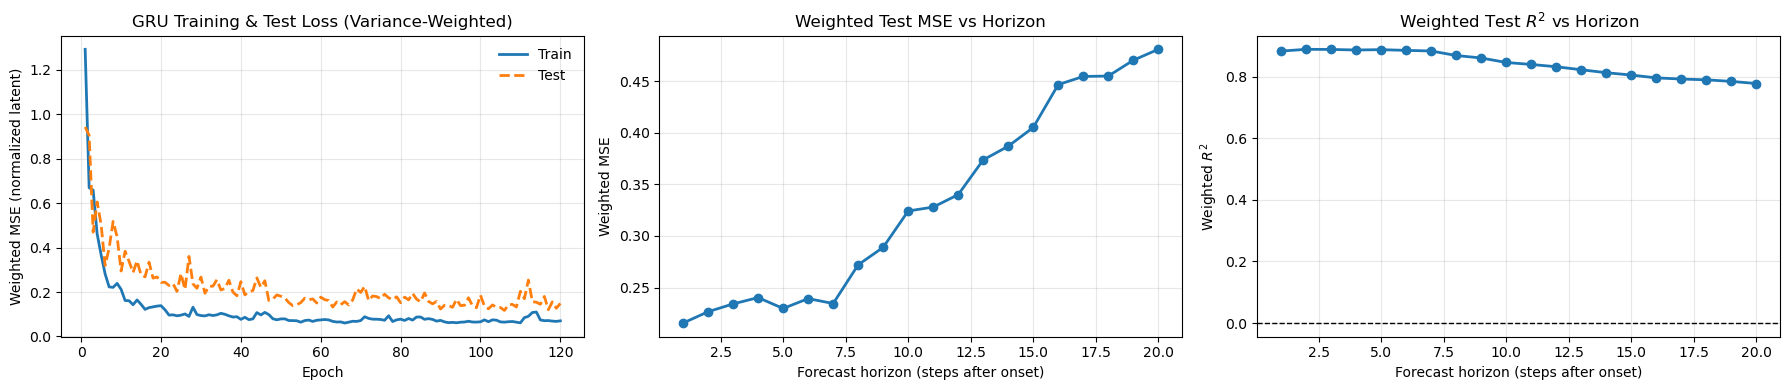

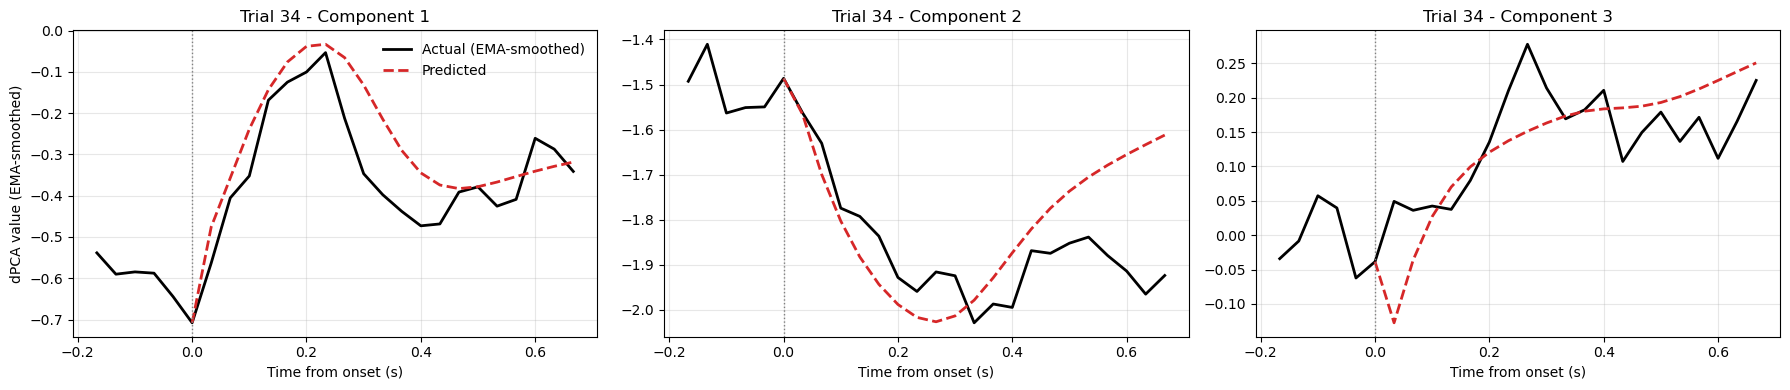

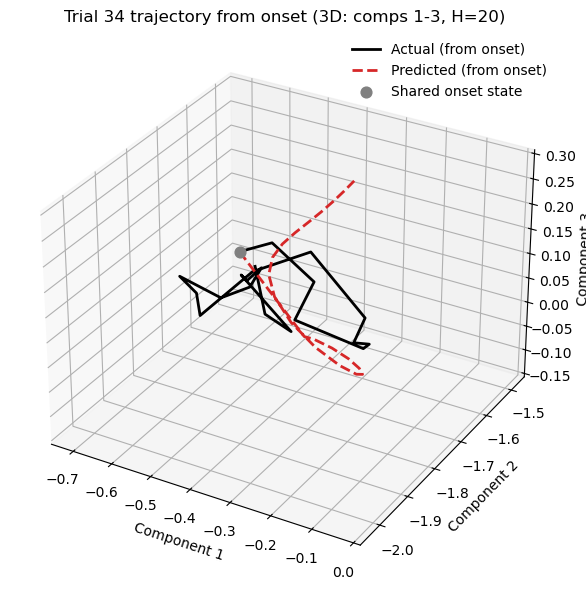

Timing:
Training time: 21.9841 s total (0.1832 s/epoch)
Inference time (test batch of 33 trials, horizon=20): 0.008333 s
Inference time per trial: 0.000253 s
Weighted horizon-wise metrics (first 5 shown):
t+01: weighted MSE=0.21559, weighted R2=0.88375
t+02: weighted MSE=0.22658, weighted R2=0.88953
t+03: weighted MSE=0.23415, weighted R2=0.88911
t+04: weighted MSE=0.24026, weighted R2=0.88735
t+05: weighted MSE=0.22971, weighted R2=0.88843


In [19]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# -----------------------------
# 1) Build trial-wise trajectories in dPCA space and stimulus vectors
# -----------------------------

# Center all trials using the same mean used for dPCA fitting
stim_mean = np.mean(R.reshape((N, -1)), axis=1)[:, None, None]
neural_centered = neural_data - stim_mean

# Project each trial into dPCA marginals
z_all = dpca.transform(neural_centered)  # dict: each value is (n_comp, n_trials, T)

# Concatenate marginals to define full dPCA latent vector
z_trial = np.concatenate([z_all['s'], z_all['t'], z_all['st']], axis=0)  # (d_z, n_trials, T)
z_trial = np.transpose(z_trial, (1, 2, 0)).astype(np.float32)  # (n_trials, T, d_z)

# Apply EMA smoothing to dPCA trajectories
z_trial = apply_ema(z_trial, alpha=EMA_ALPHA)
print(f"Applied EMA smoothing (alpha={EMA_ALPHA}) to dPCA trajectories")

# Full stimulation vector over time (trial, time, neuron)
v = np.transpose(s0['is_target'], (1, 2, 0)).astype(np.float32)  # (n_trials, T, n_cells)

n_trials_total, T_total, d_z = z_trial.shape
n_cells = v.shape[-1]

# Forecast setup
horizon = 20
context_len = zero_idx + 1  # model is primed with t <= onset (includes onset state)
assert context_len > 1, "Need at least 2 context steps."
assert zero_idx + 1 + horizon <= T_total, "Not enough post-onset steps for requested horizon."

# Normalization from training split only
z_train = z_trial[train_indices]
z_mean = z_train.mean(axis=(0, 1), keepdims=True)
z_std = z_train.std(axis=(0, 1), keepdims=True) + 1e-6
z_trial_n = (z_trial - z_mean) / z_std

# Variance contribution weights per latent component (from train set)
component_var = z_train.var(axis=(0, 1))
component_weights = component_var / (component_var.sum() + 1e-12)

print(f"z_trial shape: {z_trial.shape}")
print(f"stim vector shape: {v.shape}")
print(f"context_len={context_len}, horizon={horizon}, d_z={d_z}, n_cells={n_cells}")
print("Priming: model consumes timesteps <= onset (includes onset latent state), then predicts from t0+1 onward.")

# -----------------------------
# 2) Dataset
# -----------------------------

class OnsetForecastDataset(Dataset):
    def __init__(self, trial_indices):
        self.trial_indices = np.array(trial_indices)

    def __len__(self):
        return len(self.trial_indices)

    def __getitem__(self, idx):
        tr = self.trial_indices[idx]
        context_z = z_trial_n[tr, :context_len, :]                           # up to onset inclusive
        context_v = v[tr, :context_len, :]
        future_v = v[tr, zero_idx + 1:zero_idx + 1 + horizon, :]             # stimulus for predicted steps
        target_z = z_trial_n[tr, zero_idx + 1:zero_idx + 1 + horizon, :]     # predict t0+1 ... t0+horizon
        return (
            torch.from_numpy(context_z),
            torch.from_numpy(context_v),
            torch.from_numpy(future_v),
            torch.from_numpy(target_z),
        )

train_ds = OnsetForecastDataset(train_indices)
test_ds = OnsetForecastDataset(test_indices)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=len(test_ds), shuffle=False)

# -----------------------------
# 3) GRU model with stimulus control input
# -----------------------------

class GRUStimForecast(nn.Module):
    def __init__(self, latent_dim, stim_dim, hidden_dim=256, num_layers=2, dropout=0.0):
        super().__init__()
        self.encoder = nn.GRU(
            input_size=latent_dim + stim_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0,
        )
        self.num_layers = num_layers
        self.decoder_cells = nn.ModuleList()
        self.decoder_cells.append(nn.GRUCell(latent_dim + stim_dim, hidden_dim))
        for _ in range(1, num_layers):
            self.decoder_cells.append(nn.GRUCell(hidden_dim, hidden_dim))
        self.readout = nn.Linear(hidden_dim, latent_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, context_z, context_v, future_v, target_z=None, teacher_forcing=0.0):
        enc_in = torch.cat([context_z, context_v], dim=-1)
        _, h_n = self.encoder(enc_in)
        h = h_n[-1]  # (batch, hidden)

        # Starts from onset latent state (last context step)
        prev_z = context_z[:, -1, :]
        preds = []
        H = future_v.shape[1]

        for k in range(H):
            dec_in = torch.cat([prev_z, future_v[:, k, :]], dim=-1)
            h_in = dec_in
            h_new = []
            for layer_idx, cell in enumerate(self.decoder_cells):
                h_l = cell(h_in, h_n[layer_idx])
                h_l = self.dropout(h_l)
                h_new.append(h_l)
                h_in = h_l
            h_n = torch.stack(h_new, dim=0)
            pred_z = self.readout(h_n[-1])
            preds.append(pred_z.unsqueeze(1))

            if self.training and target_z is not None and teacher_forcing > 0.0:
                use_teacher = (torch.rand(pred_z.shape[0], device=pred_z.device) < teacher_forcing).float().unsqueeze(-1)
                prev_z = use_teacher * target_z[:, k, :] + (1.0 - use_teacher) * pred_z
            else:
                prev_z = pred_z

        return torch.cat(preds, dim=1)

# -----------------------------
# 4) Train (timed) – variance-weighted MSE loss
# -----------------------------

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GRUStimForecast(latent_dim=d_z, stim_dim=n_cells, hidden_dim=256, num_layers=2, dropout=0.1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# Variance-weighted MSE: weight each component by its share of total variance
component_weights_t = torch.from_numpy(component_weights).float().to(device)

def weighted_mse_loss(pred, target, weights):
    """Compute variance-weighted MSE: average over batch & horizon, then weight per component."""
    per_comp_mse = ((pred - target) ** 2).mean(dim=(0, 1))  # (d_z,)
    return (weights * per_comp_mse).sum()

n_epochs = 120
loss_history = []
test_loss_history = []

train_t0 = time.perf_counter()
for epoch in range(1, n_epochs + 1):
    model.train()
    running_loss = 0.0

    tf_ratio = 0.7 + (0.1 - 0.7) * ((epoch - 1) / max(n_epochs - 1, 1))

    for context_z_b, context_v_b, future_v_b, target_z_b in train_loader:
        context_z_b = context_z_b.to(device)
        context_v_b = context_v_b.to(device)
        future_v_b = future_v_b.to(device)
        target_z_b = target_z_b.to(device)

        optimizer.zero_grad()
        pred_z_b = model(context_z_b, context_v_b, future_v_b, target_z=target_z_b, teacher_forcing=tf_ratio)
        loss = weighted_mse_loss(pred_z_b, target_z_b, component_weights_t)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running_loss += loss.item() * context_z_b.shape[0]

    epoch_loss = running_loss / len(train_ds)
    loss_history.append(epoch_loss)

    # Compute test loss (open-loop, no teacher forcing)
    model.eval()
    with torch.no_grad():
        test_running = 0.0
        for context_z_b, context_v_b, future_v_b, target_z_b in test_loader:
            context_z_b = context_z_b.to(device)
            context_v_b = context_v_b.to(device)
            future_v_b = future_v_b.to(device)
            target_z_b = target_z_b.to(device)
            pred_z_b = model(context_z_b, context_v_b, future_v_b, target_z=None, teacher_forcing=0.0)
            test_running += weighted_mse_loss(pred_z_b, target_z_b, component_weights_t).item() * context_z_b.shape[0]
        test_loss_history.append(test_running / len(test_ds))

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d}/{n_epochs} | train_loss={epoch_loss:.6f} | test_loss={test_loss_history[-1]:.6f} | teacher_forcing={tf_ratio:.3f}")

training_time_sec = time.perf_counter() - train_t0

# -----------------------------
# 5) Evaluate weighted horizon-wise metrics on test set
# -----------------------------

model.eval()
with torch.no_grad():
    (context_z_t, context_v_t, future_v_t, target_z_t) = next(iter(test_loader))
    context_z_t = context_z_t.to(device)
    context_v_t = context_v_t.to(device)
    future_v_t = future_v_t.to(device)

    if device.type == 'cuda':
        torch.cuda.synchronize()
    infer_t0 = time.perf_counter()
    pred_z_t = model(context_z_t, context_v_t, future_v_t, target_z=None, teacher_forcing=0.0)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    inference_time_sec = time.perf_counter() - infer_t0

pred_z_t = pred_z_t.cpu().numpy()
target_z_t = target_z_t.numpy()

pred_z = pred_z_t * z_std + z_mean
target_z = target_z_t * z_std + z_mean

horizons = np.arange(1, horizon + 1)
weighted_mse_by_h = []
weighted_r2_by_h = []

for h in range(horizon):
    y_true_h = target_z[:, h, :]
    y_pred_h = pred_z[:, h, :]

    mse_per_comp = np.mean((y_pred_h - y_true_h) ** 2, axis=0)
    weighted_mse = float(np.sum(component_weights * mse_per_comp))

    r2_per_comp = np.zeros(d_z, dtype=np.float64)
    for comp in range(d_z):
        if np.var(y_true_h[:, comp]) < 1e-12:
            r2_per_comp[comp] = 0.0
        else:
            r2_per_comp[comp] = r2_score(y_true_h[:, comp], y_pred_h[:, comp])
    weighted_r2 = float(np.sum(component_weights * r2_per_comp))

    weighted_mse_by_h.append(weighted_mse)
    weighted_r2_by_h.append(weighted_r2)

# -----------------------------
# 6) Plot training curve + weighted horizon-wise MSE and R^2
# -----------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(np.arange(1, n_epochs + 1), loss_history, lw=2, label='Train')
axes[0].plot(np.arange(1, n_epochs + 1), test_loss_history, lw=2, ls='--', label='Test')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Weighted MSE (normalized latent)')
axes[0].set_title('GRU Training & Test Loss (Variance-Weighted)')
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.3)

axes[1].plot(horizons, weighted_mse_by_h, marker='o', lw=2)
axes[1].set_xlabel('Forecast horizon (steps after onset)')
axes[1].set_ylabel('Weighted MSE')
axes[1].set_title('Weighted Test MSE vs Horizon')
axes[1].grid(alpha=0.3)

axes[2].plot(horizons, weighted_r2_by_h, marker='o', lw=2)
axes[2].axhline(0.0, color='k', ls='--', lw=1)
axes[2].set_xlabel('Forecast horizon (steps after onset)')
axes[2].set_ylabel('Weighted $R^2$')
axes[2].set_title('Weighted Test $R^2$ vs Horizon')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------
# 7) Trial 34 trajectories: include 5 pre-onset timesteps in 2D plots
# -----------------------------

trial_id = 34
pre_steps = 5
assert 0 <= trial_id < n_trials_total, f"trial_id must be in [0, {n_trials_total - 1}]"
assert zero_idx - pre_steps >= 0, "Not enough pre-onset timesteps to plot 5 steps before onset."

context_z_single = torch.from_numpy(z_trial_n[trial_id, :context_len, :]).unsqueeze(0).to(device)
context_v_single = torch.from_numpy(v[trial_id, :context_len, :]).unsqueeze(0).to(device)
future_v_single = torch.from_numpy(v[trial_id, zero_idx + 1:zero_idx + 1 + horizon, :]).unsqueeze(0).to(device)
with torch.no_grad():
    pred_single_n = model(context_z_single, context_v_single, future_v_single, target_z=None, teacher_forcing=0.0)

pred_single = pred_single_n.squeeze(0).cpu().numpy() * z_std.squeeze((0, 1)) + z_mean.squeeze((0, 1))

start_idx = zero_idx - pre_steps
end_idx = zero_idx + 1 + horizon
t_window = time_axis[start_idx:end_idx]
true_window = z_trial[trial_id, start_idx:end_idx, :]  # includes pre, onset, and post

pred_window = np.full((pre_steps + 1 + horizon, d_z), np.nan, dtype=np.float32)
pred_window[pre_steps, :] = true_window[pre_steps, :]      # onset anchor (given to model)
pred_window[pre_steps + 1:, :] = pred_single               # predictions from t0+1 onward

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
for comp in range(3):
    axes[comp].plot(t_window, true_window[:, comp], lw=2, label='Actual (EMA-smoothed)', color='black')
    axes[comp].plot(t_window, pred_window[:, comp], lw=2, ls='--', label='Predicted', color='tab:red')
    axes[comp].axvline(0.0, color='gray', ls=':', lw=1)
    axes[comp].set_title(f'Trial {trial_id} - Component {comp + 1}')
    axes[comp].set_xlabel('Time from onset (s)')
    axes[comp].grid(alpha=0.3)

axes[0].set_ylabel('dPCA value (EMA-smoothed)')
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

# 3D trajectory plot (components 1-3) — both trajectories start at onset
true_post = z_trial[trial_id, zero_idx + 1:zero_idx + 1 + horizon, :]
onset_state = z_trial[trial_id, zero_idx, :]

# Prepend onset state so both lines share the same starting point
true_from_onset = np.vstack([onset_state[None, :], true_post])
pred_from_onset = np.vstack([onset_state[None, :], pred_single])

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(true_from_onset[:, 0], true_from_onset[:, 1], true_from_onset[:, 2], color='black', lw=2, label='Actual (from onset)')
ax.plot(pred_from_onset[:, 0], pred_from_onset[:, 1], pred_from_onset[:, 2], color='tab:red', lw=2, ls='--', label='Predicted (from onset)')

ax.scatter(onset_state[0], onset_state[1], onset_state[2], color='gray', s=60, zorder=5, label='Shared onset state')

ax.set_title(f'Trial {trial_id} trajectory from onset (3D: comps 1-3, H={horizon})')
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.set_zlabel('Component 3')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print('Timing:')
print(f"Training time: {training_time_sec:.4f} s total ({training_time_sec / n_epochs:.4f} s/epoch)")
print(f"Inference time (test batch of {len(test_ds)} trials, horizon={horizon}): {inference_time_sec:.6f} s")
print(f"Inference time per trial: {inference_time_sec / max(len(test_ds), 1):.6f} s")

print('Weighted horizon-wise metrics (first 5 shown):')
for h in range(min(5, horizon)):
    print(f"t+{h+1:02d}: weighted MSE={weighted_mse_by_h[h]:.5f}, weighted R2={weighted_r2_by_h[h]:.5f}")

## GRU with Peri-Onset Noise Augmentation (Stimulated Trials Only)

The original training set has a limited number of trials, each contributing one context→forecast example centred on stimulation onset. To increase the effective dataset size around this critical event, we apply **online Gaussian noise injection** restricted to a 10-timestep peri-onset window — **but only for trials where stimulation actually occurred**.

### Identifying Stimulated Trials

A trial $i$ is classified as *stimulated* when its binary stimulation vector is non-zero at any time and neuron:
$$
\text{stimulated}(i) = \mathbb{1}\!\left[\sum_{t,c} v_t^{(i)}[c] > 0\right]
$$
This is determined from `s0['is_target']`. Non-stimulated (control) trials are included in the dataset **as clean samples only** — they receive no noisy copies, since the event of interest (stimulation) did not occur.

### Augmentation Strategy

For each **stimulated** training trial $i$ and each epoch, the augmented dataset generates $K$ noisy copies in addition to the original (clean) sample. For each copy $k \in \{1, \dots, K\}$:

1. **Select the peri-onset window** of $W = 10$ timesteps ($5$ pre-onset + $5$ post-onset):
   $$
   \mathcal{W} = \{t_0 - 5,\;\dots,\;t_0 + 4\}
   $$

2. **Sample per-component Gaussian noise** scaled by a fraction $\sigma_{\text{frac}}$ of the training-set per-component standard deviation:
   $$
   \epsilon_{t,j} \sim \mathcal{N}\!\left(0,\;\left(\sigma_{\text{frac}} \cdot \hat{\sigma}_j\right)^2\right), \quad t \in \mathcal{W}
   $$
   where $\hat{\sigma}_j$ is the standard deviation of the $j$-th normalized latent component computed from the training set.

3. **Inject noise only inside the window**: timesteps outside $\mathcal{W}$ are left unchanged. This ensures the model sees diverse peri-stimulus dynamics while preserving the clean baseline and distant-horizon structure.

4. **Stimulation vectors are never perturbed** — they are binary ground truth and must stay exact.

### Implementation Details

- Noise is generated **on-the-fly** (a fresh draw every epoch), so the model never sees the same augmented sample twice. This acts as an implicit regulariser.
- The noise scale $\sigma_{\text{frac}}$ is set conservatively (default $0.15$) to stay within the manifold of plausible trajectories.
- The augmented dataset size is $N_{\text{stim}} \times (1 + K) + N_{\text{ctrl}}$ per epoch, where $N_{\text{stim}}$ and $N_{\text{ctrl}}$ are the numbers of stimulated and control training trials respectively.
- **Test data is never augmented** — evaluation remains on clean, unperturbed trials for a fair comparison.


### Hyperparameters (unchanged unless noted)| All other GRU hyperparameters | Same as baseline cell above |

| Peri-onset window ($W$) | 10 (5 pre + 5 post) |

| Parameter | Value || Noise scale ($\sigma_{\text{frac}}$) | 0.15 |

|---|---|| Noise copies per trial ($K$) | 5 (stimulated trials only) |

Augmentation window: timesteps [233, 243) (10 steps, centered on onset at 238)
Noise std per component (first 5): [0.14999995 0.14999987 0.1499998  0.14999978 0.14999956]
Training trials: 82 stimulated, 47 control
Stimulated trials → 1 clean + 15 noisy = 16 samples each
Control trials → 1 clean sample each (no augmentation)
Effective train size per epoch: 1359


[Aug] Epoch 001/120 | loss=0.452694 | test_loss=0.396634 | tf=0.700
[Aug] Epoch 020/120 | loss=0.028797 | test_loss=0.154259 | tf=0.604
[Aug] Epoch 040/120 | loss=0.022501 | test_loss=0.117083 | tf=0.503
[Aug] Epoch 060/120 | loss=0.021716 | test_loss=0.126743 | tf=0.403
[Aug] Epoch 080/120 | loss=0.022055 | test_loss=0.135417 | tf=0.302
[Aug] Epoch 100/120 | loss=0.022819 | test_loss=0.156272 | tf=0.201
[Aug] Epoch 120/120 | loss=0.020516 | test_loss=0.197298 | tf=0.100


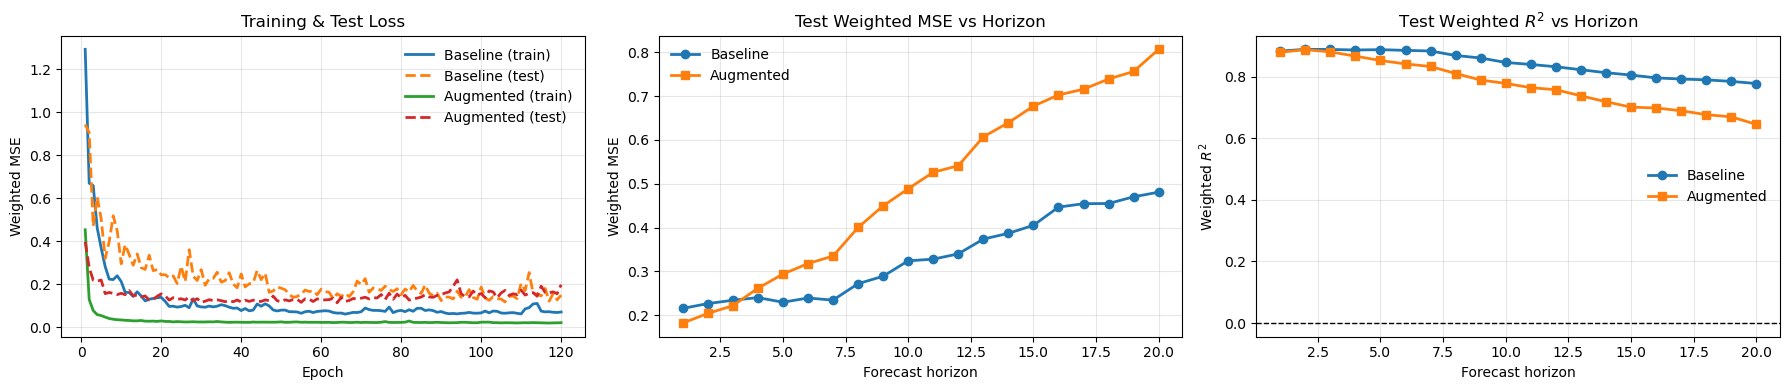

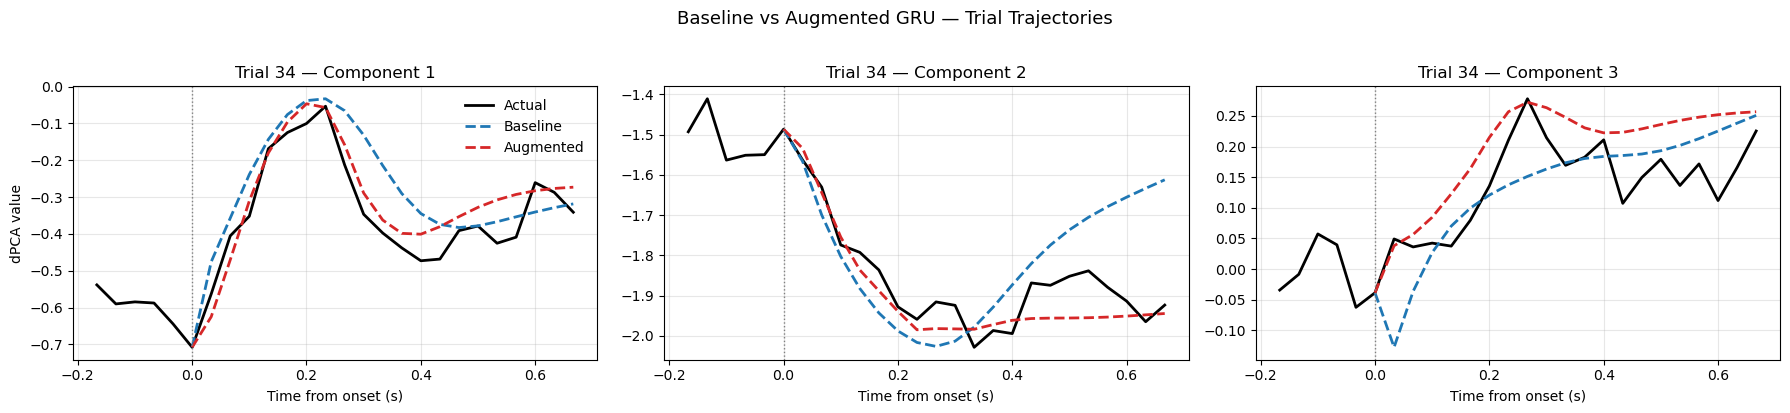

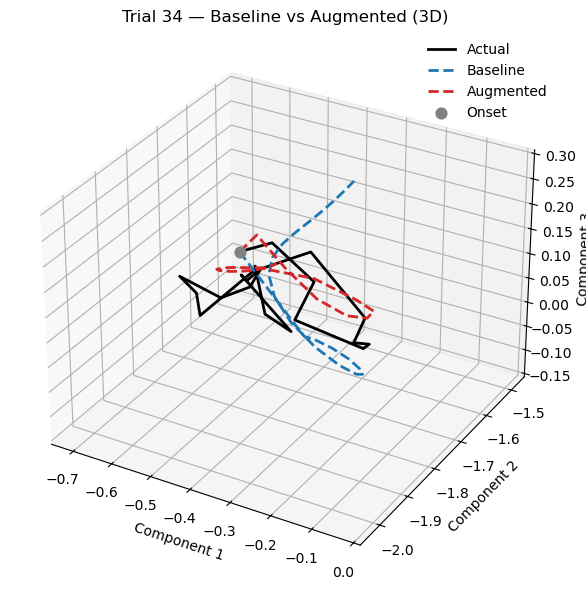

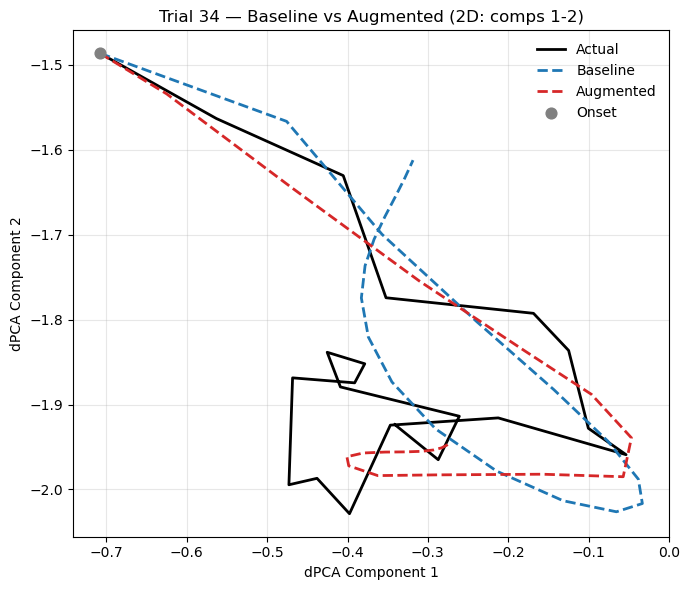

Training time (augmented): 642.89 s (5.3574 s/epoch)
Inference time (augmented): 0.049359 s

Weighted metrics comparison (first 5 horizons):
   h    Base MSE    Aug MSE     Base R²     Aug R²
t+01     0.21559    0.18219     0.88375    0.87998
t+02     0.22658    0.20407     0.88953    0.88826
t+03     0.23415    0.22180     0.88911    0.88144
t+04     0.24026    0.26161     0.88735    0.86727
t+05     0.22971    0.29382     0.88843    0.85320


In [20]:
# =============================================================================
# GRU with peri-onset noise augmentation
# =============================================================================

# --- Augmentation parameters ---
n_augment = 15         # noisy copies per stimulated trial
noise_frac = 0.15      # noise std as fraction of per-component training std
aug_half_win = 5       # half-window: 5 pre + 5 post = 10 timesteps around onset

# Per-component std of normalized training latents (should be ~1 after z-scoring,
# but we compute it explicitly to be safe)
z_train_n = z_trial_n[train_indices]
z_comp_std = z_train_n.std(axis=(0, 1))  # (d_z,)
noise_std = (noise_frac * z_comp_std).astype(np.float32)

# Peri-onset window indices (clipped to valid range)
aug_start = max(zero_idx - aug_half_win, 0)
aug_end = min(zero_idx + aug_half_win, T_total)

# Identify stimulated trials: v[trial] has any non-zero entry across time & neurons
is_stimulated = v.reshape(v.shape[0], -1).any(axis=1)  # (n_trials_total,)
train_stim_mask = is_stimulated[train_indices]
n_stim_train = int(train_stim_mask.sum())
n_ctrl_train = len(train_indices) - n_stim_train

print(f"Augmentation window: timesteps [{aug_start}, {aug_end}) "
      f"({aug_end - aug_start} steps, centered on onset at {zero_idx})")
print(f"Noise std per component (first 5): {noise_std[:5]}")
print(f"Training trials: {n_stim_train} stimulated, {n_ctrl_train} control")
print(f"Stimulated trials → 1 clean + {n_augment} noisy = {1 + n_augment} samples each")
print(f"Control trials → 1 clean sample each (no augmentation)")
print(f"Effective train size per epoch: {n_stim_train * (1 + n_augment) + n_ctrl_train}")

# -----------------------------
# 1) Augmented dataset — generates noise on-the-fly each epoch
# -----------------------------

class AugmentedOnsetForecastDataset(Dataset):
    """Training dataset that augments *only stimulated trials* with peri-onset noise.

    The flat index list is built as:
      - For each stimulated trial: 1 clean + n_augment noisy copies
      - For each control trial:    1 clean copy only

    Noise is re-sampled every __getitem__ call, so each epoch sees different
    perturbations (acts as implicit regularisation).
    """

    def __init__(self, trial_indices, stim_mask, n_augment, noise_std, aug_start, aug_end):
        self.noise_std = noise_std          # (d_z,) — numpy
        self.aug_start = aug_start
        self.aug_end = aug_end

        # Build flat item list: (trial_index, copy_idx) where copy_idx=0 is clean
        self.items = []
        for i, tr in enumerate(trial_indices):
            self.items.append((tr, 0))                       # clean
            if stim_mask[i]:                                  # stimulated → add noisy copies
                for k in range(1, n_augment + 1):
                    self.items.append((tr, k))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        tr, copy_idx = self.items[idx]

        context_z = z_trial_n[tr, :context_len, :].copy()
        context_v = v[tr, :context_len, :]
        future_v  = v[tr, zero_idx + 1:zero_idx + 1 + horizon, :]
        target_z  = z_trial_n[tr, zero_idx + 1:zero_idx + 1 + horizon, :].copy()

        if copy_idx > 0:
            # Inject noise only in the peri-onset window
            # Context part of the window
            ctx_noise_start = self.aug_start
            ctx_noise_end = min(self.aug_end, context_len)
            if ctx_noise_end > ctx_noise_start:
                n_ctx = ctx_noise_end - ctx_noise_start
                context_z[ctx_noise_start:ctx_noise_end, :] += (
                    np.random.randn(n_ctx, len(self.noise_std)).astype(np.float32) * self.noise_std
                )

            # Target (forecast) part of the window
            tgt_global_start = zero_idx + 1
            tgt_global_end = zero_idx + 1 + horizon
            tgt_noise_start = max(self.aug_start, tgt_global_start) - tgt_global_start
            tgt_noise_end = min(self.aug_end, tgt_global_end) - tgt_global_start
            if tgt_noise_end > tgt_noise_start:
                n_tgt = tgt_noise_end - tgt_noise_start
                target_z[tgt_noise_start:tgt_noise_end, :] += (
                    np.random.randn(n_tgt, len(self.noise_std)).astype(np.float32) * self.noise_std
                )

        return (
            torch.from_numpy(context_z),
            torch.from_numpy(context_v),
            torch.from_numpy(future_v),
            torch.from_numpy(target_z),
        )

aug_train_ds = AugmentedOnsetForecastDataset(
    train_indices, stim_mask=train_stim_mask, n_augment=n_augment,
    noise_std=noise_std, aug_start=aug_start, aug_end=aug_end
)
aug_train_loader = DataLoader(aug_train_ds, batch_size=32, shuffle=True)

# Test set stays clean
test_ds_aug = OnsetForecastDataset(test_indices)
test_loader_aug = DataLoader(test_ds_aug, batch_size=len(test_ds_aug), shuffle=False)

# -----------------------------
# 2) Train GRU with augmented data
# -----------------------------

model_aug = GRUStimForecast(latent_dim=d_z, stim_dim=n_cells, hidden_dim=256, num_layers=2, dropout=0.1).to(device)
optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=1e-3, weight_decay=1e-5)

n_epochs_aug = 120
loss_history_aug = []
test_loss_history_aug = []

train_t0_aug = time.perf_counter()
for epoch in range(1, n_epochs_aug + 1):
    model_aug.train()
    running_loss = 0.0
    tf_ratio = 0.7 + (0.1 - 0.7) * ((epoch - 1) / max(n_epochs_aug - 1, 1))

    for context_z_b, context_v_b, future_v_b, target_z_b in aug_train_loader:
        context_z_b = context_z_b.to(device)
        context_v_b = context_v_b.to(device)
        future_v_b = future_v_b.to(device)
        target_z_b = target_z_b.to(device)

        optimizer_aug.zero_grad()
        pred_z_b = model_aug(context_z_b, context_v_b, future_v_b, target_z=target_z_b, teacher_forcing=tf_ratio)
        loss = weighted_mse_loss(pred_z_b, target_z_b, component_weights_t)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_aug.parameters(), 1.0)
        optimizer_aug.step()
        running_loss += loss.item() * context_z_b.shape[0]

    epoch_loss = running_loss / len(aug_train_ds)
    loss_history_aug.append(epoch_loss)

    # Compute test loss (open-loop, no teacher forcing)
    model_aug.eval()
    with torch.no_grad():
        test_running = 0.0
        for context_z_b, context_v_b, future_v_b, target_z_b in test_loader_aug:
            context_z_b = context_z_b.to(device)
            context_v_b = context_v_b.to(device)
            future_v_b = future_v_b.to(device)
            target_z_b = target_z_b.to(device)
            pred_z_b = model_aug(context_z_b, context_v_b, future_v_b, target_z=None, teacher_forcing=0.0)
            test_running += weighted_mse_loss(pred_z_b, target_z_b, component_weights_t).item() * context_z_b.shape[0]
        test_loss_history_aug.append(test_running / len(test_ds_aug))

    if epoch % 20 == 0 or epoch == 1:
        print(f"[Aug] Epoch {epoch:03d}/{n_epochs_aug} | loss={epoch_loss:.6f} | test_loss={test_loss_history_aug[-1]:.6f} | tf={tf_ratio:.3f}")

training_time_aug = time.perf_counter() - train_t0_aug

# -----------------------------
# 3) Evaluate on clean test set
# -----------------------------

model_aug.eval()
with torch.no_grad():
    (ctx_z_t, ctx_v_t, fut_v_t, tgt_z_t) = next(iter(test_loader_aug))
    ctx_z_t = ctx_z_t.to(device)
    ctx_v_t = ctx_v_t.to(device)
    fut_v_t = fut_v_t.to(device)

    if device.type == 'cuda':
        torch.cuda.synchronize()
    infer_t0_aug = time.perf_counter()
    pred_z_t_aug = model_aug(ctx_z_t, ctx_v_t, fut_v_t, target_z=None, teacher_forcing=0.0)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    inference_time_aug = time.perf_counter() - infer_t0_aug

pred_z_t_aug = pred_z_t_aug.cpu().numpy()
tgt_z_t = tgt_z_t.numpy()

pred_z_aug = pred_z_t_aug * z_std + z_mean
target_z_aug = tgt_z_t * z_std + z_mean

weighted_mse_by_h_aug = []
weighted_r2_by_h_aug = []

for h in range(horizon):
    y_true_h = target_z_aug[:, h, :]
    y_pred_h = pred_z_aug[:, h, :]

    mse_per_comp = np.mean((y_pred_h - y_true_h) ** 2, axis=0)
    weighted_mse = float(np.sum(component_weights * mse_per_comp))

    r2_per_comp = np.zeros(d_z, dtype=np.float64)
    for comp in range(d_z):
        if np.var(y_true_h[:, comp]) < 1e-12:
            r2_per_comp[comp] = 0.0
        else:
            r2_per_comp[comp] = r2_score(y_true_h[:, comp], y_pred_h[:, comp])
    weighted_r2 = float(np.sum(component_weights * r2_per_comp))

    weighted_mse_by_h_aug.append(weighted_mse)
    weighted_r2_by_h_aug.append(weighted_r2)

# -----------------------------
# 4) Comparison plots: baseline vs augmented
# -----------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Training curves (with test losses)
axes[0].plot(np.arange(1, n_epochs + 1), loss_history, lw=2, label='Baseline (train)')
axes[0].plot(np.arange(1, n_epochs + 1), test_loss_history, lw=2, ls='--', label='Baseline (test)')
axes[0].plot(np.arange(1, n_epochs_aug + 1), loss_history_aug, lw=2, label='Augmented (train)')
axes[0].plot(np.arange(1, n_epochs_aug + 1), test_loss_history_aug, lw=2, ls='--', label='Augmented (test)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Weighted MSE')
axes[0].set_title('Training & Test Loss')
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.3)

# Weighted MSE vs horizon
axes[1].plot(horizons, weighted_mse_by_h, marker='o', lw=2, label='Baseline')
axes[1].plot(horizons, weighted_mse_by_h_aug, marker='s', lw=2, label='Augmented')
axes[1].set_xlabel('Forecast horizon')
axes[1].set_ylabel('Weighted MSE')
axes[1].set_title('Test Weighted MSE vs Horizon')
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.3)

# Weighted R² vs horizon
axes[2].plot(horizons, weighted_r2_by_h, marker='o', lw=2, label='Baseline')
axes[2].plot(horizons, weighted_r2_by_h_aug, marker='s', lw=2, label='Augmented')
axes[2].axhline(0.0, color='k', ls='--', lw=1)
axes[2].set_xlabel('Forecast horizon')
axes[2].set_ylabel('Weighted $R^2$')
axes[2].set_title('Test Weighted $R^2$ vs Horizon')
axes[2].legend(frameon=False)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------
# 5) Trial 34 trajectory comparison
# -----------------------------

trial_id = 34
pre_steps = 5

context_z_single = torch.from_numpy(z_trial_n[trial_id, :context_len, :]).unsqueeze(0).to(device)
context_v_single = torch.from_numpy(v[trial_id, :context_len, :]).unsqueeze(0).to(device)
future_v_single = torch.from_numpy(v[trial_id, zero_idx + 1:zero_idx + 1 + horizon, :]).unsqueeze(0).to(device)

with torch.no_grad():
    pred_base_n = model(context_z_single, context_v_single, future_v_single, target_z=None, teacher_forcing=0.0)
    pred_aug_n = model_aug(context_z_single, context_v_single, future_v_single, target_z=None, teacher_forcing=0.0)

pred_base = pred_base_n.squeeze(0).cpu().numpy() * z_std.squeeze((0, 1)) + z_mean.squeeze((0, 1))
pred_aug_single = pred_aug_n.squeeze(0).cpu().numpy() * z_std.squeeze((0, 1)) + z_mean.squeeze((0, 1))

start_idx = zero_idx - pre_steps
end_idx = zero_idx + 1 + horizon
t_window = time_axis[start_idx:end_idx]
true_window = z_trial[trial_id, start_idx:end_idx, :]

pred_win_base = np.full((pre_steps + 1 + horizon, d_z), np.nan, dtype=np.float32)
pred_win_base[pre_steps, :] = true_window[pre_steps, :]
pred_win_base[pre_steps + 1:, :] = pred_base

pred_win_aug = np.full((pre_steps + 1 + horizon, d_z), np.nan, dtype=np.float32)
pred_win_aug[pre_steps, :] = true_window[pre_steps, :]
pred_win_aug[pre_steps + 1:, :] = pred_aug_single

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
for comp in range(3):
    axes[comp].plot(t_window, true_window[:, comp], lw=2, label='Actual', color='black')
    axes[comp].plot(t_window, pred_win_base[:, comp], lw=2, ls='--', label='Baseline', color='tab:blue')
    axes[comp].plot(t_window, pred_win_aug[:, comp], lw=2, ls='--', label='Augmented', color='tab:red')
    axes[comp].axvline(0.0, color='gray', ls=':', lw=1)
    axes[comp].set_title(f'Trial {trial_id} — Component {comp + 1}')
    axes[comp].set_xlabel('Time from onset (s)')
    axes[comp].grid(alpha=0.3)

axes[0].set_ylabel('dPCA value')
axes[0].legend(frameon=False)
plt.suptitle('Baseline vs Augmented GRU — Trial Trajectories', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# 3D comparison
onset_state = z_trial[trial_id, zero_idx, :]
true_post = z_trial[trial_id, zero_idx + 1:zero_idx + 1 + horizon, :]
true_from_onset = np.vstack([onset_state[None, :], true_post])
base_from_onset = np.vstack([onset_state[None, :], pred_base])
aug_from_onset = np.vstack([onset_state[None, :], pred_aug_single])

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(true_from_onset[:, 0], true_from_onset[:, 1], true_from_onset[:, 2], color='black', lw=2, label='Actual')
ax.plot(base_from_onset[:, 0], base_from_onset[:, 1], base_from_onset[:, 2], color='tab:blue', lw=2, ls='--', label='Baseline')
ax.plot(aug_from_onset[:, 0], aug_from_onset[:, 1], aug_from_onset[:, 2], color='tab:red', lw=2, ls='--', label='Augmented')
ax.scatter(onset_state[0], onset_state[1], onset_state[2], color='gray', s=60, zorder=5, label='Onset')
ax.set_title(f'Trial {trial_id} — Baseline vs Augmented (3D)')
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.set_zlabel('Component 3')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

# 2D trajectory (components 1 & 2) — both start at onset
fig, ax2d = plt.subplots(figsize=(7, 6))
ax2d.plot(true_from_onset[:, 0], true_from_onset[:, 1], color='black', lw=2, label='Actual')
ax2d.plot(base_from_onset[:, 0], base_from_onset[:, 1], color='tab:blue', lw=2, ls='--', label='Baseline')
ax2d.plot(aug_from_onset[:, 0], aug_from_onset[:, 1], color='tab:red', lw=2, ls='--', label='Augmented')
ax2d.scatter(onset_state[0], onset_state[1], color='gray', s=60, zorder=5, label='Onset')
ax2d.set_title(f'Trial {trial_id} — Baseline vs Augmented (2D: comps 1-2)')
ax2d.set_xlabel('dPCA Component 1')
ax2d.set_ylabel('dPCA Component 2')
ax2d.legend(frameon=False)
ax2d.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Training time (augmented): {training_time_aug:.2f} s ({training_time_aug / n_epochs_aug:.4f} s/epoch)")
print(f"Inference time (augmented): {inference_time_aug:.6f} s")
print("\nWeighted metrics comparison (first 5 horizons):")
print(f"{'h':>4s}  {'Base MSE':>10s} {'Aug MSE':>10s}  {'Base R²':>10s} {'Aug R²':>10s}")
for h in range(min(5, horizon)):
    print(f"t+{h+1:02d}  {weighted_mse_by_h[h]:10.5f} {weighted_mse_by_h_aug[h]:10.5f}  "
          f"{weighted_r2_by_h[h]:10.5f} {weighted_r2_by_h_aug[h]:10.5f}")

[ICRNN] Epoch 001/160 | loss=0.034690 | test_loss=0.509441 | tf=0.980
[ICRNN] Epoch 020/160 | loss=0.033073 | test_loss=0.344101 | tf=0.893
[ICRNN] Epoch 040/160 | loss=0.032713 | test_loss=0.249708 | tf=0.801
[ICRNN] Epoch 060/160 | loss=0.033907 | test_loss=0.204418 | tf=0.709
[ICRNN] Epoch 080/160 | loss=0.036211 | test_loss=0.182271 | tf=0.617
[ICRNN] Epoch 100/160 | loss=0.039543 | test_loss=0.171362 | tf=0.525
[ICRNN] Epoch 120/160 | loss=0.045463 | test_loss=0.165253 | tf=0.434
[ICRNN] Epoch 140/160 | loss=0.054144 | test_loss=0.160338 | tf=0.342
[ICRNN] Epoch 160/160 | loss=0.067643 | test_loss=0.154951 | tf=0.250


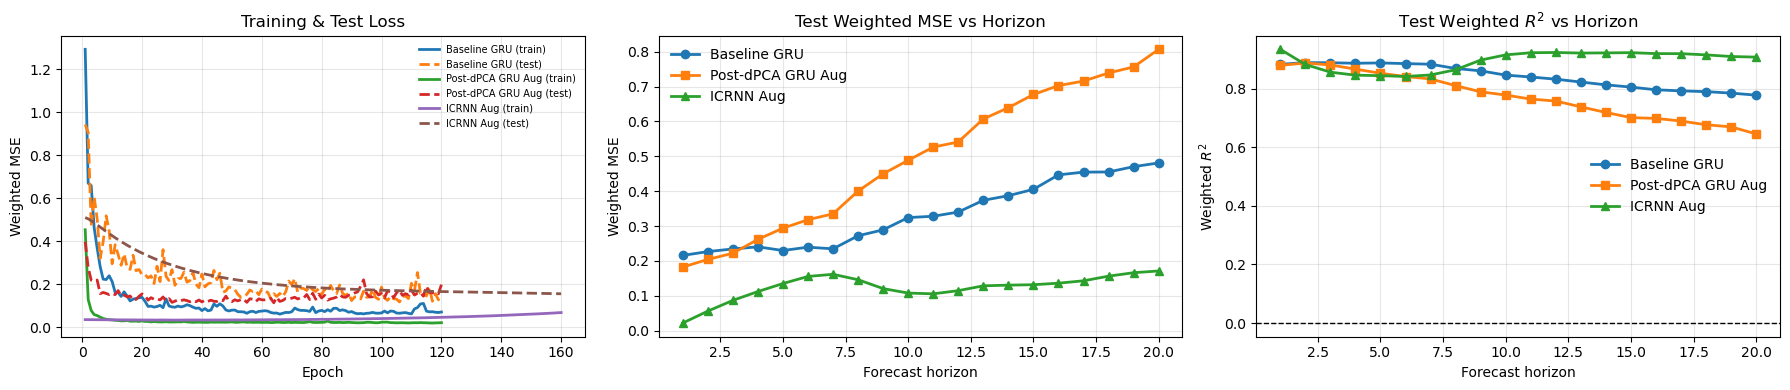

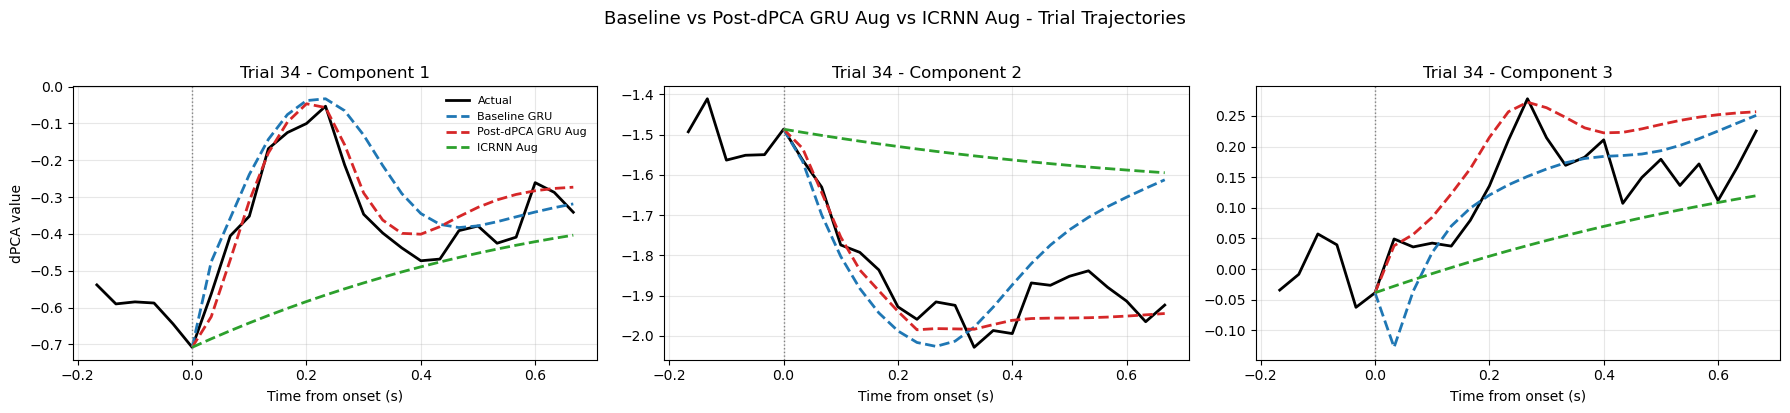

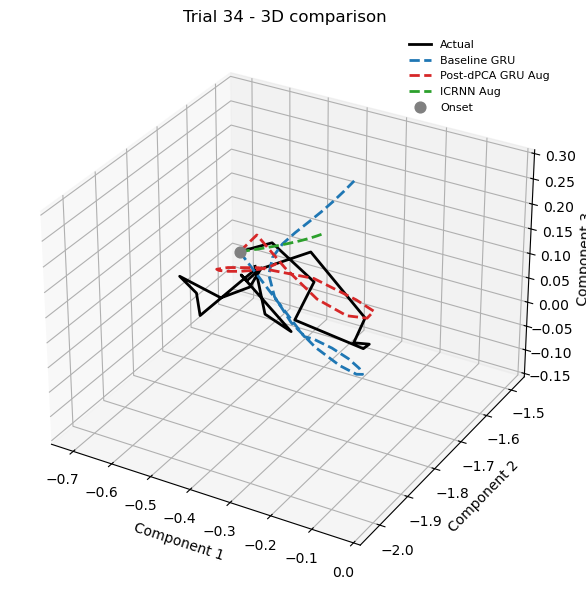

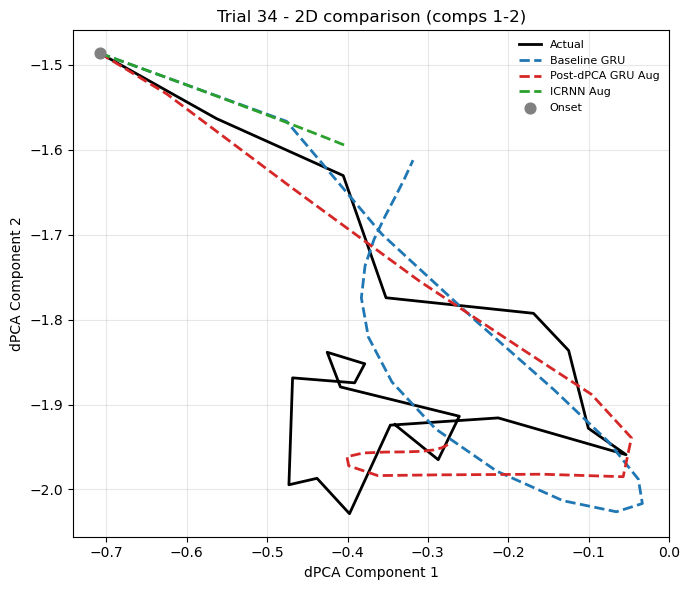

Training time (ICRNN): 485.84 s (3.0365 s/epoch)
Inference time (ICRNN): 0.020388 s

Weighted metrics comparison (first 5 horizons):
   h    Base MSE  GRU Aug MSE   ICRNN MSE     Base R²   GRU Aug R²    ICRNN R²
t+01     0.21559      0.18219     0.02164     0.88375      0.87998     0.93492
t+02     0.22658      0.20407     0.05575     0.88953      0.88826     0.88320
t+03     0.23415      0.22180     0.08661     0.88911      0.88144     0.85693
t+04     0.24026      0.26161     0.11195     0.88735      0.86727     0.84660
t+05     0.22971      0.29382     0.13498     0.88843      0.85320     0.84495


In [22]:
# =============================================================================
# ICRNN (input-convex recurrent model) with post-dPCA augmentation (same as cell 10)
# =============================================================================

import copy
import torch.nn.functional as F

# Reuse the exact post-dPCA + EMA augmentation strategy from cell 10.
required_vars = [
    'aug_train_loader', 'aug_train_ds', 'test_loader_aug', 'test_ds_aug',
    'weighted_mse_loss', 'component_weights_t', 'component_weights',
    'horizon', 'horizons', 'd_z', 'n_cells', 'device'
]
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise RuntimeError(
        "Run cell 10 first so post-dPCA augmentation variables exist. Missing: " + ", ".join(missing)
    )


class ICRNNCell(torch.nn.Module):
    """Stabilized convex recurrent update.

    We use a signed affine backbone plus a bounded convex residual:
      z_next = a * z_prev + (1-a) * [A_z z_prev + A_v v_t + b + eta * softplus(Wz z_prev + Wv v_t + c)]

    Convexity in state/input comes from nonnegative Wz/Wv and convex softplus.
    Affine terms preserve convexity while allowing signed outputs.
    """

    def __init__(self, latent_dim, stim_dim, rho=0.7):
        super().__init__()
        self.latent_dim = latent_dim
        self.stim_dim = stim_dim
        self.rho = float(rho)

        # Convex term parameters (constrained nonnegative).
        self.raw_Wz = torch.nn.Parameter(0.01 * torch.randn(latent_dim, latent_dim))
        self.raw_Wv = torch.nn.Parameter(0.01 * torch.randn(latent_dim, stim_dim))
        self.bias_conv = torch.nn.Parameter(torch.zeros(latent_dim))

        # Signed affine backbone.
        self.raw_Az = torch.nn.Parameter(0.01 * torch.randn(latent_dim, latent_dim))
        self.raw_Av = torch.nn.Parameter(0.01 * torch.randn(latent_dim, stim_dim))
        self.bias_aff = torch.nn.Parameter(torch.zeros(latent_dim))

        # Step size and convex residual strength.
        self.alpha_raw = torch.nn.Parameter(torch.full((latent_dim,), 1.2))
        self.eta_raw = torch.nn.Parameter(torch.full((latent_dim,), -2.0))

    def _constrained_Wz(self):
        Wz_pos = F.softplus(self.raw_Wz)
        row_sum = Wz_pos.sum(dim=1, keepdim=True).clamp_min(1e-6)
        return (Wz_pos / row_sum) * self.rho

    def _constrained_Wv(self):
        return F.softplus(self.raw_Wv)

    def _stable_Az(self):
        I = torch.eye(self.latent_dim, device=self.raw_Az.device, dtype=self.raw_Az.dtype)
        Az = I + 0.05 * torch.tanh(self.raw_Az)
        op_norm = torch.linalg.matrix_norm(Az, ord=2)
        max_norm = 0.98
        if op_norm > max_norm:
            Az = Az * (max_norm / op_norm)
        return Az

    def _stable_Av(self):
        return 0.05 * self.raw_Av

    def forward(self, z_prev, v_t):
        Wz = self._constrained_Wz()
        Wv = self._constrained_Wv()
        Az = self._stable_Az()
        Av = self._stable_Av()

        # Keep updates small for stiff dynamics.
        alpha = 0.92 + 0.07 * torch.sigmoid(self.alpha_raw)
        eta = 0.20 * torch.sigmoid(self.eta_raw)

        pre_conv = z_prev @ Wz.T + v_t @ Wv.T + self.bias_conv
        convex_term = F.softplus(pre_conv)

        affine_term = z_prev @ Az.T + v_t @ Av.T + self.bias_aff
        z_candidate = affine_term + eta[None, :] * convex_term

        z_next = alpha[None, :] * z_prev + (1.0 - alpha[None, :]) * z_candidate
        return z_next


class ICRNNStimForecast(torch.nn.Module):
    def __init__(self, latent_dim, stim_dim, rho=0.7):
        super().__init__()
        self.cell = ICRNNCell(latent_dim=latent_dim, stim_dim=stim_dim, rho=rho)

    def forward(self, context_z, context_v, future_v, target_z=None, teacher_forcing=0.0):
        z_prev = context_z[:, -1, :]
        H = future_v.shape[1]
        preds = []

        for h in range(H):
            if h > 0 and target_z is not None and teacher_forcing > 0.0:
                z_prev = teacher_forcing * target_z[:, h - 1, :] + (1.0 - teacher_forcing) * z_prev
            z_prev = self.cell(z_prev, future_v[:, h, :])
            preds.append(z_prev)

        return torch.stack(preds, dim=1)


class ParameterEMA:
    """EMA shadow model for stabler evaluation in stiff dynamics."""

    def __init__(self, model, decay=0.99):
        self.decay = float(decay)
        self.shadow = copy.deepcopy(model).eval()
        for p in self.shadow.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        msd = model.state_dict()
        ssd = self.shadow.state_dict()
        for k in ssd.keys():
            ssd[k].mul_(self.decay).add_(msd[k], alpha=1.0 - self.decay)


def temporal_smoothness_loss(pred, target):
    if pred.shape[1] < 2:
        return pred.new_tensor(0.0)
    dp = pred[:, 1:, :] - pred[:, :-1, :]
    dt = target[:, 1:, :] - target[:, :-1, :]
    return F.mse_loss(dp, dt)


def state_bound_loss(pred, bound=4.0):
    # Keep normalized latent predictions near the training manifold.
    overflow = F.relu(torch.abs(pred) - bound)
    return (overflow ** 2).mean()


# -----------------------------
# Train ICRNN on the same augmented dataset from cell 10
# -----------------------------
model_icrnn = ICRNNStimForecast(latent_dim=d_z, stim_dim=n_cells, rho=0.7).to(device)
optimizer_icrnn = torch.optim.AdamW(model_icrnn.parameters(), lr=1e-4, weight_decay=3e-4)
ema_icrnn = ParameterEMA(model_icrnn, decay=0.99)

n_epochs_icrnn = 160
loss_history_icrnn = []
test_loss_history_icrnn = []

lambda_smooth = 0.05
lambda_bound = 0.01

train_t0_icrnn = time.perf_counter()
for epoch in range(1, n_epochs_icrnn + 1):
    model_icrnn.train()
    running_loss = 0.0

    # Heavier teacher forcing for longer to stabilize constrained recurrence.
    tf_ratio = 0.98 + (0.25 - 0.98) * ((epoch - 1) / max(n_epochs_icrnn - 1, 1))

    for context_z_b, context_v_b, future_v_b, target_z_b in aug_train_loader:
        context_z_b = context_z_b.to(device)
        context_v_b = context_v_b.to(device)
        future_v_b = future_v_b.to(device)
        target_z_b = target_z_b.to(device)

        optimizer_icrnn.zero_grad(set_to_none=True)
        pred_z_b = model_icrnn(
            context_z_b, context_v_b, future_v_b,
            target_z=target_z_b, teacher_forcing=tf_ratio
        )

        loss_recon = weighted_mse_loss(pred_z_b, target_z_b, component_weights_t)
        loss_smooth = temporal_smoothness_loss(pred_z_b, target_z_b)
        loss_bound = state_bound_loss(pred_z_b, bound=4.0)
        loss = loss_recon + lambda_smooth * loss_smooth + lambda_bound * loss_bound

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_icrnn.parameters(), 0.3)
        optimizer_icrnn.step()
        ema_icrnn.update(model_icrnn)

        running_loss += loss.item() * context_z_b.shape[0]

    epoch_loss = running_loss / len(aug_train_ds)
    loss_history_icrnn.append(epoch_loss)

    # Evaluate EMA model (open loop)
    ema_icrnn.shadow.eval()
    with torch.no_grad():
        test_running = 0.0
        for context_z_b, context_v_b, future_v_b, target_z_b in test_loader_aug:
            context_z_b = context_z_b.to(device)
            context_v_b = context_v_b.to(device)
            future_v_b = future_v_b.to(device)
            target_z_b = target_z_b.to(device)
            pred_z_b = ema_icrnn.shadow(context_z_b, context_v_b, future_v_b, target_z=None, teacher_forcing=0.0)
            test_running += weighted_mse_loss(pred_z_b, target_z_b, component_weights_t).item() * context_z_b.shape[0]
        test_loss_history_icrnn.append(test_running / len(test_ds_aug))

    if epoch % 20 == 0 or epoch == 1:
        print(
            f"[ICRNN] Epoch {epoch:03d}/{n_epochs_icrnn} | "
            f"loss={epoch_loss:.6f} | test_loss={test_loss_history_icrnn[-1]:.6f} | tf={tf_ratio:.3f}"
        )

training_time_icrnn = time.perf_counter() - train_t0_icrnn


# -----------------------------
# Evaluate on clean test set (same protocol)
# -----------------------------
ema_icrnn.shadow.eval()
with torch.no_grad():
    (ctx_z_t, ctx_v_t, fut_v_t, tgt_z_t) = next(iter(test_loader_aug))
    ctx_z_t = ctx_z_t.to(device)
    ctx_v_t = ctx_v_t.to(device)
    fut_v_t = fut_v_t.to(device)

    if device.type == 'cuda':
        torch.cuda.synchronize()
    infer_t0_icrnn = time.perf_counter()
    pred_z_t_icrnn = ema_icrnn.shadow(ctx_z_t, ctx_v_t, fut_v_t, target_z=None, teacher_forcing=0.0)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    inference_time_icrnn = time.perf_counter() - infer_t0_icrnn

pred_z_t_icrnn = pred_z_t_icrnn.cpu().numpy()
tgt_z_t = tgt_z_t.numpy()

pred_z_icrnn = pred_z_t_icrnn * z_std + z_mean
target_z_icrnn = tgt_z_t * z_std + z_mean

weighted_mse_by_h_icrnn = []
weighted_r2_by_h_icrnn = []

for h in range(horizon):
    y_true_h = target_z_icrnn[:, h, :]
    y_pred_h = pred_z_icrnn[:, h, :]

    mse_per_comp = np.mean((y_pred_h - y_true_h) ** 2, axis=0)
    weighted_mse = float(np.sum(component_weights * mse_per_comp))

    r2_per_comp = np.zeros(d_z, dtype=np.float64)
    for comp in range(d_z):
        if np.var(y_true_h[:, comp]) < 1e-12:
            r2_per_comp[comp] = 0.0
        else:
            r2_per_comp[comp] = r2_score(y_true_h[:, comp], y_pred_h[:, comp])
    weighted_r2 = float(np.sum(component_weights * r2_per_comp))

    weighted_mse_by_h_icrnn.append(weighted_mse)
    weighted_r2_by_h_icrnn.append(weighted_r2)


# -----------------------------
# Same graphs: now baseline vs post-dPCA GRU aug vs ICRNN
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Training curves
axes[0].plot(np.arange(1, n_epochs + 1), loss_history, lw=2, label='Baseline GRU (train)')
axes[0].plot(np.arange(1, n_epochs + 1), test_loss_history, lw=2, ls='--', label='Baseline GRU (test)')
axes[0].plot(np.arange(1, n_epochs_aug + 1), loss_history_aug, lw=2, label='Post-dPCA GRU Aug (train)')
axes[0].plot(np.arange(1, n_epochs_aug + 1), test_loss_history_aug, lw=2, ls='--', label='Post-dPCA GRU Aug (test)')
axes[0].plot(np.arange(1, n_epochs_icrnn + 1), loss_history_icrnn, lw=2, label='ICRNN Aug (train)')
axes[0].plot(np.arange(1, n_epochs_icrnn + 1), test_loss_history_icrnn, lw=2, ls='--', label='ICRNN Aug (test)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Weighted MSE')
axes[0].set_title('Training & Test Loss')
axes[0].legend(frameon=False, fontsize=7)
axes[0].grid(alpha=0.3)

# Weighted MSE vs horizon
axes[1].plot(horizons, weighted_mse_by_h, marker='o', lw=2, label='Baseline GRU')
axes[1].plot(horizons, weighted_mse_by_h_aug, marker='s', lw=2, label='Post-dPCA GRU Aug')
axes[1].plot(horizons, weighted_mse_by_h_icrnn, marker='^', lw=2, label='ICRNN Aug')
axes[1].set_xlabel('Forecast horizon')
axes[1].set_ylabel('Weighted MSE')
axes[1].set_title('Test Weighted MSE vs Horizon')
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.3)

# Weighted R^2 vs horizon
axes[2].plot(horizons, weighted_r2_by_h, marker='o', lw=2, label='Baseline GRU')
axes[2].plot(horizons, weighted_r2_by_h_aug, marker='s', lw=2, label='Post-dPCA GRU Aug')
axes[2].plot(horizons, weighted_r2_by_h_icrnn, marker='^', lw=2, label='ICRNN Aug')
axes[2].axhline(0.0, color='k', ls='--', lw=1)
axes[2].set_xlabel('Forecast horizon')
axes[2].set_ylabel('Weighted $R^2$')
axes[2].set_title('Test Weighted $R^2$ vs Horizon')
axes[2].legend(frameon=False)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# -----------------------------
# Same trajectory graphs (Trial 34)
# -----------------------------
trial_id = 34
pre_steps = 5

context_z_single = torch.from_numpy(z_trial_n[trial_id, :context_len, :]).unsqueeze(0).to(device)
context_v_single = torch.from_numpy(v[trial_id, :context_len, :]).unsqueeze(0).to(device)
future_v_single = torch.from_numpy(v[trial_id, zero_idx + 1:zero_idx + 1 + horizon, :]).unsqueeze(0).to(device)

with torch.no_grad():
    pred_base_n = model(context_z_single, context_v_single, future_v_single, target_z=None, teacher_forcing=0.0)
    pred_aug_n = model_aug(context_z_single, context_v_single, future_v_single, target_z=None, teacher_forcing=0.0)
    pred_icrnn_n = ema_icrnn.shadow(context_z_single, context_v_single, future_v_single, target_z=None, teacher_forcing=0.0)

pred_base = pred_base_n.squeeze(0).cpu().numpy() * z_std.squeeze((0, 1)) + z_mean.squeeze((0, 1))
pred_aug_single = pred_aug_n.squeeze(0).cpu().numpy() * z_std.squeeze((0, 1)) + z_mean.squeeze((0, 1))
pred_icrnn_single = pred_icrnn_n.squeeze(0).cpu().numpy() * z_std.squeeze((0, 1)) + z_mean.squeeze((0, 1))

start_idx = zero_idx - pre_steps
end_idx = zero_idx + 1 + horizon
t_window = time_axis[start_idx:end_idx]
true_window = z_trial[trial_id, start_idx:end_idx, :]

pred_win_base = np.full((pre_steps + 1 + horizon, d_z), np.nan, dtype=np.float32)
pred_win_base[pre_steps, :] = true_window[pre_steps, :]
pred_win_base[pre_steps + 1:, :] = pred_base

pred_win_aug = np.full((pre_steps + 1 + horizon, d_z), np.nan, dtype=np.float32)
pred_win_aug[pre_steps, :] = true_window[pre_steps, :]
pred_win_aug[pre_steps + 1:, :] = pred_aug_single

pred_win_icrnn = np.full((pre_steps + 1 + horizon, d_z), np.nan, dtype=np.float32)
pred_win_icrnn[pre_steps, :] = true_window[pre_steps, :]
pred_win_icrnn[pre_steps + 1:, :] = pred_icrnn_single

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
for comp in range(3):
    axes[comp].plot(t_window, true_window[:, comp], lw=2, label='Actual', color='black')
    axes[comp].plot(t_window, pred_win_base[:, comp], lw=2, ls='--', label='Baseline GRU', color='tab:blue')
    axes[comp].plot(t_window, pred_win_aug[:, comp], lw=2, ls='--', label='Post-dPCA GRU Aug', color='tab:red')
    axes[comp].plot(t_window, pred_win_icrnn[:, comp], lw=2, ls='--', label='ICRNN Aug', color='tab:green')
    axes[comp].axvline(0.0, color='gray', ls=':', lw=1)
    axes[comp].set_title(f'Trial {trial_id} - Component {comp + 1}')
    axes[comp].set_xlabel('Time from onset (s)')
    axes[comp].grid(alpha=0.3)

axes[0].set_ylabel('dPCA value')
axes[0].legend(frameon=False, fontsize=8)
plt.suptitle('Baseline vs Post-dPCA GRU Aug vs ICRNN Aug - Trial Trajectories', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# 3D comparison
onset_state = z_trial[trial_id, zero_idx, :]
true_post = z_trial[trial_id, zero_idx + 1:zero_idx + 1 + horizon, :]
true_from_onset = np.vstack([onset_state[None, :], true_post])
base_from_onset = np.vstack([onset_state[None, :], pred_base])
aug_from_onset = np.vstack([onset_state[None, :], pred_aug_single])
icrnn_from_onset = np.vstack([onset_state[None, :], pred_icrnn_single])

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(true_from_onset[:, 0], true_from_onset[:, 1], true_from_onset[:, 2], color='black', lw=2, label='Actual')
ax.plot(base_from_onset[:, 0], base_from_onset[:, 1], base_from_onset[:, 2], color='tab:blue', lw=2, ls='--', label='Baseline GRU')
ax.plot(aug_from_onset[:, 0], aug_from_onset[:, 1], aug_from_onset[:, 2], color='tab:red', lw=2, ls='--', label='Post-dPCA GRU Aug')
ax.plot(icrnn_from_onset[:, 0], icrnn_from_onset[:, 1], icrnn_from_onset[:, 2], color='tab:green', lw=2, ls='--', label='ICRNN Aug')
ax.scatter(onset_state[0], onset_state[1], onset_state[2], color='gray', s=60, zorder=5, label='Onset')
ax.set_title(f'Trial {trial_id} - 3D comparison')
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.set_zlabel('Component 3')
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# 2D trajectory (components 1 & 2)
fig, ax2d = plt.subplots(figsize=(7, 6))
ax2d.plot(true_from_onset[:, 0], true_from_onset[:, 1], color='black', lw=2, label='Actual')
ax2d.plot(base_from_onset[:, 0], base_from_onset[:, 1], color='tab:blue', lw=2, ls='--', label='Baseline GRU')
ax2d.plot(aug_from_onset[:, 0], aug_from_onset[:, 1], color='tab:red', lw=2, ls='--', label='Post-dPCA GRU Aug')
ax2d.plot(icrnn_from_onset[:, 0], icrnn_from_onset[:, 1], color='tab:green', lw=2, ls='--', label='ICRNN Aug')
ax2d.scatter(onset_state[0], onset_state[1], color='gray', s=60, zorder=5, label='Onset')
ax2d.set_title(f'Trial {trial_id} - 2D comparison (comps 1-2)')
ax2d.set_xlabel('dPCA Component 1')
ax2d.set_ylabel('dPCA Component 2')
ax2d.legend(frameon=False, fontsize=8)
ax2d.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Training time (ICRNN): {training_time_icrnn:.2f} s ({training_time_icrnn / n_epochs_icrnn:.4f} s/epoch)")
print(f"Inference time (ICRNN): {inference_time_icrnn:.6f} s")
print("\nWeighted metrics comparison (first 5 horizons):")
print(f"{'h':>4s}  {'Base MSE':>10s} {'GRU Aug MSE':>12s} {'ICRNN MSE':>11s}  {'Base R²':>10s} {'GRU Aug R²':>12s} {'ICRNN R²':>11s}")
for h in range(min(5, horizon)):
    print(
        f"t+{h+1:02d}  "
        f"{weighted_mse_by_h[h]:10.5f} {weighted_mse_by_h_aug[h]:12.5f} {weighted_mse_by_h_icrnn[h]:11.5f}  "
        f"{weighted_r2_by_h[h]:10.5f} {weighted_r2_by_h_aug[h]:12.5f} {weighted_r2_by_h_icrnn[h]:11.5f}"
    )

## GRU with Pre-dPCA / Pre-EMA Noise Augmentation

### Motivation: Spectral Consistency

The previous augmentation (cell 10) injects **white Gaussian noise** directly into the latent trajectories *after* dPCA projection and EMA smoothing. Because EMA is a low-pass filter, the resulting latent signals have high temporal autocorrelation. Adding i.i.d. Gaussian noise to those signals introduces a **spectral mismatch**: the augmented samples contain high-frequency artefacts that would never appear in real smoothed data, potentially confusing the model.

To fix this, we inject noise **upstream** — into the raw neural firing-rate matrix `neural_data` (shape $N \times n_{\text{trials}} \times T$) — *before* dPCA projection and EMA smoothing. The noise then passes through:

$$
\text{raw } + \epsilon \;\xrightarrow{\text{center}}\; \xrightarrow{\text{dPCA}}\; \xrightarrow{\text{EMA}}\; \tilde{\mathbf{z}}_t
$$

so the augmented latent trajectories inherit the same spectral profile (temporal smoothness, correlation structure) as the real data.

### Augmentation Procedure

For each **stimulated** training trial and each noisy copy $k \in \{1, \dots, K\}$:

1. Copy the full raw neural matrix for that trial: $\mathbf{X}^{(i)} \in \mathbb{R}^{N \times T}$.
2. Add per-neuron Gaussian noise **only in the peri-onset window** ($W = 10$ steps, 5 pre + 5 post):
   $$
   \tilde{X}_{n,t}^{(i,k)} = X_{n,t}^{(i)} + \epsilon_{n,t}, \quad \epsilon_{n,t} \sim \mathcal{N}(0, (\sigma_{\text{frac}} \cdot \hat{\sigma}_n)^2), \quad t \in \mathcal{W}
   $$
   where $\hat{\sigma}_n$ is the across-trial standard deviation of neuron $n$ in the training set.
3. Center the noisy trial using the **same** training mean.
4. Project through the **already-fitted** dPCA encoder.
5. Apply the **same** EMA smoothing.
6. Z-score with the **same** training-set mean and std.

This produces spectrally consistent augmented latent trajectories. Control (non-stimulated) trials are included as-is.

### Key Differences from Cell 10

| | Cell 10 (post-dPCA) | This cell (pre-dPCA) |
|---|---|---|
| Noise domain | Normalized latent space | Raw neural firing rates |
| Spectral match | No (white noise on smooth signal) | Yes (noise smoothed by dPCA + EMA) |
| Computational cost | Low (noise on small $d_z$-dim vector) | Higher (re-project each copy through dPCA + EMA) |
| Augmented copies ($K$) | 15 | 15 |
| Noise scale | 15% of latent std | 15% of per-neuron std |
| Peri-onset window | 10 steps | 10 steps |

### Note

The **baseline** model (`model`, cell 8) and the **test set** are never changed — comparison is always against the same clean baseline and clean test data.

Raw augmentation window: [233, 243)  (10 steps, centered on onset at 238)
Noise std per neuron (first 5): [0.11129372 0.15957859 0.12298511 0.06222998 0.09444403]
Stimulated training trials: 82 / 129
Augmented copies per stim trial: 15

Expanded training set: 1359 trials (original 129 + 1230 noisy copies)
Augmented latent shape after dPCA + EMA + norm: (1359, 420, 30)
Pre-dPCA augmented train loader: 1359 samples, 43 batches
[Pre-dPCA Aug] Epoch 001/120 | loss=0.465505 | test_loss=0.308517 | tf=0.700
[Pre-dPCA Aug] Epoch 020/120 | loss=0.021294 | test_loss=0.152600 | tf=0.604
[Pre-dPCA Aug] Epoch 040/120 | loss=0.018218 | test_loss=0.111005 | tf=0.503
[Pre-dPCA Aug] Epoch 060/120 | loss=0.018489 | test_loss=0.107379 | tf=0.403
[Pre-dPCA Aug] Epoch 080/120 | loss=0.019127 | test_loss=0.131272 | tf=0.302
[Pre-dPCA Aug] Epoch 100/120 | loss=0.019116 | test_loss=0.126811 | tf=0.201
[Pre-dPCA Aug] Epoch 120/120 | loss=0.015360 | test_loss=0.141171 | tf=0.100


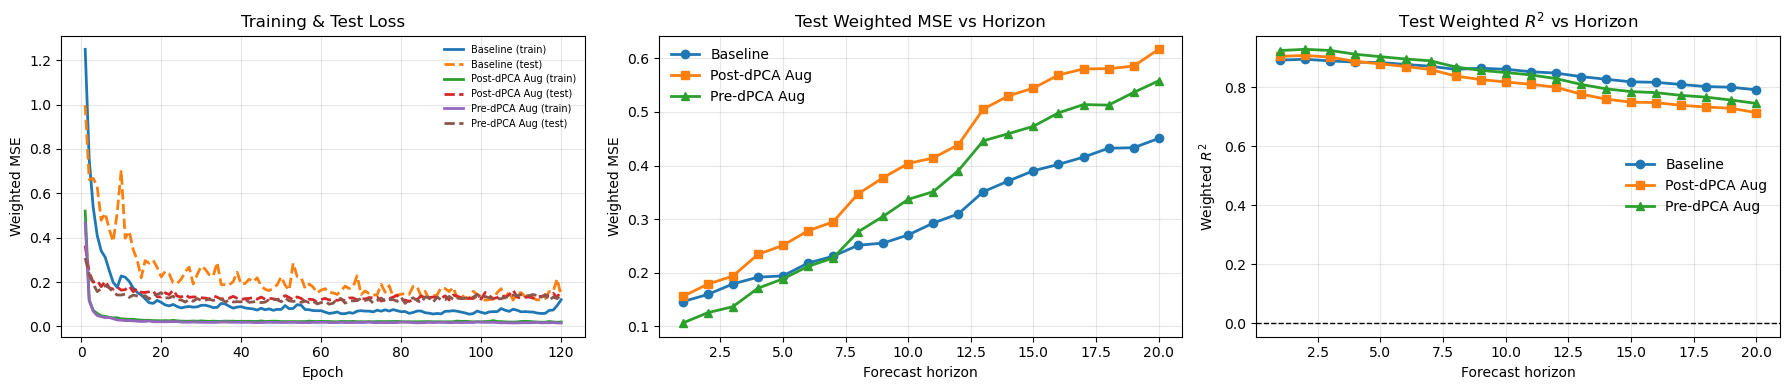

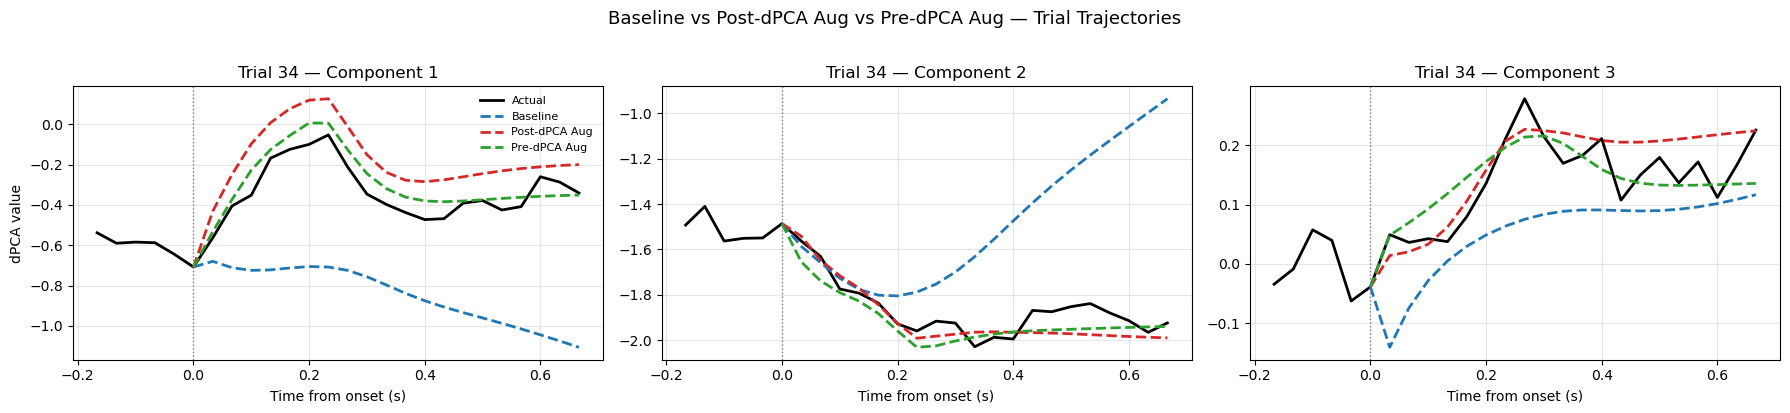

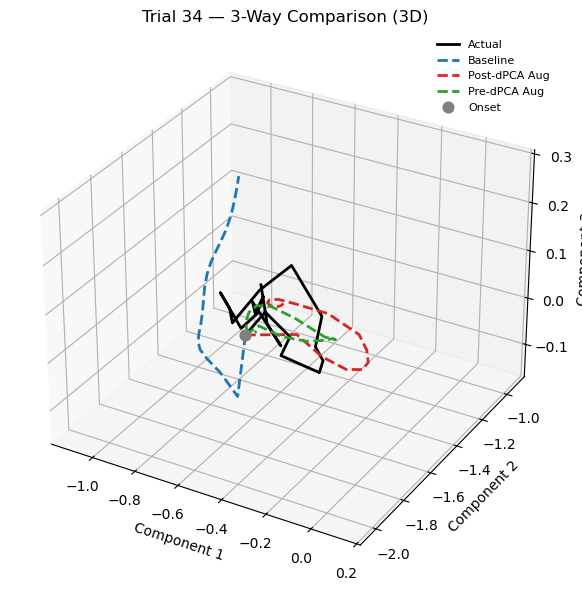

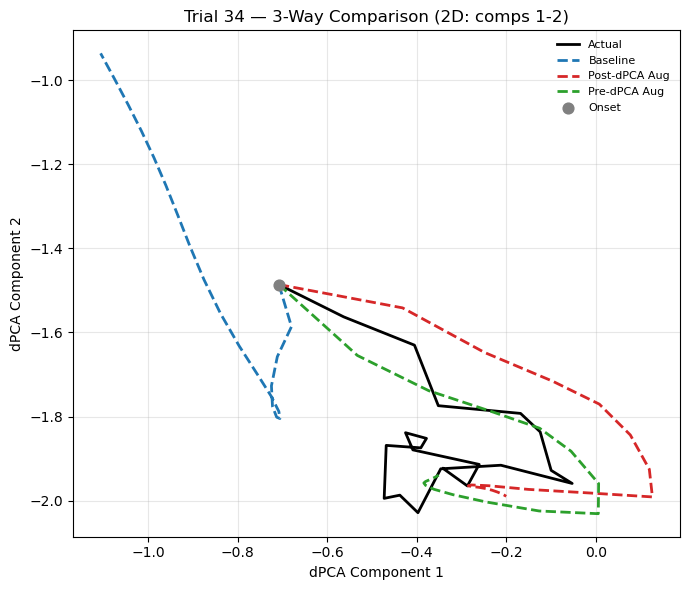


Training time (pre-dPCA aug): 111.45 s (0.9287 s/epoch)
Inference time (pre-dPCA aug): 0.006712 s

3-Way Weighted Metrics Comparison (first 5 horizons):
   h    Base MSE   Post MSE    Pre MSE     Base R²    Post R²     Pre R²
t+01     0.14615    0.15572    0.10619     0.89193    0.90469    0.92432
t+02     0.15948    0.17877    0.12549     0.89464    0.90747    0.92836
t+03     0.17908    0.19371    0.13665     0.88911    0.90176    0.92441
t+04     0.19173    0.23419    0.17108     0.88497    0.88725    0.91160
t+05     0.19418    0.25107    0.18862     0.88341    0.87906    0.90333


In [9]:
# =============================================================================
# GRU with Pre-dPCA / Pre-EMA Noise Augmentation
# =============================================================================

# --- Augmentation parameters (same as cell 10 for fair comparison) ---
n_augment_raw = 15        # noisy copies per stimulated trial
noise_frac_raw = 0.15     # noise std as fraction of per-neuron training std
aug_half_win_raw = 5      # half-window: 5 pre + 5 post = 10 timesteps around onset

# Per-neuron std across training trials  (neural_data shape: N, n_trials, T)
raw_train = neural_data[:, train_indices, :]           # (N, n_train, T)
raw_neuron_std = raw_train.std(axis=(1, 2))            # (N,)
raw_noise_std = (noise_frac_raw * raw_neuron_std).astype(np.float32)  # (N,)

# Peri-onset window in the time axis
raw_aug_start = max(zero_idx - aug_half_win_raw, 0)
raw_aug_end   = min(zero_idx + aug_half_win_raw, neural_data.shape[2])

print(f"Raw augmentation window: [{raw_aug_start}, {raw_aug_end})  "
      f"({raw_aug_end - raw_aug_start} steps, centered on onset at {zero_idx})")
print(f"Noise std per neuron (first 5): {raw_noise_std[:5]}")
print(f"Stimulated training trials: {n_stim_train} / {len(train_indices)}")
print(f"Augmented copies per stim trial: {n_augment_raw}")

# ---------------------------------------------------------------
# 1) Build augmented raw dataset: original + noisy copies
# ---------------------------------------------------------------

# We will build an expanded neural_data array and a matching expanded v array
# for training trials only.  Test trials are never augmented.

# Collect augmented training trial indices and expanded arrays
aug_raw_list = []    # list of (N, T) arrays — each is one training trial (original or noisy)
aug_v_list   = []    # matching stim vectors (n_cells, T)  → same for all copies of a trial
aug_trial_tags = []  # which original trial each comes from (for bookkeeping)

for i, tr in enumerate(train_indices):
    raw_trial = neural_data[:, tr, :].copy()  # (N, T)
    v_trial   = v[tr]                          # (T, n_cells)

    # Always include the clean original
    aug_raw_list.append(raw_trial)
    aug_v_list.append(v_trial)
    aug_trial_tags.append(tr)

    # If stimulated, generate K noisy copies
    if train_stim_mask[i]:
        for _ in range(n_augment_raw):
            noisy = raw_trial.copy()
            noise = np.random.randn(N, raw_aug_end - raw_aug_start).astype(np.float32) * raw_noise_std[:, None]
            noisy[:, raw_aug_start:raw_aug_end] += noise
            aug_raw_list.append(noisy)
            aug_v_list.append(v_trial)
            aug_trial_tags.append(tr)

aug_raw = np.stack(aug_raw_list, axis=1)  # (N, n_aug_train, T)
aug_v   = np.stack(aug_v_list, axis=0)    # (n_aug_train, T, n_cells)
n_aug_train = aug_raw.shape[1]

print(f"\nExpanded training set: {n_aug_train} trials "
      f"(original {len(train_indices)} + {n_aug_train - len(train_indices)} noisy copies)")

# ---------------------------------------------------------------
# 2) Run dPCA → EMA on the augmented raw data
# ---------------------------------------------------------------

# Center using the **same** training mean used for dPCA fitting
aug_centered = aug_raw - stim_mean   # stim_mean shape: (N, 1, 1)

# Project through the already-fitted dPCA
z_aug_all = dpca.transform(aug_centered)  # dict: each value (n_comp, n_aug_train, T)

# Concatenate marginals → (d_z, n_aug_train, T) → (n_aug_train, T, d_z)
z_aug_trial = np.concatenate([z_aug_all['s'], z_aug_all['t'], z_aug_all['st']], axis=0)
z_aug_trial = np.transpose(z_aug_trial, (1, 2, 0)).astype(np.float32)

# Apply EMA smoothing
z_aug_trial = apply_ema(z_aug_trial, alpha=EMA_ALPHA)

# Z-normalize using the **same** training stats (computed on clean data in cell 8)
z_aug_trial_n = (z_aug_trial - z_mean) / z_std

print(f"Augmented latent shape after dPCA + EMA + norm: {z_aug_trial_n.shape}")

# ---------------------------------------------------------------
# 3) Dataset for pre-dPCA–augmented training data
# ---------------------------------------------------------------

class PreDPCAAugDataset(Dataset):
    """Dataset backed by pre-computed augmented latent trajectories."""

    def __init__(self, z_data, v_data):
        """
        z_data: (n_trials, T, d_z) — pre-dPCA-augmented, EMA-smoothed, normalised latents
        v_data: (n_trials, T, n_cells) — stimulus vectors
        """
        self.z = z_data
        self.v = v_data

    def __len__(self):
        return self.z.shape[0]

    def __getitem__(self, idx):
        context_z = self.z[idx, :context_len, :]
        context_v = self.v[idx, :context_len, :]
        future_v  = self.v[idx, zero_idx + 1:zero_idx + 1 + horizon, :]
        target_z  = self.z[idx, zero_idx + 1:zero_idx + 1 + horizon, :]
        return (
            torch.from_numpy(context_z),
            torch.from_numpy(context_v),
            torch.from_numpy(future_v),
            torch.from_numpy(target_z),
        )

predpca_train_ds = PreDPCAAugDataset(z_aug_trial_n, aug_v)
predpca_train_loader = DataLoader(predpca_train_ds, batch_size=32, shuffle=True)

# Test set stays clean (same as baseline)
predpca_test_ds = OnsetForecastDataset(test_indices)
predpca_test_loader = DataLoader(predpca_test_ds, batch_size=len(predpca_test_ds), shuffle=False)

print(f"Pre-dPCA augmented train loader: {len(predpca_train_ds)} samples, "
      f"{len(predpca_train_loader)} batches")

# ---------------------------------------------------------------
# 4) Train GRU on pre-dPCA–augmented data
# ---------------------------------------------------------------

model_predpca = GRUStimForecast(
    latent_dim=d_z, stim_dim=n_cells,
    hidden_dim=256, num_layers=2, dropout=0.1
).to(device)
optimizer_predpca = torch.optim.Adam(model_predpca.parameters(), lr=1e-3, weight_decay=1e-5)

n_epochs_predpca = 120
loss_history_predpca = []
test_loss_history_predpca = []

train_t0_predpca = time.perf_counter()
for epoch in range(1, n_epochs_predpca + 1):
    model_predpca.train()
    running_loss = 0.0
    tf_ratio = 0.7 + (0.1 - 0.7) * ((epoch - 1) / max(n_epochs_predpca - 1, 1))

    for context_z_b, context_v_b, future_v_b, target_z_b in predpca_train_loader:
        context_z_b = context_z_b.to(device)
        context_v_b = context_v_b.to(device)
        future_v_b  = future_v_b.to(device)
        target_z_b  = target_z_b.to(device)

        optimizer_predpca.zero_grad()
        pred_z_b = model_predpca(
            context_z_b, context_v_b, future_v_b,
            target_z=target_z_b, teacher_forcing=tf_ratio
        )
        loss = weighted_mse_loss(pred_z_b, target_z_b, component_weights_t)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_predpca.parameters(), 1.0)
        optimizer_predpca.step()
        running_loss += loss.item() * context_z_b.shape[0]

    epoch_loss = running_loss / len(predpca_train_ds)
    loss_history_predpca.append(epoch_loss)

    # Compute test loss (open-loop, no teacher forcing)
    model_predpca.eval()
    with torch.no_grad():
        test_running = 0.0
        for context_z_b, context_v_b, future_v_b, target_z_b in predpca_test_loader:
            context_z_b = context_z_b.to(device)
            context_v_b = context_v_b.to(device)
            future_v_b = future_v_b.to(device)
            target_z_b = target_z_b.to(device)
            pred_z_b = model_predpca(context_z_b, context_v_b, future_v_b, target_z=None, teacher_forcing=0.0)
            test_running += weighted_mse_loss(pred_z_b, target_z_b, component_weights_t).item() * context_z_b.shape[0]
        test_loss_history_predpca.append(test_running / len(predpca_test_ds))

    if epoch % 20 == 0 or epoch == 1:
        print(f"[Pre-dPCA Aug] Epoch {epoch:03d}/{n_epochs_predpca} | "
              f"loss={epoch_loss:.6f} | test_loss={test_loss_history_predpca[-1]:.6f} | tf={tf_ratio:.3f}")

training_time_predpca = time.perf_counter() - train_t0_predpca

# ---------------------------------------------------------------
# 5) Evaluate on clean test set
# ---------------------------------------------------------------

model_predpca.eval()
with torch.no_grad():
    (ctx_z_t, ctx_v_t, fut_v_t, tgt_z_t) = next(iter(predpca_test_loader))
    ctx_z_t = ctx_z_t.to(device)
    ctx_v_t = ctx_v_t.to(device)
    fut_v_t = fut_v_t.to(device)

    if device.type == 'cuda':
        torch.cuda.synchronize()
    infer_t0_predpca = time.perf_counter()
    pred_z_t_predpca = model_predpca(ctx_z_t, ctx_v_t, fut_v_t, target_z=None, teacher_forcing=0.0)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    inference_time_predpca = time.perf_counter() - infer_t0_predpca

pred_z_t_predpca = pred_z_t_predpca.cpu().numpy()
tgt_z_t = tgt_z_t.numpy()

pred_z_predpca = pred_z_t_predpca * z_std + z_mean
target_z_predpca = tgt_z_t * z_std + z_mean

weighted_mse_by_h_predpca = []
weighted_r2_by_h_predpca  = []

for h in range(horizon):
    y_true_h = target_z_predpca[:, h, :]
    y_pred_h = pred_z_predpca[:, h, :]

    mse_per_comp = np.mean((y_pred_h - y_true_h) ** 2, axis=0)
    weighted_mse = float(np.sum(component_weights * mse_per_comp))

    r2_per_comp = np.zeros(d_z, dtype=np.float64)
    for comp in range(d_z):
        if np.var(y_true_h[:, comp]) < 1e-12:
            r2_per_comp[comp] = 0.0
        else:
            r2_per_comp[comp] = r2_score(y_true_h[:, comp], y_pred_h[:, comp])
    weighted_r2 = float(np.sum(component_weights * r2_per_comp))

    weighted_mse_by_h_predpca.append(weighted_mse)
    weighted_r2_by_h_predpca.append(weighted_r2)

# ---------------------------------------------------------------
# 6) Three-way comparison plots: baseline vs post-dPCA aug vs pre-dPCA aug
# ---------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Training curves (with test losses)
axes[0].plot(np.arange(1, n_epochs + 1), loss_history, lw=2, label='Baseline (train)')
axes[0].plot(np.arange(1, n_epochs + 1), test_loss_history, lw=2, ls='--', label='Baseline (test)')
axes[0].plot(np.arange(1, n_epochs_aug + 1), loss_history_aug, lw=2, label='Post-dPCA Aug (train)')
axes[0].plot(np.arange(1, n_epochs_aug + 1), test_loss_history_aug, lw=2, ls='--', label='Post-dPCA Aug (test)')
axes[0].plot(np.arange(1, n_epochs_predpca + 1), loss_history_predpca, lw=2, label='Pre-dPCA Aug (train)')
axes[0].plot(np.arange(1, n_epochs_predpca + 1), test_loss_history_predpca, lw=2, ls='--', label='Pre-dPCA Aug (test)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Weighted MSE')
axes[0].set_title('Training & Test Loss')
axes[0].legend(frameon=False, fontsize=7)
axes[0].grid(alpha=0.3)

# Weighted MSE vs horizon
axes[1].plot(horizons, weighted_mse_by_h, marker='o', lw=2, label='Baseline')
axes[1].plot(horizons, weighted_mse_by_h_aug, marker='s', lw=2, label='Post-dPCA Aug')
axes[1].plot(horizons, weighted_mse_by_h_predpca, marker='^', lw=2, label='Pre-dPCA Aug')
axes[1].set_xlabel('Forecast horizon')
axes[1].set_ylabel('Weighted MSE')
axes[1].set_title('Test Weighted MSE vs Horizon')
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.3)

# Weighted R² vs horizon
axes[2].plot(horizons, weighted_r2_by_h, marker='o', lw=2, label='Baseline')
axes[2].plot(horizons, weighted_r2_by_h_aug, marker='s', lw=2, label='Post-dPCA Aug')
axes[2].plot(horizons, weighted_r2_by_h_predpca, marker='^', lw=2, label='Pre-dPCA Aug')
axes[2].axhline(0.0, color='k', ls='--', lw=1)
axes[2].set_xlabel('Forecast horizon')
axes[2].set_ylabel('Weighted $R^2$')
axes[2].set_title('Test Weighted $R^2$ vs Horizon')
axes[2].legend(frameon=False)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 7) Trial 34 — three-way trajectory comparison
# ---------------------------------------------------------------

trial_id = 34
pre_steps = 5

context_z_single = torch.from_numpy(z_trial_n[trial_id, :context_len, :]).unsqueeze(0).to(device)
context_v_single = torch.from_numpy(v[trial_id, :context_len, :]).unsqueeze(0).to(device)
future_v_single  = torch.from_numpy(v[trial_id, zero_idx + 1:zero_idx + 1 + horizon, :]).unsqueeze(0).to(device)

with torch.no_grad():
    pred_base_n    = model(context_z_single, context_v_single, future_v_single, target_z=None, teacher_forcing=0.0)
    pred_postdpca_n = model_aug(context_z_single, context_v_single, future_v_single, target_z=None, teacher_forcing=0.0)
    pred_predpca_n  = model_predpca(context_z_single, context_v_single, future_v_single, target_z=None, teacher_forcing=0.0)

pred_base_raw     = pred_base_n.squeeze(0).cpu().numpy() * z_std.squeeze((0, 1)) + z_mean.squeeze((0, 1))
pred_postdpca_raw = pred_postdpca_n.squeeze(0).cpu().numpy() * z_std.squeeze((0, 1)) + z_mean.squeeze((0, 1))
pred_predpca_raw  = pred_predpca_n.squeeze(0).cpu().numpy() * z_std.squeeze((0, 1)) + z_mean.squeeze((0, 1))

start_idx = zero_idx - pre_steps
end_idx   = zero_idx + 1 + horizon
t_window  = time_axis[start_idx:end_idx]
true_window = z_trial[trial_id, start_idx:end_idx, :]

def _build_pred_window(pred, d_z, pre_steps, horizon):
    w = np.full((pre_steps + 1 + horizon, d_z), np.nan, dtype=np.float32)
    w[pre_steps, :] = true_window[pre_steps, :]   # onset point
    w[pre_steps + 1:, :] = pred
    return w

pw_base     = _build_pred_window(pred_base_raw, d_z, pre_steps, horizon)
pw_postdpca = _build_pred_window(pred_postdpca_raw, d_z, pre_steps, horizon)
pw_predpca  = _build_pred_window(pred_predpca_raw, d_z, pre_steps, horizon)

# 2D component plots
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
for comp in range(3):
    axes[comp].plot(t_window, true_window[:, comp], lw=2, label='Actual', color='black')
    axes[comp].plot(t_window, pw_base[:, comp], lw=2, ls='--', label='Baseline', color='tab:blue')
    axes[comp].plot(t_window, pw_postdpca[:, comp], lw=2, ls='--', label='Post-dPCA Aug', color='tab:red')
    axes[comp].plot(t_window, pw_predpca[:, comp], lw=2, ls='--', label='Pre-dPCA Aug', color='tab:green')
    axes[comp].axvline(0.0, color='gray', ls=':', lw=1)
    axes[comp].set_title(f'Trial {trial_id} — Component {comp + 1}')
    axes[comp].set_xlabel('Time from onset (s)')
    axes[comp].grid(alpha=0.3)

axes[0].set_ylabel('dPCA value')
axes[0].legend(frameon=False, fontsize=8)
plt.suptitle('Baseline vs Post-dPCA Aug vs Pre-dPCA Aug — Trial Trajectories', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# 3D comparison
onset_state = z_trial[trial_id, zero_idx, :]
true_post = z_trial[trial_id, zero_idx + 1:zero_idx + 1 + horizon, :]
true_from_onset     = np.vstack([onset_state[None, :], true_post])
base_from_onset     = np.vstack([onset_state[None, :], pred_base_raw])
postdpca_from_onset = np.vstack([onset_state[None, :], pred_postdpca_raw])
predpca_from_onset  = np.vstack([onset_state[None, :], pred_predpca_raw])

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(true_from_onset[:, 0], true_from_onset[:, 1], true_from_onset[:, 2],
        color='black', lw=2, label='Actual')
ax.plot(base_from_onset[:, 0], base_from_onset[:, 1], base_from_onset[:, 2],
        color='tab:blue', lw=2, ls='--', label='Baseline')
ax.plot(postdpca_from_onset[:, 0], postdpca_from_onset[:, 1], postdpca_from_onset[:, 2],
        color='tab:red', lw=2, ls='--', label='Post-dPCA Aug')
ax.plot(predpca_from_onset[:, 0], predpca_from_onset[:, 1], predpca_from_onset[:, 2],
        color='tab:green', lw=2, ls='--', label='Pre-dPCA Aug')
ax.scatter(onset_state[0], onset_state[1], onset_state[2], color='gray', s=60, zorder=5, label='Onset')
ax.set_title(f'Trial {trial_id} — 3-Way Comparison (3D)')
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.set_zlabel('Component 3')
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# 2D trajectory (components 1 & 2)
fig, ax2d = plt.subplots(figsize=(7, 6))
ax2d.plot(true_from_onset[:, 0], true_from_onset[:, 1], color='black', lw=2, label='Actual')
ax2d.plot(base_from_onset[:, 0], base_from_onset[:, 1], color='tab:blue', lw=2, ls='--', label='Baseline')
ax2d.plot(postdpca_from_onset[:, 0], postdpca_from_onset[:, 1], color='tab:red', lw=2, ls='--', label='Post-dPCA Aug')
ax2d.plot(predpca_from_onset[:, 0], predpca_from_onset[:, 1], color='tab:green', lw=2, ls='--', label='Pre-dPCA Aug')
ax2d.scatter(onset_state[0], onset_state[1], color='gray', s=60, zorder=5, label='Onset')
ax2d.set_title(f'Trial {trial_id} — 3-Way Comparison (2D: comps 1-2)')
ax2d.set_xlabel('dPCA Component 1')
ax2d.set_ylabel('dPCA Component 2')
ax2d.legend(frameon=False, fontsize=8)
ax2d.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 8) Summary table
# ---------------------------------------------------------------

print(f"\nTraining time (pre-dPCA aug): {training_time_predpca:.2f} s "
      f"({training_time_predpca / n_epochs_predpca:.4f} s/epoch)")
print(f"Inference time (pre-dPCA aug): {inference_time_predpca:.6f} s")

print("\n3-Way Weighted Metrics Comparison (first 5 horizons):")
print(f"{'h':>4s}  {'Base MSE':>10s} {'Post MSE':>10s} {'Pre MSE':>10s}  "
      f"{'Base R²':>10s} {'Post R²':>10s} {'Pre R²':>10s}")
for h in range(min(5, horizon)):
    print(f"t+{h+1:02d}  "
          f"{weighted_mse_by_h[h]:10.5f} {weighted_mse_by_h_aug[h]:10.5f} {weighted_mse_by_h_predpca[h]:10.5f}  "
          f"{weighted_r2_by_h[h]:10.5f} {weighted_r2_by_h_aug[h]:10.5f} {weighted_r2_by_h_predpca[h]:10.5f}")

## Vanilla RNN Forecasting — Baseline + Augmentation Comparison

### Motivation

The GRU (cells 8, 10, 12) uses **gating mechanisms** (update gate $\mathbf{u}_t$, reset gate $\mathbf{r}_t$) that let it selectively forget or retain information. Here we replace the GRU with a **vanilla (Elman) RNN** to test whether the simpler recurrence — with no gating — is sufficient for forecasting dPCA-latent dynamics, or whether the gating structure of the GRU is genuinely needed.

### Architecture

The model follows the same **encoder–decoder** structure as the GRU, but substitutes all gated units with simple tanh recurrences.

#### Encoder (multi-layer `nn.RNN`)

The encoder consumes the priming context $\{(\mathbf{z}_t, \mathbf{v}_t)\}_{t=0}^{t_0}$, where the input at each step is the concatenation $\mathbf{x}_t = [\mathbf{z}_t \,\|\, \mathbf{v}_t] \in \mathbb{R}^{d_z + n_{\text{cells}}}$.

For a single-layer vanilla RNN the hidden state update is:

$$
\mathbf{h}_t = \tanh\!\bigl(W_{ih}\,\mathbf{x}_t + b_{ih} + W_{hh}\,\mathbf{h}_{t-1} + b_{hh}\bigr)
$$

With $L = 2$ stacked layers the recurrence becomes:

$$
\mathbf{h}^{(\ell)}_t = \tanh\!\Bigl(W^{(\ell)}_{ih}\,\mathbf{h}^{(\ell-1)}_t + b^{(\ell)}_{ih} + W^{(\ell)}_{hh}\,\mathbf{h}^{(\ell)}_{t-1} + b^{(\ell)}_{hh}\Bigr), \quad \ell = 1, \dots, L
$$

where $\mathbf{h}^{(0)}_t \equiv \mathbf{x}_t$. The encoder outputs the final hidden state $\mathbf{h}^{(\ell)}_{t_0}$ for each layer, which seeds the decoder.

**Key difference from GRU:** There are **no gates**. In a GRU, the update rule involves:

$$
\begin{aligned}
\mathbf{u}_t &= \sigma(W_u\,[\mathbf{x}_t,\,\mathbf{h}_{t-1}]) & &\text{(update gate)}\\
\mathbf{r}_t &= \sigma(W_r\,[\mathbf{x}_t,\,\mathbf{h}_{t-1}]) & &\text{(reset gate)}\\
\tilde{\mathbf{h}}_t &= \tanh(W_h\,[\mathbf{x}_t,\,\mathbf{r}_t \odot \mathbf{h}_{t-1}]) & &\text{(candidate)}\\
\mathbf{h}_t &= (1 - \mathbf{u}_t) \odot \mathbf{h}_{t-1} + \mathbf{u}_t \odot \tilde{\mathbf{h}}_t & &\text{(interpolation)}
\end{aligned}
$$

The vanilla RNN collapses all of this into the single tanh equation above. This means:

- **Fewer parameters**: $\sim\!\frac{1}{3}$ of a GRU per layer (no gate weight matrices).
- **No selective forgetting**: every timestep fully overwrites the hidden state via $\tanh(\cdot)$.
- **Vanishing gradients**: without the linear shortcut from the update gate, gradients through long sequences decay exponentially.

#### Decoder (autoregressive `nn.RNNCell` stack)

At each forecast step $k = 0, \ldots, H-1$ the decoder receives the previous prediction (or teacher-forced ground truth) concatenated with the stimulus vector:

$$
\mathbf{d}_k = [\tilde{\mathbf{z}}_{k-1} \,\|\, \mathbf{v}_{t_0+1+k}]
$$

Each layer $\ell$ of the decoder updates its hidden state:

$$
\mathbf{h}^{(\ell)}_{\text{dec},k} = \tanh\!\Bigl(W^{(\ell)}_{\text{dec},ih}\,\mathbf{g}^{(\ell-1)}_k + b^{(\ell)}_{\text{dec},ih} + W^{(\ell)}_{\text{dec},hh}\,\mathbf{h}^{(\ell)}_{\text{dec},k-1} + b^{(\ell)}_{\text{dec},hh}\Bigr)
$$

where $\mathbf{g}^{(0)}_k = \mathbf{d}_k$ and $\mathbf{g}^{(\ell)}_k = \text{Dropout}(\mathbf{h}^{(\ell)}_{\text{dec},k})$ for $\ell \ge 1$. The prediction is a linear readout from the top-layer hidden state:

$$
\hat{\mathbf{z}}_{t_0+1+k} = W_o\,\mathbf{h}^{(L)}_{\text{dec},k} + \mathbf{b}_o
$$

#### Teacher Forcing

Same schedule as the GRU: at each decoder step, with probability $p_{\text{tf}}$ (linearly decayed $0.7 \to 0.1$ over epochs), the input is the ground-truth $\mathbf{z}_{t_0+1+k}$ instead of the model's own prediction.

$$
\tilde{\mathbf{z}}_k =
\begin{cases}
\mathbf{z}_{t_0+1+k} & \text{w.p. } p_{\text{tf}} \quad \text{(teacher)}\\
\hat{\mathbf{z}}_{t_0+1+k} & \text{w.p. } 1 - p_{\text{tf}} \quad \text{(autoregressive)}
\end{cases}
$$

### Loss Function

Same variance-weighted MSE as the GRU:

$$
\mathcal{L} = \sum_{j=1}^{d_z} w_j \cdot \frac{1}{BH}\sum_{b=1}^{B}\sum_{h=1}^{H}\left(\hat{z}_{b,h,j} - z_{b,h,j}\right)^2, \qquad w_j = \frac{\mathrm{Var}(z_j)}{\sum_m \mathrm{Var}(z_m)}
$$

### Parameter Count Comparison

For a single recurrent layer with input dimension $d_{\text{in}}$ and hidden dimension $d_h$:

| | Vanilla RNN | GRU |
|---|---|---|
| Weight matrices per layer | $W_{ih} \in \mathbb{R}^{d_h \times d_{\text{in}}}$, $W_{hh} \in \mathbb{R}^{d_h \times d_h}$ | $3\times$ the above (one per gate + candidate) |
| Params per layer | $d_h(d_{\text{in}} + d_h) + 2d_h$ | $3\bigl[d_h(d_{\text{in}} + d_h) + 2d_h\bigr]$ |
| Ratio | $1\times$ | $3\times$ |

With $d_h = 256$, $d_z = 30$, $n_{\text{cells}} = 52$: the vanilla RNN has roughly **one-third** the recurrent parameters of the GRU.

### Experimental Design

Three models are trained with **identical hyperparameters**:

| Model | Training data | Augmentation domain |
|---|---|---|
| **Baseline** | Clean originals only | — |
| **Post-dPCA Aug** | Clean + $K=15$ noisy copies | Noise in normalized latent space (after dPCA + EMA) |
| **Pre-dPCA Aug** | Clean + $K=15$ noisy copies | Noise in raw neural data (before dPCA + EMA) |

All three are evaluated on the **same clean test set** (20% hold-out, `random_state=42`).

### Hyperparameters

| Parameter | Value |
|---|---|
| Hidden dimension | $256$ |
| Layers | $2$ |
| Nonlinearity | $\tanh$ |
| Dropout | $0.1$ |
| Batch size | $32$ |
| Epochs | $120$ |
| Optimizer | Adam ($\text{lr}=10^{-3}$, weight decay $10^{-5}$) |
| Gradient clipping | $1.0$ |
| Teacher forcing | $0.7 \to 0.1$ (linear decay) |
| Forecast horizon $H$ | $20$ |

### Expected Behaviour

Because the vanilla RNN lacks gating, we expect:
1. **Potentially worse long-horizon accuracy** — the hidden state has no mechanism to preserve information over many auto-regressive steps.
2. **More benefit from data augmentation** — the simpler model may be more prone to overfitting, making augmented training data more impactful.
3. **Faster training per epoch** — fewer parameters means less computation per forward/backward pass.

Vanilla RNN: z_trial=(162, 420, 30), context=239, horizon=20
Baseline train: 129 | Post-dPCA aug train: 1359 | Pre-dPCA aug train: 1359
VANILLA RNN — BASELINE
[RNN Base] Epoch 001/120 | loss=1.371362 | test_loss=0.963894 | tf=0.700
[RNN Base] Epoch 020/120 | loss=0.181688 | test_loss=0.608424 | tf=0.604
[RNN Base] Epoch 040/120 | loss=0.136231 | test_loss=0.543226 | tf=0.503
[RNN Base] Epoch 060/120 | loss=0.244889 | test_loss=0.734049 | tf=0.403
[RNN Base] Epoch 080/120 | loss=0.192191 | test_loss=0.540209 | tf=0.302
[RNN Base] Epoch 100/120 | loss=0.231921 | test_loss=0.625735 | tf=0.201
[RNN Base] Epoch 120/120 | loss=0.324478 | test_loss=0.571593 | tf=0.100

VANILLA RNN — POST-dPCA AUGMENTATION
[RNN PostAug] Epoch 001/120 | loss=0.531464 | test_loss=0.664002 | tf=0.700
[RNN PostAug] Epoch 020/120 | loss=0.037756 | test_loss=0.247966 | tf=0.604
[RNN PostAug] Epoch 040/120 | loss=0.028011 | test_loss=0.250696 | tf=0.503
[RNN PostAug] Epoch 060/120 | loss=0.023256 | test_loss=0.201987

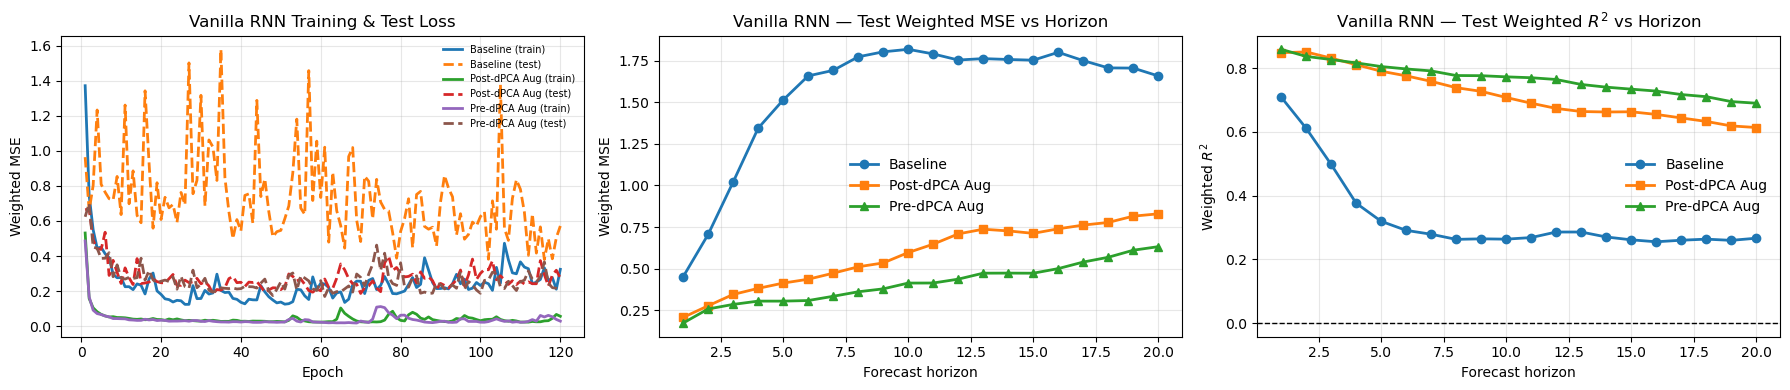

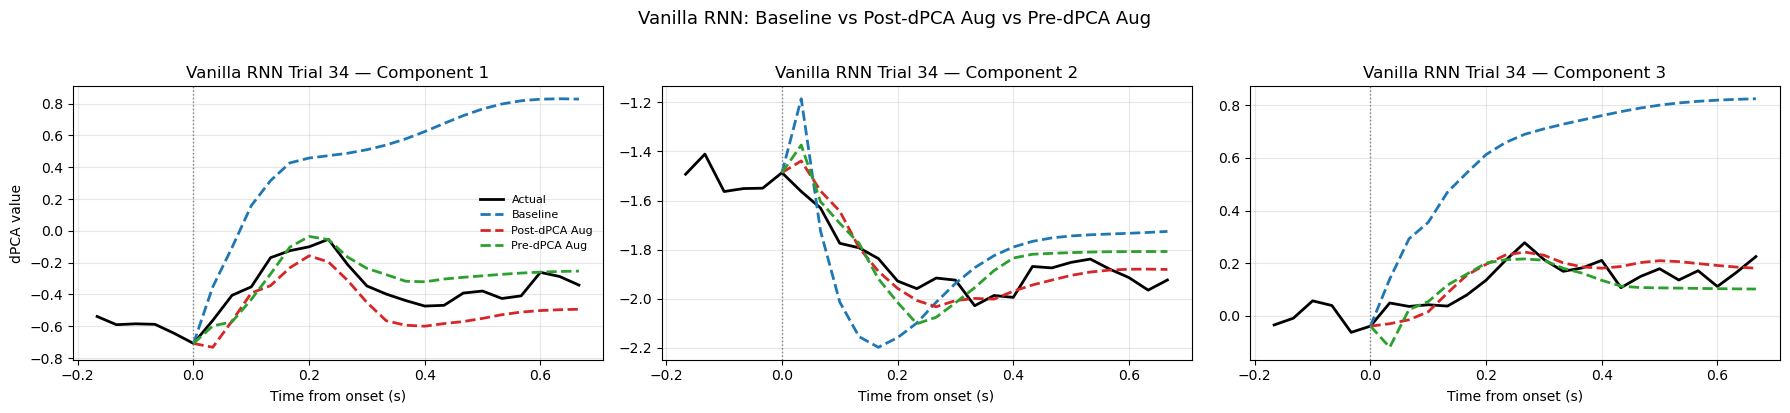

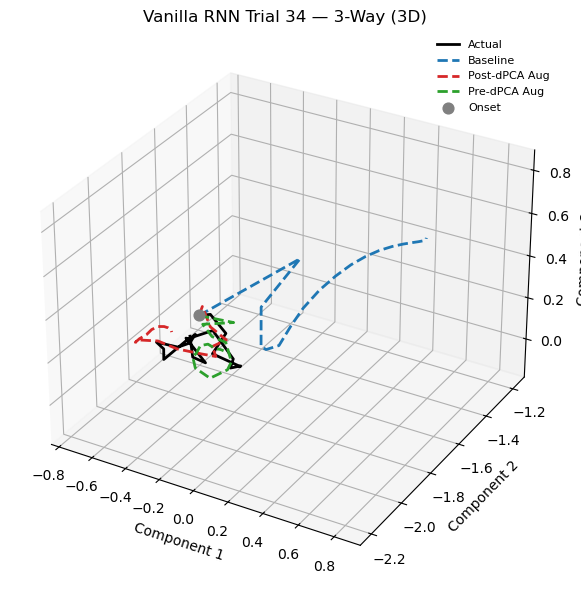

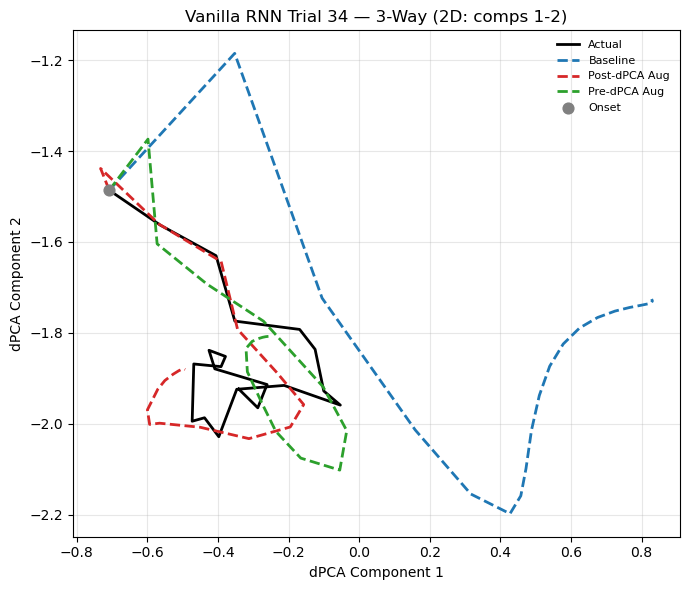


VANILLA RNN SUMMARY
Architecture: Vanilla RNN 2-layer, hidden=256, dropout=0.1
Params: 659,486

Training times:
  Baseline:      7.83s (0.0652 s/epoch)
  Post-dPCA Aug: 67.59s (0.5632 s/epoch)
  Pre-dPCA Aug:  66.90s (0.5575 s/epoch)

Inference times (test batch):
  Baseline:      0.002558s
  Post-dPCA Aug: 0.002576s
  Pre-dPCA Aug:  0.002549s

3-Way Weighted Metrics Comparison (all 20 horizons):
   h     Base R²    Post R²     Pre R²
t+01     0.70933    0.84837    0.85891
t+02     0.61134    0.85073    0.83675
t+03     0.49803    0.83134    0.82685
t+04     0.37625    0.81075    0.81638
t+05     0.31934    0.79023    0.80488
t+06     0.29083    0.77574    0.79736
t+07     0.27868    0.75846    0.79113
t+08     0.26253    0.73849    0.77669
t+09     0.26424    0.72707    0.77618
t+10     0.26323    0.70781    0.77255
t+11     0.26820    0.68984    0.76979
t+12     0.28559    0.67350    0.76425
t+13     0.28565    0.66373    0.74865
t+14     0.27008    0.66226    0.74022
t+15     0.261

In [10]:
# =============================================================================
# Vanilla RNN Forecasting — Baseline + Post-dPCA Aug + Pre-dPCA Aug
# =============================================================================
# Same experimental setup as the GRU cells (8, 10, 12) but with nn.RNN / nn.RNNCell.

import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Re-derive latent trajectories (same as cell 8)
stim_mean_rnn = np.mean(R.reshape((N, -1)), axis=1)[:, None, None]
neural_centered_rnn = neural_data - stim_mean_rnn
z_all_rnn = dpca.transform(neural_centered_rnn)
z_trial_rnn = np.concatenate([z_all_rnn['s'], z_all_rnn['t'], z_all_rnn['st']], axis=0)
z_trial_rnn = np.transpose(z_trial_rnn, (1, 2, 0)).astype(np.float32)
z_trial_rnn = apply_ema(z_trial_rnn, alpha=EMA_ALPHA)

v_rnn = np.transpose(s0['is_target'], (1, 2, 0)).astype(np.float32)

n_trials_rnn, T_rnn, d_z_rnn = z_trial_rnn.shape
n_cells_rnn = v_rnn.shape[-1]

horizon_rnn = 20
context_len_rnn = zero_idx + 1

z_train_rnn = z_trial_rnn[train_indices]
z_mean_rnn = z_train_rnn.mean(axis=(0, 1), keepdims=True)
z_std_rnn = z_train_rnn.std(axis=(0, 1), keepdims=True) + 1e-6
z_trial_n_rnn = (z_trial_rnn - z_mean_rnn) / z_std_rnn

component_var_rnn = z_train_rnn.var(axis=(0, 1))
component_weights_rnn = component_var_rnn / (component_var_rnn.sum() + 1e-12)
component_weights_t_rnn = torch.from_numpy(component_weights_rnn).float().to(device)

print(f"Vanilla RNN: z_trial={z_trial_rnn.shape}, context={context_len_rnn}, horizon={horizon_rnn}")

# -----------------------------
# 1) Vanilla RNN model
# -----------------------------

class VanillaRNNStimForecast(nn.Module):
    """Encoder-decoder forecast model using vanilla RNN (tanh nonlinearity)."""

    def __init__(self, latent_dim, stim_dim, hidden_dim=256, num_layers=2, dropout=0.1):
        super().__init__()
        self.encoder = nn.RNN(
            input_size=latent_dim + stim_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity='tanh',
            dropout=0.0,
        )
        self.num_layers = num_layers
        self.decoder_cells = nn.ModuleList()
        self.decoder_cells.append(nn.RNNCell(latent_dim + stim_dim, hidden_dim, nonlinearity='tanh'))
        for _ in range(1, num_layers):
            self.decoder_cells.append(nn.RNNCell(hidden_dim, hidden_dim, nonlinearity='tanh'))
        self.readout = nn.Linear(hidden_dim, latent_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, context_z, context_v, future_v, target_z=None, teacher_forcing=0.0):
        enc_in = torch.cat([context_z, context_v], dim=-1)
        _, h_n = self.encoder(enc_in)  # h_n: (num_layers, batch, hidden)

        prev_z = context_z[:, -1, :]
        preds = []
        H = future_v.shape[1]

        for k in range(H):
            dec_in = torch.cat([prev_z, future_v[:, k, :]], dim=-1)
            h_in = dec_in
            h_new = []
            for layer_idx, cell in enumerate(self.decoder_cells):
                h_l = cell(h_in, h_n[layer_idx])
                h_l = self.dropout(h_l)
                h_new.append(h_l)
                h_in = h_l
            h_n = torch.stack(h_new, dim=0)
            pred_z = self.readout(h_n[-1])
            preds.append(pred_z.unsqueeze(1))

            if self.training and target_z is not None and teacher_forcing > 0.0:
                use_teacher = (torch.rand(pred_z.shape[0], device=pred_z.device) < teacher_forcing).float().unsqueeze(-1)
                prev_z = use_teacher * target_z[:, k, :] + (1.0 - use_teacher) * pred_z
            else:
                prev_z = pred_z

        return torch.cat(preds, dim=1)


# -----------------------------
# 2) Reuse datasets from earlier cells
# -----------------------------

# Baseline dataset (cell 8)
class OnsetForecastDatasetRNN(Dataset):
    def __init__(self, trial_indices):
        self.trial_indices = np.array(trial_indices)
    def __len__(self):
        return len(self.trial_indices)
    def __getitem__(self, idx):
        tr = self.trial_indices[idx]
        return (
            torch.from_numpy(z_trial_n_rnn[tr, :context_len_rnn, :]),
            torch.from_numpy(v_rnn[tr, :context_len_rnn, :]),
            torch.from_numpy(v_rnn[tr, zero_idx + 1:zero_idx + 1 + horizon_rnn, :]),
            torch.from_numpy(z_trial_n_rnn[tr, zero_idx + 1:zero_idx + 1 + horizon_rnn, :]),
        )

train_ds_rnn = OnsetForecastDatasetRNN(train_indices)
test_ds_rnn = OnsetForecastDatasetRNN(test_indices)
train_loader_rnn = DataLoader(train_ds_rnn, batch_size=32, shuffle=True)
test_loader_rnn = DataLoader(test_ds_rnn, batch_size=len(test_ds_rnn), shuffle=False)

# Post-dPCA augmented dataset (reuse AugmentedOnsetForecastDataset from cell 10)
# Need to rebuild it using the rnn-local z_trial_n_rnn arrays
class AugmentedOnsetForecastDatasetRNN(Dataset):
    def __init__(self, trial_indices, stim_mask, n_augment, noise_std_arr, aug_start, aug_end):
        self.noise_std = noise_std_arr
        self.aug_start = aug_start
        self.aug_end = aug_end
        self.items = []
        for i, tr in enumerate(trial_indices):
            self.items.append((tr, 0))
            if stim_mask[i]:
                for k in range(1, n_augment + 1):
                    self.items.append((tr, k))
    def __len__(self):
        return len(self.items)
    def __getitem__(self, idx):
        tr, copy_idx = self.items[idx]
        context_z = z_trial_n_rnn[tr, :context_len_rnn, :].copy()
        context_v = v_rnn[tr, :context_len_rnn, :]
        future_v  = v_rnn[tr, zero_idx + 1:zero_idx + 1 + horizon_rnn, :]
        target_z  = z_trial_n_rnn[tr, zero_idx + 1:zero_idx + 1 + horizon_rnn, :].copy()
        if copy_idx > 0:
            ctx_noise_start = aug_start
            ctx_noise_end = min(aug_end, context_len_rnn)
            if ctx_noise_end > ctx_noise_start:
                n_ctx = ctx_noise_end - ctx_noise_start
                context_z[ctx_noise_start:ctx_noise_end, :] += (
                    np.random.randn(n_ctx, len(self.noise_std)).astype(np.float32) * self.noise_std
                )
            tgt_global_start = zero_idx + 1
            tgt_global_end = zero_idx + 1 + horizon_rnn
            tgt_noise_start = max(self.aug_start, tgt_global_start) - tgt_global_start
            tgt_noise_end = min(self.aug_end, tgt_global_end) - tgt_global_start
            if tgt_noise_end > tgt_noise_start:
                n_tgt = tgt_noise_end - tgt_noise_start
                target_z[tgt_noise_start:tgt_noise_end, :] += (
                    np.random.randn(n_tgt, len(self.noise_std)).astype(np.float32) * self.noise_std
                )
        return (
            torch.from_numpy(context_z),
            torch.from_numpy(context_v),
            torch.from_numpy(future_v),
            torch.from_numpy(target_z),
        )

aug_train_ds_rnn = AugmentedOnsetForecastDatasetRNN(
    train_indices, stim_mask=train_stim_mask, n_augment=n_augment,
    noise_std_arr=noise_std, aug_start=aug_start, aug_end=aug_end
)
aug_train_loader_rnn = DataLoader(aug_train_ds_rnn, batch_size=32, shuffle=True)

# Pre-dPCA augmented dataset (reuse z_aug_trial_n and aug_v from cell 12)
class PreDPCAAugDatasetRNN(Dataset):
    def __init__(self, z_data, v_data):
        self.z = z_data
        self.v = v_data
    def __len__(self):
        return self.z.shape[0]
    def __getitem__(self, idx):
        return (
            torch.from_numpy(self.z[idx, :context_len_rnn, :]),
            torch.from_numpy(self.v[idx, :context_len_rnn, :]),
            torch.from_numpy(self.v[idx, zero_idx + 1:zero_idx + 1 + horizon_rnn, :]),
            torch.from_numpy(self.z[idx, zero_idx + 1:zero_idx + 1 + horizon_rnn, :]),
        )

predpca_train_ds_rnn = PreDPCAAugDatasetRNN(z_aug_trial_n, aug_v)
predpca_train_loader_rnn = DataLoader(predpca_train_ds_rnn, batch_size=32, shuffle=True)

print(f"Baseline train: {len(train_ds_rnn)} | Post-dPCA aug train: {len(aug_train_ds_rnn)} | Pre-dPCA aug train: {len(predpca_train_ds_rnn)}")

# -----------------------------
# 3) Training helper
# -----------------------------

def weighted_mse_loss_rnn(pred, target, weights):
    per_comp_mse = ((pred - target) ** 2).mean(dim=(0, 1))
    return (weights * per_comp_mse).sum()

def train_vanilla_rnn(model_rnn, train_loader, n_epochs, tag="", test_loader_eval=None):
    optimizer_rnn = torch.optim.Adam(model_rnn.parameters(), lr=1e-3, weight_decay=1e-5)
    loss_hist = []
    test_loss_hist = []
    t0 = time.perf_counter()
    ds_len = len(train_loader.dataset)
    test_ds_len = len(test_loader_eval.dataset) if test_loader_eval is not None else 0

    for epoch in range(1, n_epochs + 1):
        model_rnn.train()
        running = 0.0
        tf_ratio = 0.7 + (0.1 - 0.7) * ((epoch - 1) / max(n_epochs - 1, 1))

        for cz_b, cv_b, fv_b, tz_b in train_loader:
            cz_b = cz_b.to(device); cv_b = cv_b.to(device)
            fv_b = fv_b.to(device); tz_b = tz_b.to(device)

            optimizer_rnn.zero_grad()
            pred_b = model_rnn(cz_b, cv_b, fv_b, target_z=tz_b, teacher_forcing=tf_ratio)
            loss = weighted_mse_loss_rnn(pred_b, tz_b, component_weights_t_rnn)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_rnn.parameters(), 1.0)
            optimizer_rnn.step()
            running += loss.item() * cz_b.shape[0]

        ep_loss = running / ds_len
        loss_hist.append(ep_loss)

        # Compute test loss (open-loop, no teacher forcing)
        if test_loader_eval is not None:
            model_rnn.eval()
            with torch.no_grad():
                test_running = 0.0
                for cz_b, cv_b, fv_b, tz_b in test_loader_eval:
                    cz_b = cz_b.to(device); cv_b = cv_b.to(device)
                    fv_b = fv_b.to(device); tz_b = tz_b.to(device)
                    pred_b = model_rnn(cz_b, cv_b, fv_b, target_z=None, teacher_forcing=0.0)
                    test_running += weighted_mse_loss_rnn(pred_b, tz_b, component_weights_t_rnn).item() * cz_b.shape[0]
                test_loss_hist.append(test_running / test_ds_len)

        if epoch % 20 == 0 or epoch == 1:
            test_str = f" | test_loss={test_loss_hist[-1]:.6f}" if test_loss_hist else ""
            print(f"[{tag}] Epoch {epoch:03d}/{n_epochs} | loss={ep_loss:.6f}{test_str} | tf={tf_ratio:.3f}")

    train_time = time.perf_counter() - t0
    return loss_hist, train_time, test_loss_hist

def eval_vanilla_rnn(model_rnn, test_loader):
    model_rnn.eval()
    with torch.no_grad():
        cz_t, cv_t, fv_t, tz_t = next(iter(test_loader))
        cz_t = cz_t.to(device); cv_t = cv_t.to(device); fv_t = fv_t.to(device)
        if device.type == 'cuda': torch.cuda.synchronize()
        t0 = time.perf_counter()
        pred_t = model_rnn(cz_t, cv_t, fv_t, target_z=None, teacher_forcing=0.0)
        if device.type == 'cuda': torch.cuda.synchronize()
        inf_time = time.perf_counter() - t0

    pred_np = pred_t.cpu().numpy()
    tgt_np = tz_t.numpy()
    pred_dn = pred_np * z_std_rnn + z_mean_rnn
    tgt_dn = tgt_np * z_std_rnn + z_mean_rnn

    wmse, wr2 = [], []
    for h in range(horizon_rnn):
        yt, yp = tgt_dn[:, h, :], pred_dn[:, h, :]
        mse_c = np.mean((yp - yt) ** 2, axis=0)
        wmse.append(float(np.sum(component_weights_rnn * mse_c)))
        r2c = np.zeros(d_z_rnn)
        for c in range(d_z_rnn):
            r2c[c] = r2_score(yt[:, c], yp[:, c]) if np.var(yt[:, c]) > 1e-12 else 0.0
        wr2.append(float(np.sum(component_weights_rnn * r2c)))

    return wmse, wr2, inf_time

# -----------------------------
# 4) Train all three vanilla RNN models
# -----------------------------

n_epochs_rnn = 120

# 4a) Baseline
print("=" * 60)
print("VANILLA RNN — BASELINE")
print("=" * 60)
model_rnn_base = VanillaRNNStimForecast(
    latent_dim=d_z_rnn, stim_dim=n_cells_rnn, hidden_dim=256, num_layers=2, dropout=0.1
).to(device)
loss_hist_rnn_base, train_time_rnn_base, test_loss_hist_rnn_base = train_vanilla_rnn(
    model_rnn_base, train_loader_rnn, n_epochs_rnn, tag="RNN Base", test_loader_eval=test_loader_rnn)
wmse_rnn_base, wr2_rnn_base, inf_time_rnn_base = eval_vanilla_rnn(
    model_rnn_base, test_loader_rnn)

# 4b) Post-dPCA augmented
print("\n" + "=" * 60)
print("VANILLA RNN — POST-dPCA AUGMENTATION")
print("=" * 60)
model_rnn_postaug = VanillaRNNStimForecast(
    latent_dim=d_z_rnn, stim_dim=n_cells_rnn, hidden_dim=256, num_layers=2, dropout=0.1
).to(device)
loss_hist_rnn_postaug, train_time_rnn_postaug, test_loss_hist_rnn_postaug = train_vanilla_rnn(
    model_rnn_postaug, aug_train_loader_rnn, n_epochs_rnn, tag="RNN PostAug", test_loader_eval=test_loader_rnn)
wmse_rnn_postaug, wr2_rnn_postaug, inf_time_rnn_postaug = eval_vanilla_rnn(
    model_rnn_postaug, test_loader_rnn)

# 4c) Pre-dPCA augmented
print("\n" + "=" * 60)
print("VANILLA RNN — PRE-dPCA AUGMENTATION")
print("=" * 60)
model_rnn_preaug = VanillaRNNStimForecast(
    latent_dim=d_z_rnn, stim_dim=n_cells_rnn, hidden_dim=256, num_layers=2, dropout=0.1
).to(device)
loss_hist_rnn_preaug, train_time_rnn_preaug, test_loss_hist_rnn_preaug = train_vanilla_rnn(
    model_rnn_preaug, predpca_train_loader_rnn, n_epochs_rnn, tag="RNN PreAug", test_loader_eval=test_loader_rnn)
wmse_rnn_preaug, wr2_rnn_preaug, inf_time_rnn_preaug = eval_vanilla_rnn(
    model_rnn_preaug, test_loader_rnn)

# -----------------------------
# 5) Three-way comparison plots
# -----------------------------

horizons_rnn = np.arange(1, horizon_rnn + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Training curves (with test losses)
axes[0].plot(np.arange(1, n_epochs_rnn + 1), loss_hist_rnn_base, lw=2, label='Baseline (train)')
axes[0].plot(np.arange(1, n_epochs_rnn + 1), test_loss_hist_rnn_base, lw=2, ls='--', label='Baseline (test)')
axes[0].plot(np.arange(1, n_epochs_rnn + 1), loss_hist_rnn_postaug, lw=2, label='Post-dPCA Aug (train)')
axes[0].plot(np.arange(1, n_epochs_rnn + 1), test_loss_hist_rnn_postaug, lw=2, ls='--', label='Post-dPCA Aug (test)')
axes[0].plot(np.arange(1, n_epochs_rnn + 1), loss_hist_rnn_preaug, lw=2, label='Pre-dPCA Aug (train)')
axes[0].plot(np.arange(1, n_epochs_rnn + 1), test_loss_hist_rnn_preaug, lw=2, ls='--', label='Pre-dPCA Aug (test)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Weighted MSE')
axes[0].set_title('Vanilla RNN Training & Test Loss')
axes[0].legend(frameon=False, fontsize=7); axes[0].grid(alpha=0.3)

# Weighted MSE vs horizon
axes[1].plot(horizons_rnn, wmse_rnn_base, marker='o', lw=2, label='Baseline')
axes[1].plot(horizons_rnn, wmse_rnn_postaug, marker='s', lw=2, label='Post-dPCA Aug')
axes[1].plot(horizons_rnn, wmse_rnn_preaug, marker='^', lw=2, label='Pre-dPCA Aug')
axes[1].set_xlabel('Forecast horizon'); axes[1].set_ylabel('Weighted MSE')
axes[1].set_title('Vanilla RNN — Test Weighted MSE vs Horizon')
axes[1].legend(frameon=False); axes[1].grid(alpha=0.3)

# Weighted R² vs horizon
axes[2].plot(horizons_rnn, wr2_rnn_base, marker='o', lw=2, label='Baseline')
axes[2].plot(horizons_rnn, wr2_rnn_postaug, marker='s', lw=2, label='Post-dPCA Aug')
axes[2].plot(horizons_rnn, wr2_rnn_preaug, marker='^', lw=2, label='Pre-dPCA Aug')
axes[2].axhline(0.0, color='k', ls='--', lw=1)
axes[2].set_xlabel('Forecast horizon'); axes[2].set_ylabel('Weighted $R^2$')
axes[2].set_title('Vanilla RNN — Test Weighted $R^2$ vs Horizon')
axes[2].legend(frameon=False); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# -----------------------------
# 6) Trial 34 — three-way trajectory comparison
# -----------------------------

trial_id_rnn = 34
pre_steps_rnn = 5

cz_s = torch.from_numpy(z_trial_n_rnn[trial_id_rnn, :context_len_rnn, :]).unsqueeze(0).to(device)
cv_s = torch.from_numpy(v_rnn[trial_id_rnn, :context_len_rnn, :]).unsqueeze(0).to(device)
fv_s = torch.from_numpy(v_rnn[trial_id_rnn, zero_idx + 1:zero_idx + 1 + horizon_rnn, :]).unsqueeze(0).to(device)

with torch.no_grad():
    pred_base_rnn_n = model_rnn_base(cz_s, cv_s, fv_s, target_z=None, teacher_forcing=0.0)
    pred_post_rnn_n = model_rnn_postaug(cz_s, cv_s, fv_s, target_z=None, teacher_forcing=0.0)
    pred_pre_rnn_n  = model_rnn_preaug(cz_s, cv_s, fv_s, target_z=None, teacher_forcing=0.0)

pred_base_rnn = pred_base_rnn_n.squeeze(0).cpu().numpy() * z_std_rnn.squeeze((0, 1)) + z_mean_rnn.squeeze((0, 1))
pred_post_rnn = pred_post_rnn_n.squeeze(0).cpu().numpy() * z_std_rnn.squeeze((0, 1)) + z_mean_rnn.squeeze((0, 1))
pred_pre_rnn  = pred_pre_rnn_n.squeeze(0).cpu().numpy() * z_std_rnn.squeeze((0, 1)) + z_mean_rnn.squeeze((0, 1))

start_rnn = zero_idx - pre_steps_rnn
end_rnn   = zero_idx + 1 + horizon_rnn
t_window_rnn  = time_axis[start_rnn:end_rnn]
true_window_rnn = z_trial_rnn[trial_id_rnn, start_rnn:end_rnn, :]

def _build_pw(pred, dz, pre, h):
    w = np.full((pre + 1 + h, dz), np.nan, dtype=np.float32)
    w[pre, :] = true_window_rnn[pre, :]
    w[pre + 1:, :] = pred
    return w

pw_base_rnn = _build_pw(pred_base_rnn, d_z_rnn, pre_steps_rnn, horizon_rnn)
pw_post_rnn = _build_pw(pred_post_rnn, d_z_rnn, pre_steps_rnn, horizon_rnn)
pw_pre_rnn  = _build_pw(pred_pre_rnn,  d_z_rnn, pre_steps_rnn, horizon_rnn)

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
for comp in range(3):
    axes[comp].plot(t_window_rnn, true_window_rnn[:, comp], lw=2, label='Actual', color='black')
    axes[comp].plot(t_window_rnn, pw_base_rnn[:, comp], lw=2, ls='--', label='Baseline', color='tab:blue')
    axes[comp].plot(t_window_rnn, pw_post_rnn[:, comp], lw=2, ls='--', label='Post-dPCA Aug', color='tab:red')
    axes[comp].plot(t_window_rnn, pw_pre_rnn[:, comp],  lw=2, ls='--', label='Pre-dPCA Aug', color='tab:green')
    axes[comp].axvline(0.0, color='gray', ls=':', lw=1)
    axes[comp].set_title(f'Vanilla RNN Trial {trial_id_rnn} — Component {comp + 1}')
    axes[comp].set_xlabel('Time from onset (s)')
    axes[comp].grid(alpha=0.3)
axes[0].set_ylabel('dPCA value')
axes[0].legend(frameon=False, fontsize=8)
plt.suptitle('Vanilla RNN: Baseline vs Post-dPCA Aug vs Pre-dPCA Aug', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

# 3D comparison
onset_rnn = z_trial_rnn[trial_id_rnn, zero_idx, :]
true_post_rnn = z_trial_rnn[trial_id_rnn, zero_idx + 1:zero_idx + 1 + horizon_rnn, :]
true_from_onset_rnn     = np.vstack([onset_rnn[None, :], true_post_rnn])
base_from_onset_rnn     = np.vstack([onset_rnn[None, :], pred_base_rnn])
postdpca_from_onset_rnn = np.vstack([onset_rnn[None, :], pred_post_rnn])
predpca_from_onset_rnn  = np.vstack([onset_rnn[None, :], pred_pre_rnn])

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(true_from_onset_rnn[:, 0], true_from_onset_rnn[:, 1], true_from_onset_rnn[:, 2],
        color='black', lw=2, label='Actual')
ax.plot(base_from_onset_rnn[:, 0], base_from_onset_rnn[:, 1], base_from_onset_rnn[:, 2],
        color='tab:blue', lw=2, ls='--', label='Baseline')
ax.plot(postdpca_from_onset_rnn[:, 0], postdpca_from_onset_rnn[:, 1], postdpca_from_onset_rnn[:, 2],
        color='tab:red', lw=2, ls='--', label='Post-dPCA Aug')
ax.plot(predpca_from_onset_rnn[:, 0], predpca_from_onset_rnn[:, 1], predpca_from_onset_rnn[:, 2],
        color='tab:green', lw=2, ls='--', label='Pre-dPCA Aug')
ax.scatter(onset_rnn[0], onset_rnn[1], onset_rnn[2], color='gray', s=60, zorder=5, label='Onset')
ax.set_title(f'Vanilla RNN Trial {trial_id_rnn} — 3-Way (3D)')
ax.set_xlabel('Component 1'); ax.set_ylabel('Component 2'); ax.set_zlabel('Component 3')
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

# 2D trajectory (comps 1 & 2)
fig, ax2d = plt.subplots(figsize=(7, 6))
ax2d.plot(true_from_onset_rnn[:, 0], true_from_onset_rnn[:, 1], color='black', lw=2, label='Actual')
ax2d.plot(base_from_onset_rnn[:, 0], base_from_onset_rnn[:, 1], color='tab:blue', lw=2, ls='--', label='Baseline')
ax2d.plot(postdpca_from_onset_rnn[:, 0], postdpca_from_onset_rnn[:, 1], color='tab:red', lw=2, ls='--', label='Post-dPCA Aug')
ax2d.plot(predpca_from_onset_rnn[:, 0], predpca_from_onset_rnn[:, 1], color='tab:green', lw=2, ls='--', label='Pre-dPCA Aug')
ax2d.scatter(onset_rnn[0], onset_rnn[1], color='gray', s=60, zorder=5, label='Onset')
ax2d.set_title(f'Vanilla RNN Trial {trial_id_rnn} — 3-Way (2D: comps 1-2)')
ax2d.set_xlabel('dPCA Component 1'); ax2d.set_ylabel('dPCA Component 2')
ax2d.legend(frameon=False, fontsize=8); ax2d.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# -----------------------------
# 7) Summary table
# -----------------------------

print("\n" + "=" * 70)
print("VANILLA RNN SUMMARY")
print("=" * 70)
print(f"Architecture: Vanilla RNN 2-layer, hidden=256, dropout=0.1")
print(f"Params: {sum(p.numel() for p in model_rnn_base.parameters() if p.requires_grad):,}")
print(f"\nTraining times:")
print(f"  Baseline:      {train_time_rnn_base:.2f}s ({train_time_rnn_base / n_epochs_rnn:.4f} s/epoch)")
print(f"  Post-dPCA Aug: {train_time_rnn_postaug:.2f}s ({train_time_rnn_postaug / n_epochs_rnn:.4f} s/epoch)")
print(f"  Pre-dPCA Aug:  {train_time_rnn_preaug:.2f}s ({train_time_rnn_preaug / n_epochs_rnn:.4f} s/epoch)")
print(f"\nInference times (test batch):")
print(f"  Baseline:      {inf_time_rnn_base:.6f}s")
print(f"  Post-dPCA Aug: {inf_time_rnn_postaug:.6f}s")
print(f"  Pre-dPCA Aug:  {inf_time_rnn_preaug:.6f}s")

print(f"\n3-Way Weighted Metrics Comparison (all {horizon_rnn} horizons):")
print(f"{'h':>4s}  {'Base R²':>10s} {'Post R²':>10s} {'Pre R²':>10s}")
for h in range(horizon_rnn):
    print(f"t+{h+1:02d}  "
          f"{wr2_rnn_base[h]:10.5f} {wr2_rnn_postaug[h]:10.5f} {wr2_rnn_preaug[h]:10.5f}")

## Closed-Loop Vanilla RNN — Observation-Corrected Forecasting (Post-dPCA Aug)

### Motivation

The open-loop RNN (cell 14) predicts the full forecast horizon autoregressively by feeding its own predictions back as input at each decoder step. Any prediction error at step $k$ corrupts the input to step $k+1$ and all subsequent steps, causing **error accumulation** that degrades long-horizon accuracy.

In a **closed-loop** (online) setting, the system has access to the **true observation** $\mathbf{z}_{t_0+k}^{\text{obs}}$ at each timestep. This motivates a model that can exploit the observation to correct its internal state before predicting the next step — analogous to the **innovation update** in a Kalman filter.

### Architecture

The closed-loop RNN extends the vanilla RNN encoder–decoder with a **learned correction network** that maps prediction errors (innovations) to hidden-state updates.

#### Encoder

Identical to the vanilla RNN:

$$
\mathbf{h}^{(\ell)}_t = \tanh\!\bigl(W^{(\ell)}_{ih}\,\mathbf{h}^{(\ell-1)}_t + W^{(\ell)}_{hh}\,\mathbf{h}^{(\ell)}_{t-1} + \mathbf{b}^{(\ell)}\bigr)
$$

#### Decoder — with Kalman-like correction

At each forecast step $k$:

1. **Predict** using the current hidden state (same as open-loop):

$$
\hat{\mathbf{z}}_{t_0+1+k} = W_o\,\mathbf{h}^{(L)}_{\text{dec},k} + \mathbf{b}_o
$$

2. **Compute innovation** (prediction error):

$$
\mathbf{e}_k = \mathbf{z}^{\text{obs}}_{t_0+1+k} - \hat{\mathbf{z}}_{t_0+1+k}
$$

3. **Apply learned correction** to the top-layer hidden state:

$$
\mathbf{h}^{(L)}_{\text{dec},k} \leftarrow \mathbf{h}^{(L)}_{\text{dec},k} + \underbrace{K_\theta(\mathbf{e}_k)}_{\text{correction network}}
$$

where $K_\theta$ is a small MLP that acts as a **learned Kalman gain**:

$$
K_\theta(\mathbf{e}) = W_2\,\tanh(W_1\,\mathbf{e} + \mathbf{b}_1) + \mathbf{b}_2
$$

4. **Feed back the true observation** as input to the next step:

$$
\mathbf{d}_{k+1} = [\mathbf{z}^{\text{obs}}_{t_0+1+k} \,\|\, \mathbf{v}_{t_0+2+k}]
$$

### Training

During training, the model always operates in closed-loop mode: the ground-truth target $\mathbf{z}_{t_0+1+k}$ serves as the "observation" for correction. The loss is computed on the **pre-correction predictions**, so the model learns to both:
- Make good initial predictions
- Use corrections to improve subsequent predictions

Standard teacher forcing decay is still applied for the **prediction input** (before correction), providing curriculum learning from guided to autonomous prediction.

### Evaluation

At test time, two modes are compared:
1. **Open-loop**: pure autoregressive (no observations available) — uses the model's own predictions as feedback
2. **Closed-loop**: at each step, the true observation is revealed, the correction is applied, and the true observation is fed back

The closed-loop evaluation shows how much the model can recover when given access to online measurements — relevant for real-time BCI applications where neural observations are available with a one-step delay.

### Training Data

Post-dPCA augmentation (same as "Post-dPCA Aug" in cell 14): clean originals + $K=15$ noisy copies with noise injected in the normalized latent space after dPCA + EMA.

Closed-Loop RNN params: 733,214
Training on post-dPCA augmented data (1359 samples)
Epoch 001/120 | loss=0.318633 | tf=0.700
Epoch 020/120 | loss=0.024257 | tf=0.604
Epoch 040/120 | loss=0.023233 | tf=0.503
Epoch 060/120 | loss=0.019347 | tf=0.403
Epoch 080/120 | loss=0.018438 | tf=0.302
Epoch 100/120 | loss=0.017669 | tf=0.201
Epoch 120/120 | loss=0.018424 | tf=0.100

Training time: 78.10s (0.6509 s/epoch)
Inference — Open-loop:  0.002531s
Inference — Closed-loop: 0.003036s


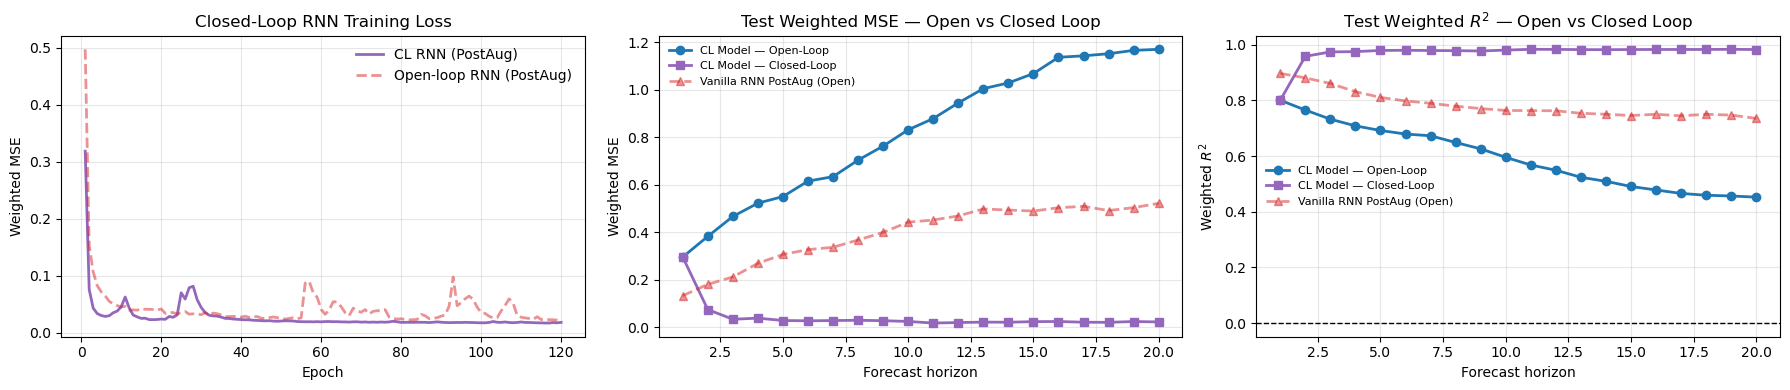

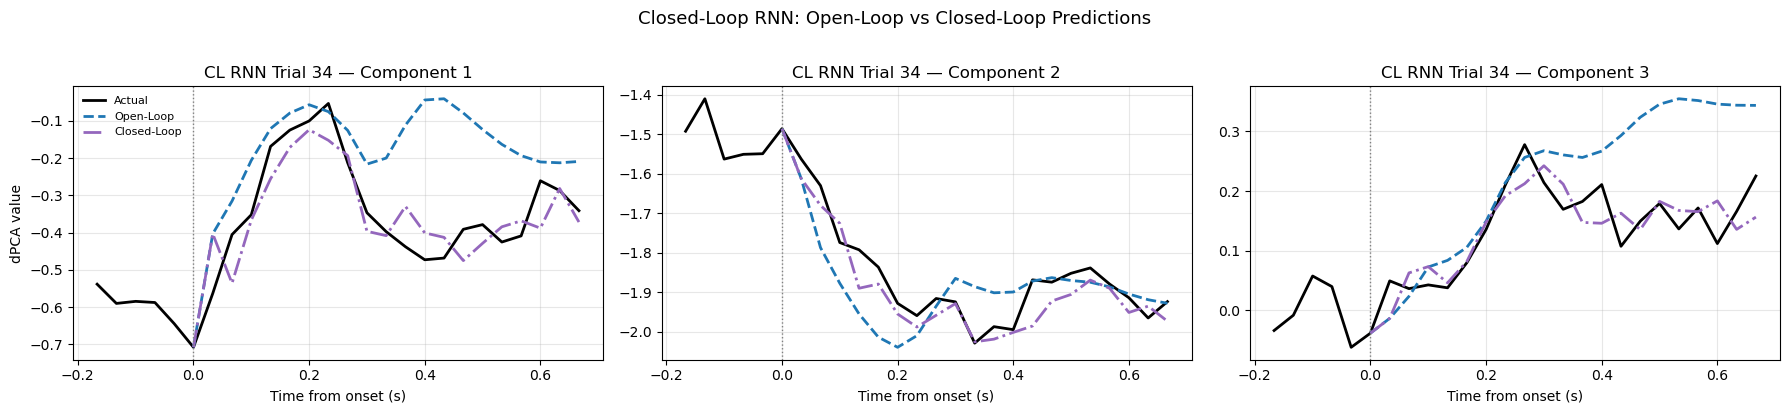

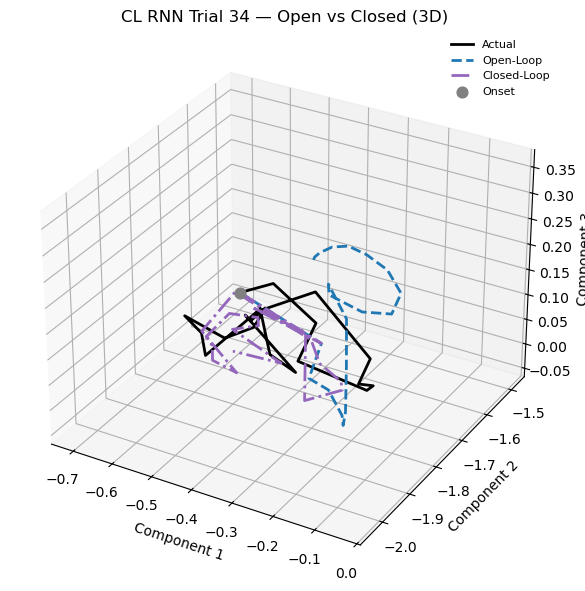

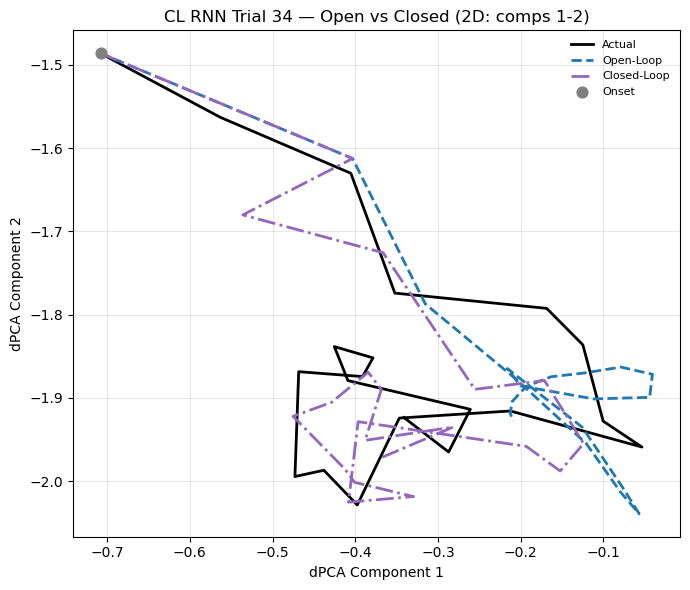


CLOSED-LOOP VANILLA RNN SUMMARY (Post-dPCA Aug)
Architecture: Vanilla RNN 2-layer, hidden=256, dropout=0.1 + correction network
Parameters: 733,214
Training data: Post-dPCA augmented (1359 samples)
Training time: 78.10s (0.6509 s/epoch)

Inference times:
  Open-loop:   0.002531s
  Closed-loop: 0.003036s

Horizon-wise Metrics — Open vs Closed Loop:
   h     Open R²  Closed R²    Open MSE Closed MSE
t+01     0.80067    0.80067     0.29551    0.29551
t+02     0.76546    0.95847     0.38235    0.07435
t+03     0.73261    0.97439     0.46622    0.03337
t+04     0.70858    0.97543     0.52229    0.03815
t+05     0.69203    0.97961     0.55008    0.02816
t+06     0.67922    0.98025     0.61508    0.02694
t+07     0.67300    0.97946     0.63387    0.02795
t+08     0.64888    0.97880     0.70352    0.02922
t+09     0.62605    0.97780     0.76260    0.02738
t+10     0.59554    0.98089     0.83125    0.02417
t+11     0.56802    0.98370     0.87850    0.01752
t+12     0.54922    0.98347     0.944

In [ ]:
# =============================================================================
# Closed-Loop Vanilla RNN — Observation-Corrected Forecasting (Post-dPCA Aug)
# =============================================================================

import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# ---------------------------------------------------------------
# 1) Closed-Loop Vanilla RNN Model
# ---------------------------------------------------------------

class ClosedLoopVanillaRNN(nn.Module):
    """
    Vanilla RNN encoder-decoder with a learned correction network.
    In closed-loop mode, at each decoder step the model:
      1. Predicts z_{t+1}
      2. Receives the true observation z_obs_{t+1}
      3. Computes innovation e = z_obs - z_pred
      4. Applies a learned correction to the top-layer hidden state
      5. Feeds back the true observation as input to the next step
    """

    def __init__(self, latent_dim, stim_dim, hidden_dim=256, num_layers=2, dropout=0.1):
        super().__init__()
        self.latent_dim = latent_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Encoder: standard vanilla RNN
        self.encoder = nn.RNN(
            input_size=latent_dim + stim_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity='tanh',
            dropout=0.0,
        )

        # Decoder cells: vanilla RNN cells (one per layer)
        self.decoder_cells = nn.ModuleList()
        self.decoder_cells.append(nn.RNNCell(latent_dim + stim_dim, hidden_dim, nonlinearity='tanh'))
        for _ in range(1, num_layers):
            self.decoder_cells.append(nn.RNNCell(hidden_dim, hidden_dim, nonlinearity='tanh'))

        # Linear readout from top-layer hidden state to latent prediction
        self.readout = nn.Linear(hidden_dim, latent_dim)
        self.dropout = nn.Dropout(dropout)

        # Learned correction network (acts as a learned Kalman gain)
        # Maps prediction error (innovation) to a hidden-state correction
        self.correction_net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
        )

    def forward(self, context_z, context_v, future_v,
                target_z=None, teacher_forcing=0.0,
                closed_loop=False, observations=None):
        """
        Args:
            context_z: (batch, context_len, d_z) — priming context latents
            context_v: (batch, context_len, n_cells) — priming context stimuli
            future_v:  (batch, H, n_cells) — future stimuli for forecast horizon
            target_z:  (batch, H, d_z) — ground truth (for teacher forcing / closed-loop training)
            teacher_forcing: float — probability of using ground truth as input (open-loop only)
            closed_loop: bool — if True, apply correction from observations at each step
            observations: (batch, H, d_z) — true observations for closed-loop correction
                          (defaults to target_z during training if not provided)
        """
        # Encode context
        enc_in = torch.cat([context_z, context_v], dim=-1)
        _, h_n = self.encoder(enc_in)  # h_n: (num_layers, batch, hidden)

        prev_z = context_z[:, -1, :]  # onset latent state
        preds = []
        H = future_v.shape[1]

        # Use target_z as observations during training if not explicitly provided
        obs = observations if observations is not None else target_z

        for k in range(H):
            # --- Standard decoder step (same as vanilla RNN) ---
            dec_in = torch.cat([prev_z, future_v[:, k, :]], dim=-1)
            h_in = dec_in
            h_new = []
            for layer_idx, cell in enumerate(self.decoder_cells):
                h_l = cell(h_in, h_n[layer_idx])
                h_l = self.dropout(h_l)
                h_new.append(h_l)
                h_in = h_l
            h_n = torch.stack(h_new, dim=0)

            # Predict z at this step
            pred_z = self.readout(h_n[-1])
            preds.append(pred_z.unsqueeze(1))

            # --- Closed-loop correction ---
            if closed_loop and obs is not None:
                # Compute innovation (prediction error)
                innovation = obs[:, k, :] - pred_z.detach()  # detach: loss is on pre-correction preds

                # Apply learned correction to top-layer hidden state
                correction = self.correction_net(innovation)
                h_corrected = h_n.clone()
                h_corrected[-1] = h_n[-1] + correction
                h_n = h_corrected

                # Feed back the true observation for next step
                prev_z = obs[:, k, :]

            elif self.training and target_z is not None and teacher_forcing > 0.0:
                # Standard teacher forcing (open-loop with partial guidance)
                use_teacher = (torch.rand(pred_z.shape[0], device=pred_z.device) < teacher_forcing).float().unsqueeze(-1)
                prev_z = use_teacher * target_z[:, k, :] + (1.0 - use_teacher) * pred_z
            else:
                # Pure autoregressive (open-loop)
                prev_z = pred_z

        return torch.cat(preds, dim=1)


# ---------------------------------------------------------------
# 2) Training — Closed-Loop with Post-dPCA Augmented Data
# ---------------------------------------------------------------

def weighted_mse_loss_cl(pred, target, weights):
    per_comp_mse = ((pred - target) ** 2).mean(dim=(0, 1))
    return (weights * per_comp_mse).sum()

# Instantiate model
model_cl = ClosedLoopVanillaRNN(
    latent_dim=d_z_rnn, stim_dim=n_cells_rnn,
    hidden_dim=256, num_layers=2, dropout=0.1,
).to(device)

optimizer_cl = torch.optim.Adam(model_cl.parameters(), lr=1e-3, weight_decay=1e-5)
n_epochs_cl = 120
loss_hist_cl = []
test_loss_hist_cl = []

print(f"Closed-Loop RNN params: {sum(p.numel() for p in model_cl.parameters() if p.requires_grad):,}")
print(f"Training on post-dPCA augmented data ({len(aug_train_ds_rnn)} samples)")
print("=" * 60)

train_t0_cl = time.perf_counter()

for epoch in range(1, n_epochs_cl + 1):
    model_cl.train()
    running = 0.0
    tf_ratio = 0.7 + (0.1 - 0.7) * ((epoch - 1) / max(n_epochs_cl - 1, 1))

    for cz_b, cv_b, fv_b, tz_b in aug_train_loader_rnn:
        cz_b = cz_b.to(device); cv_b = cv_b.to(device)
        fv_b = fv_b.to(device); tz_b = tz_b.to(device)

        optimizer_cl.zero_grad()
        # Train in closed-loop mode: model corrects from ground-truth observations
        pred_b = model_cl(
            cz_b, cv_b, fv_b,
            target_z=tz_b, teacher_forcing=tf_ratio,
            closed_loop=True, observations=tz_b,
        )
        loss = weighted_mse_loss_cl(pred_b, tz_b, component_weights_t_rnn)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_cl.parameters(), 1.0)
        optimizer_cl.step()
        running += loss.item() * cz_b.shape[0]

    ep_loss = running / len(aug_train_ds_rnn)
    loss_hist_cl.append(ep_loss)

    # Compute test loss (open-loop, no teacher forcing)
    model_cl.eval()
    with torch.no_grad():
        test_running = 0.0
        for cz_b, cv_b, fv_b, tz_b in test_loader_rnn:
            cz_b = cz_b.to(device); cv_b = cv_b.to(device)
            fv_b = fv_b.to(device); tz_b = tz_b.to(device)
            pred_b = model_cl(cz_b, cv_b, fv_b, target_z=None, teacher_forcing=0.0,
                              closed_loop=False, observations=None)
            test_running += weighted_mse_loss_cl(pred_b, tz_b, component_weights_t_rnn).item() * cz_b.shape[0]
        test_loss_hist_cl.append(test_running / len(test_ds_rnn))

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d}/{n_epochs_cl} | loss={ep_loss:.6f} | test_loss={test_loss_hist_cl[-1]:.6f} | tf={tf_ratio:.3f}")

train_time_cl = time.perf_counter() - train_t0_cl

# ---------------------------------------------------------------
# 3) Evaluation — Open-Loop vs Closed-Loop on Test Set
# ---------------------------------------------------------------

def eval_closed_loop_rnn(model, test_loader, mode='open'):
    """
    Evaluate the closed-loop RNN in either open-loop or closed-loop mode.
    mode='open': pure autoregressive (no observations)
    mode='closed': correction from true observations at each step
    """
    model.eval()
    with torch.no_grad():
        cz_t, cv_t, fv_t, tz_t = next(iter(test_loader))
        cz_t = cz_t.to(device); cv_t = cv_t.to(device); fv_t = fv_t.to(device)

        if device.type == 'cuda':
            torch.cuda.synchronize()
        t0 = time.perf_counter()

        if mode == 'closed':
            tz_dev = tz_t.to(device)
            pred_t = model(cz_t, cv_t, fv_t, target_z=None, teacher_forcing=0.0,
                           closed_loop=True, observations=tz_dev)
        else:
            pred_t = model(cz_t, cv_t, fv_t, target_z=None, teacher_forcing=0.0,
                           closed_loop=False, observations=None)

        if device.type == 'cuda':
            torch.cuda.synchronize()
        inf_time = time.perf_counter() - t0

    pred_np = pred_t.cpu().numpy()
    tgt_np = tz_t.numpy()
    pred_dn = pred_np * z_std_rnn + z_mean_rnn
    tgt_dn = tgt_np * z_std_rnn + z_mean_rnn

    wmse, wr2 = [], []
    for h in range(horizon_rnn):
        yt, yp = tgt_dn[:, h, :], pred_dn[:, h, :]
        mse_c = np.mean((yp - yt) ** 2, axis=0)
        wmse.append(float(np.sum(component_weights_rnn * mse_c)))
        r2c = np.zeros(d_z_rnn)
        for c in range(d_z_rnn):
            r2c[c] = r2_score(yt[:, c], yp[:, c]) if np.var(yt[:, c]) > 1e-12 else 0.0
        wr2.append(float(np.sum(component_weights_rnn * r2c)))

    return wmse, wr2, inf_time, pred_dn, tgt_dn

# Evaluate both modes
wmse_cl_open, wr2_cl_open, inf_cl_open, _, _ = eval_closed_loop_rnn(model_cl, test_loader_rnn, mode='open')
wmse_cl_closed, wr2_cl_closed, inf_cl_closed, _, _ = eval_closed_loop_rnn(model_cl, test_loader_rnn, mode='closed')

# Also compare against the open-loop vanilla RNN (Post-dPCA Aug from cell 14)
print(f"\nTraining time: {train_time_cl:.2f}s ({train_time_cl / n_epochs_cl:.4f} s/epoch)")
print(f"Inference — Open-loop:  {inf_cl_open:.6f}s")
print(f"Inference — Closed-loop: {inf_cl_closed:.6f}s")

# ---------------------------------------------------------------
# 4) Plots — Training + Open vs Closed Comparison
# ---------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Training loss (with test loss)
axes[0].plot(np.arange(1, n_epochs_cl + 1), loss_hist_cl, lw=2, color='tab:purple', label='CL RNN (train)')
axes[0].plot(np.arange(1, n_epochs_cl + 1), test_loss_hist_cl, lw=2, ls='--', color='tab:purple', label='CL RNN (test)')
if 'loss_hist_rnn_postaug' in dir():
    axes[0].plot(np.arange(1, n_epochs_rnn + 1), loss_hist_rnn_postaug, lw=2, color='tab:red',
                 alpha=0.5, label='Open-loop RNN (train)')
    axes[0].plot(np.arange(1, n_epochs_rnn + 1), test_loss_hist_rnn_postaug, lw=2, ls='--', color='tab:red',
                 alpha=0.5, label='Open-loop RNN (test)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Weighted MSE')
axes[0].set_title('Closed-Loop RNN Training & Test Loss')
axes[0].legend(frameon=False, fontsize=7); axes[0].grid(alpha=0.3)

# Weighted MSE vs horizon
axes[1].plot(horizons_rnn, wmse_cl_open, marker='o', lw=2, color='tab:blue', label='CL Model — Open-Loop')
axes[1].plot(horizons_rnn, wmse_cl_closed, marker='s', lw=2, color='tab:purple', label='CL Model — Closed-Loop')
if 'wmse_rnn_postaug' in dir():
    axes[1].plot(horizons_rnn, wmse_rnn_postaug, marker='^', lw=2, color='tab:red',
                 alpha=0.5, ls='--', label='Vanilla RNN PostAug (Open)')
axes[1].set_xlabel('Forecast horizon'); axes[1].set_ylabel('Weighted MSE')
axes[1].set_title('Test Weighted MSE — Open vs Closed Loop')
axes[1].legend(frameon=False, fontsize=8); axes[1].grid(alpha=0.3)

# Weighted R² vs horizon
axes[2].plot(horizons_rnn, wr2_cl_open, marker='o', lw=2, color='tab:blue', label='CL Model — Open-Loop')
axes[2].plot(horizons_rnn, wr2_cl_closed, marker='s', lw=2, color='tab:purple', label='CL Model — Closed-Loop')
if 'wr2_rnn_postaug' in dir():
    axes[2].plot(horizons_rnn, wr2_rnn_postaug, marker='^', lw=2, color='tab:red',
                 alpha=0.5, ls='--', label='Vanilla RNN PostAug (Open)')
axes[2].axhline(0.0, color='k', ls='--', lw=1)
axes[2].set_xlabel('Forecast horizon'); axes[2].set_ylabel('Weighted $R^2$')
axes[2].set_title('Test Weighted $R^2$ — Open vs Closed Loop')
axes[2].legend(frameon=False, fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# ---------------------------------------------------------------
# 5) Trial 34 — Trajectory Comparison (Open vs Closed Loop)
# ---------------------------------------------------------------

trial_id_cl = 34
pre_steps_cl = 5

cz_s = torch.from_numpy(z_trial_n_rnn[trial_id_cl, :context_len_rnn, :]).unsqueeze(0).to(device)
cv_s = torch.from_numpy(v_rnn[trial_id_cl, :context_len_rnn, :]).unsqueeze(0).to(device)
fv_s = torch.from_numpy(v_rnn[trial_id_cl, zero_idx + 1:zero_idx + 1 + horizon_rnn, :]).unsqueeze(0).to(device)
obs_s = torch.from_numpy(z_trial_n_rnn[trial_id_cl, zero_idx + 1:zero_idx + 1 + horizon_rnn, :]).unsqueeze(0).to(device)

with torch.no_grad():
    pred_open_n = model_cl(cz_s, cv_s, fv_s, target_z=None, teacher_forcing=0.0,
                           closed_loop=False, observations=None)
    pred_closed_n = model_cl(cz_s, cv_s, fv_s, target_z=None, teacher_forcing=0.0,
                             closed_loop=True, observations=obs_s)

z_std_sq = z_std_rnn.squeeze((0, 1))
z_mean_sq = z_mean_rnn.squeeze((0, 1))
pred_open_dn = pred_open_n.squeeze(0).cpu().numpy() * z_std_sq + z_mean_sq
pred_closed_dn = pred_closed_n.squeeze(0).cpu().numpy() * z_std_sq + z_mean_sq

start_cl = zero_idx - pre_steps_cl
end_cl = zero_idx + 1 + horizon_rnn
t_window_cl = time_axis[start_cl:end_cl]
true_window_cl = z_trial_rnn[trial_id_cl, start_cl:end_cl, :]

def _build_pw_cl(pred, dz, pre, h):
    w = np.full((pre + 1 + h, dz), np.nan, dtype=np.float32)
    w[pre, :] = true_window_cl[pre, :]  # anchor at onset
    w[pre + 1:, :] = pred
    return w

pw_open_cl = _build_pw_cl(pred_open_dn, d_z_rnn, pre_steps_cl, horizon_rnn)
pw_closed_cl = _build_pw_cl(pred_closed_dn, d_z_rnn, pre_steps_cl, horizon_rnn)

# 2D trajectory plots (3 components)
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
for comp in range(3):
    axes[comp].plot(t_window_cl, true_window_cl[:, comp], lw=2, label='Actual', color='black')
    axes[comp].plot(t_window_cl, pw_open_cl[:, comp], lw=2, ls='--', label='Open-Loop', color='tab:blue')
    axes[comp].plot(t_window_cl, pw_closed_cl[:, comp], lw=2, ls='-.', label='Closed-Loop', color='tab:purple')
    axes[comp].axvline(0.0, color='gray', ls=':', lw=1)
    axes[comp].set_title(f'CL RNN Trial {trial_id_cl} — Component {comp + 1}')
    axes[comp].set_xlabel('Time from onset (s)')
    axes[comp].grid(alpha=0.3)
axes[0].set_ylabel('dPCA value')
axes[0].legend(frameon=False, fontsize=8)
plt.suptitle('Closed-Loop RNN: Open-Loop vs Closed-Loop Predictions', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

# 3D trajectory
onset_cl = z_trial_rnn[trial_id_cl, zero_idx, :]
true_post_cl = z_trial_rnn[trial_id_cl, zero_idx + 1:zero_idx + 1 + horizon_rnn, :]
true_from_onset_cl = np.vstack([onset_cl[None, :], true_post_cl])
open_from_onset_cl = np.vstack([onset_cl[None, :], pred_open_dn])
closed_from_onset_cl = np.vstack([onset_cl[None, :], pred_closed_dn])

fig = plt.figure(figsize=(7, 6))
ax3 = fig.add_subplot(111, projection='3d')
ax3.plot(true_from_onset_cl[:, 0], true_from_onset_cl[:, 1], true_from_onset_cl[:, 2],
         color='black', lw=2, label='Actual')
ax3.plot(open_from_onset_cl[:, 0], open_from_onset_cl[:, 1], open_from_onset_cl[:, 2],
         color='tab:blue', lw=2, ls='--', label='Open-Loop')
ax3.plot(closed_from_onset_cl[:, 0], closed_from_onset_cl[:, 1], closed_from_onset_cl[:, 2],
         color='tab:purple', lw=2, ls='-.', label='Closed-Loop')
ax3.scatter(onset_cl[0], onset_cl[1], onset_cl[2], color='gray', s=60, zorder=5, label='Onset')
ax3.set_title(f'CL RNN Trial {trial_id_cl} — Open vs Closed (3D)')
ax3.set_xlabel('Component 1'); ax3.set_ylabel('Component 2'); ax3.set_zlabel('Component 3')
ax3.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

# 2D trajectory (comps 1 & 2)
fig, ax2d = plt.subplots(figsize=(7, 6))
ax2d.plot(true_from_onset_cl[:, 0], true_from_onset_cl[:, 1], color='black', lw=2, label='Actual')
ax2d.plot(open_from_onset_cl[:, 0], open_from_onset_cl[:, 1], color='tab:blue', lw=2, ls='--', label='Open-Loop')
ax2d.plot(closed_from_onset_cl[:, 0], closed_from_onset_cl[:, 1], color='tab:purple', lw=2, ls='-.', label='Closed-Loop')
ax2d.scatter(onset_cl[0], onset_cl[1], color='gray', s=60, zorder=5, label='Onset')
ax2d.set_title(f'CL RNN Trial {trial_id_cl} — Open vs Closed (2D: comps 1-2)')
ax2d.set_xlabel('dPCA Component 1'); ax2d.set_ylabel('dPCA Component 2')
ax2d.legend(frameon=False, fontsize=8); ax2d.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---------------------------------------------------------------
# 6) Summary
# ---------------------------------------------------------------

print("\n" + "=" * 70)
print("CLOSED-LOOP VANILLA RNN SUMMARY (Post-dPCA Aug)")
print("=" * 70)
print(f"Architecture: Vanilla RNN 2-layer, hidden=256, dropout=0.1 + correction network")
print(f"Parameters: {sum(p.numel() for p in model_cl.parameters() if p.requires_grad):,}")
print(f"Training data: Post-dPCA augmented ({len(aug_train_ds_rnn)} samples)")
print(f"Training time: {train_time_cl:.2f}s ({train_time_cl / n_epochs_cl:.4f} s/epoch)")
print(f"\nInference times:")
print(f"  Open-loop:   {inf_cl_open:.6f}s")
print(f"  Closed-loop: {inf_cl_closed:.6f}s")

print(f"\nHorizon-wise Metrics — Open vs Closed Loop:")
print(f"{'h':>4s}  {'Open R²':>10s} {'Closed R²':>10s}  {'Open MSE':>10s} {'Closed MSE':>10s}")
for h in range(horizon_rnn):
    print(f"t+{h+1:02d}  "
          f"{wr2_cl_open[h]:10.5f} {wr2_cl_closed[h]:10.5f}  "
          f"{wmse_cl_open[h]:10.5f} {wmse_cl_closed[h]:10.5f}")

avg_r2_open = np.mean(wr2_cl_open)
avg_r2_closed = np.mean(wr2_cl_closed)
avg_mse_open = np.mean(wmse_cl_open)
avg_mse_closed = np.mean(wmse_cl_closed)
print(f"\nAverages across horizons:")
print(f"  Open-loop:   R²={avg_r2_open:.5f},  MSE={avg_mse_open:.5f}")
print(f"  Closed-loop: R²={avg_r2_closed:.5f},  MSE={avg_mse_closed:.5f}")
print(f"  Improvement: ΔR²={avg_r2_closed - avg_r2_open:+.5f},  ΔMSE={avg_mse_closed - avg_mse_open:+.5f}")

## Partially Input Convex RNN (PICNN-RNN) for MPC-Amenable Forecasting

### Motivation

In a **Model Predictive Control (MPC)** setting we want to solve:

$$
\min_{\mathbf{v}_{t_0+1}, \ldots, \mathbf{v}_{t_0+H}} \sum_{k=1}^{H} \ell\!\bigl(\hat{\mathbf{z}}_{t_0+k},\; \mathbf{z}^{\text{ref}}_{t_0+k}\bigr)
$$

subject to $\hat{\mathbf{z}}_{t_0+k} = f_\theta(\mathbf{h}_{k-1}, \tilde{\mathbf{z}}_{k-1}, \mathbf{v}_{t_0+k})$, where $\ell$ is a convex tracking cost (e.g.\ quadratic) and $\mathbf{v}_k$ are the stimulation patterns we optimise over.

If each $\hat{\mathbf{z}}_k$ is **convex in $\mathbf{v}_k$** and $\ell$ is convex in $\hat{\mathbf{z}}_k$, then at every MPC step the optimisation over the *immediate* next stimulation is a convex problem — and over the full horizon it can be solved via **sequential convex programming**.

A vanilla RNN (or GRU) has no such structural guarantee. We therefore design a **Partially Input Convex Neural Network (PICNN)** following [Amos, Xu & Kolter, ICML 2017], embedded inside an RNN encoder–decoder, that is convex in $\mathbf{v}$ while remaining non-convex in $(\mathbf{z}, \mathbf{h})$.

---

### Architecture

#### Encoder (standard RNN — no convexity needed)

The encoder is identical to the vanilla RNN: a 2-layer `nn.RNN` with $\tanh$ nonlinearity that processes the priming context and outputs hidden states $\mathbf{h}^{(\ell)}_{t_0}$ for each layer.

$$
\mathbf{h}^{(\ell)}_t = \tanh\!\bigl(W^{(\ell)}_{ih}\,\mathbf{h}^{(\ell-1)}_t + W^{(\ell)}_{hh}\,\mathbf{h}^{(\ell)}_{t-1} + \mathbf{b}^{(\ell)}\bigr), \quad \ell = 1,\ldots,L
$$

where $\mathbf{h}^{(0)}_t = [\mathbf{z}_t \,\|\, \mathbf{v}_t]$.

#### Decoder — two parallel pathways

At each forecast step $k = 0,\ldots, H-1$, the decoder combines:

##### (A) Non-convex pathway (hidden state update — independent of $\mathbf{v}$)

The hidden state is updated using **only the baseline latent prediction** $\mathbf{z}^{\text{base}}_{k-1}$ (the readout *without* the convex stimulation contribution). Critically, $\mathbf{v}_k$ does **not** enter the hidden state at any step, ensuring $\mathbf{h}_k$ is completely independent of all stimulation vectors:

$$
\mathbf{h}^{(\ell)}_k = \tanh\!\bigl(W^{(\ell)}_{\text{dec},ih}\,\mathbf{g}^{(\ell-1)}_k + W^{(\ell)}_{\text{dec},hh}\,\mathbf{h}^{(\ell)}_{k-1} + \mathbf{b}^{(\ell)}_{\text{dec}}\bigr)
$$

where $\mathbf{g}^{(0)}_k = \mathbf{z}^{\text{base}}_{k-1}$ and $\mathbf{g}^{(\ell)}_k = \text{Dropout}(\mathbf{h}^{(\ell)}_k)$ for $\ell \ge 1$.

**Why feed back $\mathbf{z}^{\text{base}}$ instead of $\hat{\mathbf{z}}$?** If we fed back the full prediction $\hat{\mathbf{z}}_k = \mathbf{z}^{\text{base}}_k + g(\mathbf{v}_k)$, then $\mathbf{h}_{k+1}$ would depend on $\mathbf{v}_k$ through the $\tanh$ nonlinearity, **breaking convexity at all subsequent steps**. By feeding back only $\mathbf{z}^{\text{base}}_k$, the entire hidden-state trajectory $\{\mathbf{h}_k\}_{k=0}^{H-1}$ is a deterministic function of the encoder output, independent of $(\mathbf{v}_1, \ldots, \mathbf{v}_H)$.

##### (B) Convex pathway — proper ICNN formulation (Amos et al. 2017)

Per [Amos, Xu & Kolter, ICML 2017], in a **partially** input convex network only the **hidden-to-hidden (passthrough) weights** must be non-negative. The weights mapping the convex input $\mathbf{v}_k$ into each layer are **unconstrained**, which is critical for expressivity (allows the network to learn that stimulation can either increase *or* decrease any latent component).

**Layer 0** — unconstrained input mapping:

$$
\mathbf{y}^{(1)} = \text{ReLU}\!\bigl(\underbrace{W^{(0)}_{\text{in}}}_{\text{unconstrained}}\,\mathbf{v}_k + W^{(0)}_{\text{ctx}}\,\mathbf{h}^{(L)}_k + \mathbf{b}^{(0)}_y\bigr)
$$

**Layers $\ell = 1, \ldots, L_v - 1$** — non-negative passthrough + unconstrained input injection:

$$
\mathbf{y}^{(\ell+1)} = \text{ReLU}\!\Bigl(\underbrace{\tilde{W}^{(\ell)}}_{\geq\, 0}\,\mathbf{y}^{(\ell)} + \underbrace{W^{(\ell)}_{\text{in}}}_{\text{unconstrained}}\,\mathbf{v}_k + W^{(\ell)}_{\text{ctx}}\,\mathbf{h}^{(L)}_k + \mathbf{b}^{(\ell)}_y\Bigr)
$$

The non-negative constraint is enforced via **softplus reparametrisation**:

$$
\tilde{W}^{(\ell)} = \text{softplus}(\hat{W}^{(\ell)}) = \log(1 + e^{\hat{W}^{(\ell)}}), \quad \hat{W}^{(\ell)} \in \mathbb{R}^{d_\ell \times d_{\ell-1}} \text{  (unconstrained)}
$$

##### (C) Readout with direct skip connection

The final prediction sums the non-convex baseline and the convex contribution:

$$
\hat{\mathbf{z}}_{t_0+1+k} = \underbrace{W_o\,\mathbf{h}^{(L)}_k + \mathbf{b}_o}_{\text{non-convex baseline } \mathbf{z}^{\text{base}}_k} + \underbrace{\tilde{W}_{ov}\,\mathbf{y}^{(L_v)} + W_{\text{direct}}\,\mathbf{v}_k + \mathbf{b}_{ov}}_{\text{convex contribution } g(\mathbf{v}_k)}
$$

where $\tilde{W}_{ov} = \text{softplus}(\hat{W}_{ov}) \geq 0$ and $W_{\text{direct}}$ is **unconstrained**.

The **direct skip connection** $W_{\text{direct}}\,\mathbf{v}_k$ is crucial: it provides an affine (hence convex) pathway from input to output, ensuring the model can learn arbitrary linear effects of stimulation without relying solely on the multi-layer convex path.

---

### Convexity Guarantee (Proof)

**Claim.** For any fixed hidden-state trajectory $\{\mathbf{h}_k\}$, each component of $\hat{\mathbf{z}}_{t_0+1+k}$ is a **convex function** of $\mathbf{v}_k$.

**Proof by induction on ICNN layers:**

1. **Base case ($\ell=0$):** $\mathbf{y}^{(1)} = \text{ReLU}(W^{(0)}_{\text{in}} \mathbf{v}_k + c)$ where $c$ is constant w.r.t.\ $\mathbf{v}_k$. This is convex in $\mathbf{v}_k$ (affine composed with convex non-decreasing ReLU).

2. **Inductive step:** Assume $\mathbf{y}^{(\ell)}$ is element-wise convex in $\mathbf{v}_k$. Then:
   - $\tilde{W}^{(\ell)} \mathbf{y}^{(\ell)}$ is convex: sum of non-negative scalars ($\tilde{W}^{(\ell)}_{ij} \geq 0$) times convex functions.
   - $W^{(\ell)}_{\text{in}} \mathbf{v}_k$ is affine (hence convex) in $\mathbf{v}_k$.
   - Sum of convex functions is convex.
   - $\text{ReLU}(\cdot)$ is convex and non-decreasing, so $\mathbf{y}^{(\ell+1)}$ is convex. $\square$

3. **Readout:** $\tilde{W}_{ov} \mathbf{y}^{(L_v)}$ is convex (non-neg weights $\times$ convex), $W_{\text{direct}} \mathbf{v}_k$ is affine, sum is convex. Adding $W_o \mathbf{h}_k + \mathbf{b}_o$ (constant) preserves convexity. $\square$

**Multi-step convexity guarantee:**

Because $\mathbf{z}^{\text{base}}_k$ (fed back to the RNN) does **not** contain $g(\mathbf{v}_k)$, the hidden-state trajectory is the same regardless of the stimulation sequence. Therefore $\hat{\mathbf{z}}_k$ is convex in $\mathbf{v}_k$ **at every step $k$**, not just $k=0$. This means convexity holds for each step independently, enabling:
- Convex optimisation of individual stimulation steps
- **Sequential convex programming** over the full horizon

---

### Key Differences from Original (Broken) Implementation

| | Original PICNN | Fixed PICNN (this cell) |
|---|---|---|
| $\mathbf{v} \to \mathbf{y}^{(1)}$ weights | Non-negative (over-constrained) | **Unconstrained** `W_in` |
| $\mathbf{v}$ injection | Only at layer 0 | **Every layer** (unconstrained `W_in[ell]`) |
| Direct skip connection | None | $W_{\text{direct}} \mathbf{v}_k$ to output |
| Autoregressive feedback | Fed back full $\hat{\mathbf{z}}_k$ (convex contribution leaked into $\mathbf{h}$) | Feed back **only** $\mathbf{z}^{\text{base}}_k$ |
| Multi-step convexity | Only $k=0$ guaranteed | **All steps** guaranteed |
| Expressivity | Cannot learn inhibitory stim effects | Full expressivity (can learn + and $-$ effects) |

### Hyperparameters

| Parameter | Value |
|---|---|
| Encoder: hidden dim, layers | $256$, $2$ |
| Nonlinearity | $\tanh$ (encoder/decoder), ReLU (convex pathway) |
| Convex pathway layers $L_v$ | $3$ |
| Convex hidden dim | $128$ |
| Non-neg weights | softplus reparametrisation (hidden-to-hidden only) |
| Input weights | Unconstrained (all `W_in` and `W_direct`) |
| Dropout | $0.1$ |
| Batch size, epochs | $32$, $120$ |
| Optimizer | Adam ($\text{lr}=10^{-3}$, weight decay $10^{-5}$) |
| Teacher forcing | $0.7 \to 0.1$ (linear decay) |
| Loss | Variance-weighted MSE (same as all other models) |

### Experimental Design

- **Training data:** Pre-dPCA augmented (same as cell 12) — noise injected in raw neural space before dPCA + EMA.
- **Comparison:** Vanilla RNN (pre-dPCA aug) from cell 14, to isolate the effect of the convex architecture.
- **Test set:** Same clean hold-out (20% of trials, `random_state=42`).
- **Convexity verification:** Empirical Jensen-inequality check on random stimulation vector pairs — checked at **all horizon steps**, not just step 1.

PICNN-RNN (fixed): d_z=30, stim_dim=471, hidden=256, convex_layers=3, convex_hidden=128
Pre-dPCA augmented training set: 1359 samples
PICNN-RNN params: 870,028  |  Vanilla RNN params: 659,486
[PICNN] Epoch 001/120 | loss=302368015.668144 | test_loss=0.815253 | tf=0.700


[PICNN] Epoch 020/120 | loss=0.033623 | test_loss=0.332143 | tf=0.604
[PICNN] Epoch 040/120 | loss=0.032346 | test_loss=28510.542969 | tf=0.503
[PICNN] Epoch 060/120 | loss=0.028793 | test_loss=0.163367 | tf=0.403
[PICNN] Epoch 080/120 | loss=0.021692 | test_loss=0.194724 | tf=0.302
[PICNN] Epoch 100/120 | loss=0.036532 | test_loss=0.220871 | tf=0.201
[PICNN] Epoch 120/120 | loss=12916923.687938 | test_loss=68.954597 | tf=0.100

EMPIRICAL CONVEXITY VERIFICATION (ALL HORIZON STEPS)
Jensen inequality checks: 200 pairs × 20 steps = 4000 total
Total violations (tolerance 1e-5): 0/4000

Per-step breakdown:
  Step  Violations   Max Violation
  k=01           0        4.77e-07 ✓
  k=02           0        4.77e-07 ✓
  k=03           0        4.77e-07 ✓
  k=04           0        7.15e-07 ✓
  k=05           0        4.77e-07 ✓
  k=06           0        7.15e-07 ✓
  k=07           0        4.77e-07 ✓
  k=08           0        4.77e-07 ✓
  k=09           0        4.77e-07 ✓
  k=10           0     

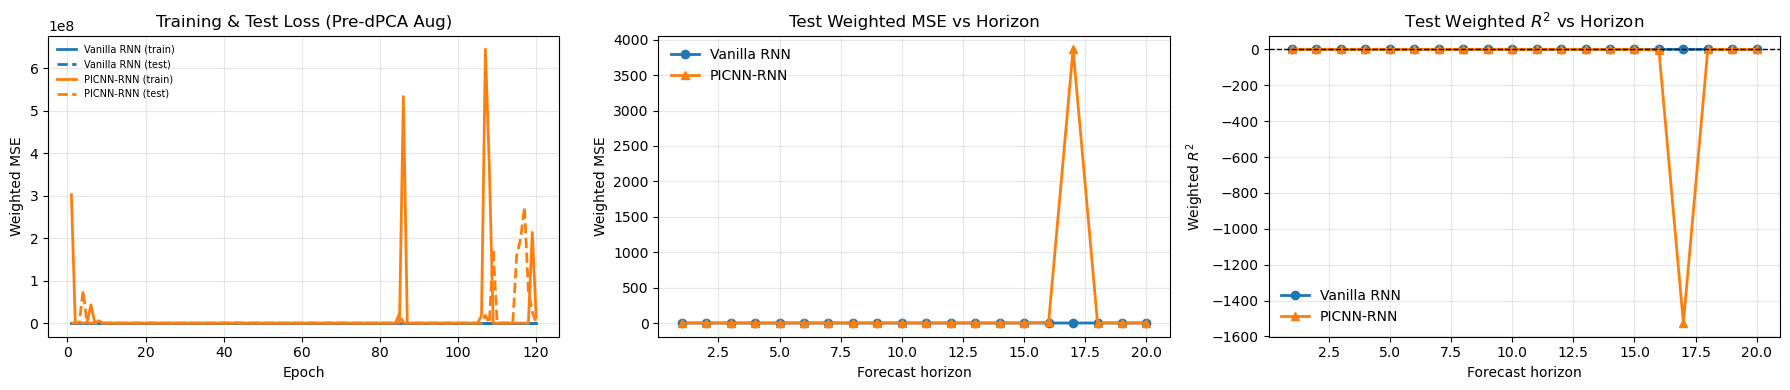

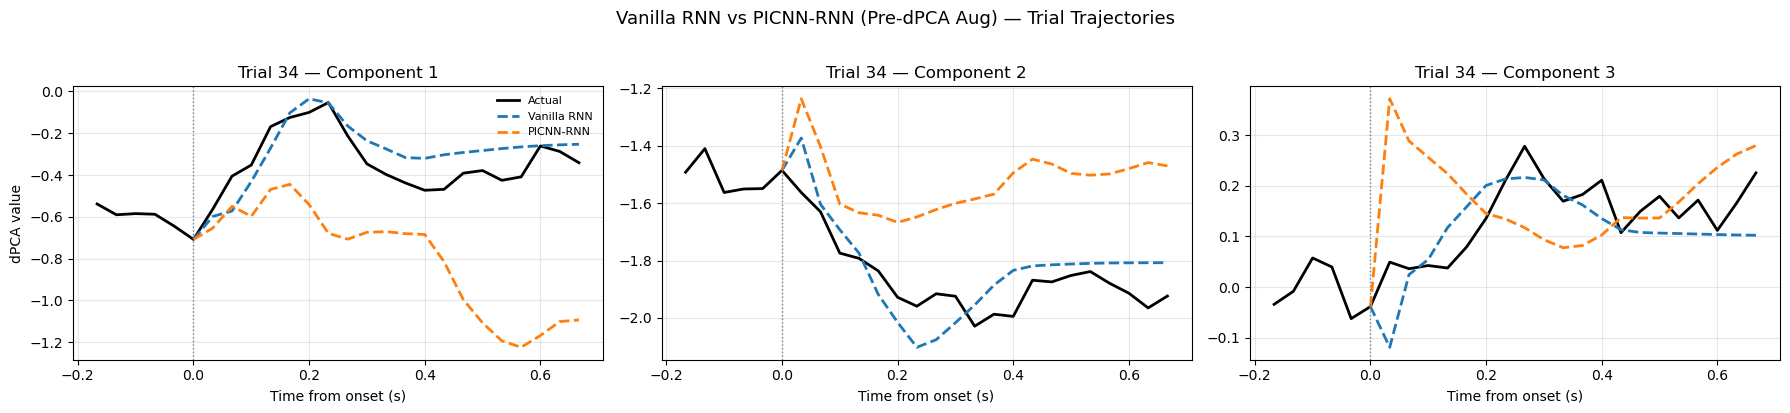

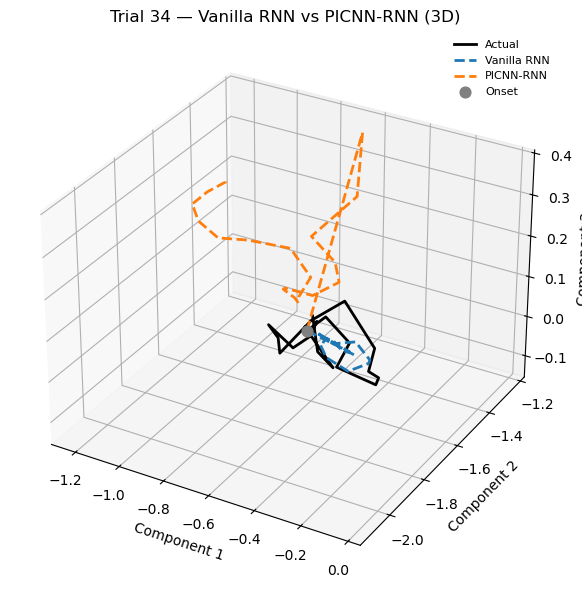

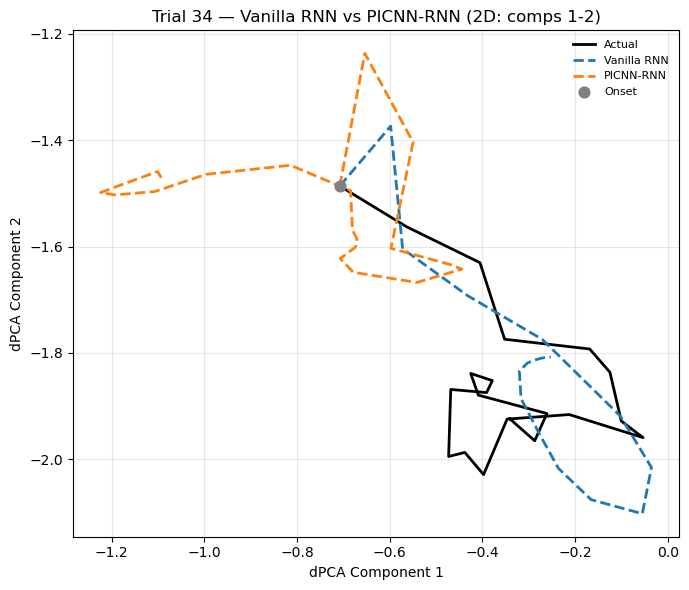


PICNN-RNN vs VANILLA RNN SUMMARY  (both pre-dPCA augmented)
PICNN-RNN params: 870,028  |  Vanilla RNN params: 659,486

Training time:
  Vanilla RNN: 66.90s (0.5575 s/epoch)
  PICNN-RNN:   115.65s (0.9637 s/epoch)

Inference time:
  Vanilla RNN: 0.002549s
  PICNN-RNN:   0.004948s

Weighted Metrics Comparison (all 20 horizons):
   h     RNN MSE  PICNN MSE      RNN R²   PICNN R²
t+01     0.17320    1.12779     0.85891    0.30584
t+02     0.25769    0.75072     0.83675    0.43032
t+03     0.28508    0.67788     0.82685    0.47699
t+04     0.30492    0.73227     0.81638    0.48474
t+05     0.30492    0.72182     0.80488    0.49611
t+06     0.30841    0.79024     0.79736    0.49282
t+07     0.33396    0.84386     0.79113    0.48533
t+08     0.36103    0.88114     0.77669    0.47976
t+09     0.37856    0.88350     0.77618    0.48925
t+10     0.41341    0.87551     0.77255    0.48604
t+11     0.41376    0.87495     0.76979    0.47095
t+12     0.43695    0.91564     0.76425    0.46025
t+13    

In [11]:
# =============================================================================
# Partially Input Convex RNN (PICNN-RNN) — Pre-dPCA Augmented (Fixed)
# =============================================================================
# Fixes over the original broken implementation:
#   1. Unconstrained W_in for v_k at every convex layer (not just layer 0)
#   2. Direct skip connection W_direct(v_k) to output for expressivity
#   3. Feed back z_base (not pred_z) to RNN cells → multi-step convexity

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# ---------------------------------------------------------------
# 1) PICNN-RNN Model (Corrected)
# ---------------------------------------------------------------

class PICRNNStimForecast(nn.Module):
    """
    Partially Input Convex RNN for stimulation forecasting.

    Convex in v (stimulation), non-convex in z (latent) and h (hidden).

    Key design choices (per Amos, Xu & Kolter 2017):
      - Only hidden-to-hidden weights in convex path are non-negative
      - Weights from v_k into every layer are UNCONSTRAINED
      - Direct skip connection from v_k to output (affine = convex)
      - Autoregressive feedback uses z_base only (no v contribution)
        → guarantees convexity at ALL horizon steps, not just step 1
    """

    def __init__(self, latent_dim, stim_dim, hidden_dim=256, num_layers=2,
                 n_convex_layers=3, convex_hidden=128, dropout=0.1):
        super().__init__()
        self.latent_dim = latent_dim
        self.stim_dim = stim_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.n_convex_layers = n_convex_layers

        # --- Encoder: standard RNN (no convexity constraints) ---
        self.encoder = nn.RNN(
            input_size=latent_dim + stim_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity='tanh',
            dropout=0.0,
        )

        # --- Decoder non-convex pathway: RNNCell stack ---
        # Input is z_base only (NOT [z, v]) to keep h independent of v_k
        self.dec_cells = nn.ModuleList()
        self.dec_cells.append(nn.RNNCell(latent_dim, hidden_dim, nonlinearity='tanh'))
        for _ in range(1, num_layers):
            self.dec_cells.append(nn.RNNCell(hidden_dim, hidden_dim, nonlinearity='tanh'))
        self.dropout_layer = nn.Dropout(dropout)

        # --- Decoder convex pathway (CORRECTED per Amos et al. 2017) ---
        # W_in: UNCONSTRAINED weights from v_k at every layer
        # W_pos_raw: non-negative passthrough (hidden-to-hidden) for ell >= 1
        # W_ctx: unconstrained context projection from h
        self.W_in = nn.ModuleList()          # unconstrained v_k -> layer
        self.W_pos_raw = nn.ParameterList()  # raw params -> softplus -> W_pos >= 0
        self.W_ctx = nn.ModuleList()         # unconstrained h -> layer
        self.b_convex = nn.ParameterList()   # biases

        # Layer 0: input -> first hidden (no passthrough, just W_in)
        self.W_in.append(nn.Linear(stim_dim, convex_hidden))
        self.W_ctx.append(nn.Linear(hidden_dim, convex_hidden))
        self.b_convex.append(nn.Parameter(torch.zeros(convex_hidden)))

        # Layers 1..L_v-1: passthrough (non-neg) + input injection (unconstrained)
        for ell in range(1, n_convex_layers):
            self.W_pos_raw.append(
                nn.Parameter(torch.randn(convex_hidden, convex_hidden) * 0.01)
            )
            self.W_in.append(nn.Linear(stim_dim, convex_hidden))
            self.W_ctx.append(nn.Linear(hidden_dim, convex_hidden))
            self.b_convex.append(nn.Parameter(torch.zeros(convex_hidden)))

        # --- Readout ---
        self.W_o = nn.Linear(hidden_dim, latent_dim)       # non-convex baseline
        self.W_ov_raw = nn.Parameter(                       # non-neg output weights
            torch.randn(latent_dim, convex_hidden) * 0.01
        )
        self.b_ov = nn.Parameter(torch.zeros(latent_dim))

        # CRUCIAL: unconstrained direct skip connection v_k -> z_hat
        self.W_direct = nn.Linear(stim_dim, latent_dim)

    def _pos(self, W_raw):
        """Non-negative weight via softplus reparametrisation."""
        return F.softplus(W_raw)

    def forward(self, context_z, context_v, future_v, target_z=None, teacher_forcing=0.0):
        B = context_z.shape[0]

        # --- Encode context (z and v together, unconstrained) ---
        enc_in = torch.cat([context_z, context_v], dim=-1)
        _, h_n = self.encoder(enc_in)  # h_n: (num_layers, B, hidden_dim)

        # Feed back the BASELINE state (without convex v contribution)
        # to keep the hidden-state trajectory independent of v
        prev_z_base = context_z[:, -1, :]
        preds = []
        H = future_v.shape[1]

        for k in range(H):
            v_k = future_v[:, k, :]     # (B, stim_dim)

            # (A) Non-convex pathway: update hidden state from z_base only
            h_in = prev_z_base
            h_new = []
            for layer_idx, cell in enumerate(self.dec_cells):
                h_l = cell(h_in, h_n[layer_idx])
                h_l = self.dropout_layer(h_l)
                h_new.append(h_l)
                h_in = h_l
            h_n = torch.stack(h_new, dim=0)
            h_top = h_n[-1]             # (B, hidden_dim)

            # (B) Convex pathway (proper ICNN: unconstrained v_k at every layer)
            # Layer 0: unconstrained input mapping
            y = F.relu(
                self.W_in[0](v_k) + self.W_ctx[0](h_top) + self.b_convex[0]
            )

            # Layers 1..L_v-1: non-neg passthrough + unconstrained v_k injection
            for ell in range(1, self.n_convex_layers):
                W_pos = self._pos(self.W_pos_raw[ell - 1])  # non-neg hidden-to-hidden
                y = F.relu(
                    F.linear(y, W_pos) +             # non-negative passthrough
                    self.W_in[ell](v_k) +            # unconstrained v_k injection
                    self.W_ctx[ell](h_top) +         # unconstrained context
                    self.b_convex[ell]
                )

            # (C) Readout: baseline + convex contribution + direct skip
            z_base = self.W_o(h_top)
            W_ov_pos = self._pos(self.W_ov_raw)
            convex_contrib = F.linear(y, W_ov_pos, self.b_ov) + self.W_direct(v_k)

            pred_z = z_base + convex_contrib
            preds.append(pred_z.unsqueeze(1))

            # Autoregressive update: feed back z_base (NOT pred_z)
            # This keeps the RNN hidden state independent of v at ALL steps
            if self.training and target_z is not None and teacher_forcing > 0.0:
                mask = (torch.rand(B, device=pred_z.device) < teacher_forcing).float().unsqueeze(-1)
                prev_z_base = mask * target_z[:, k, :] + (1.0 - mask) * z_base
            else:
                prev_z_base = z_base

        return torch.cat(preds, dim=1)  # (B, H, latent_dim)


# ---------------------------------------------------------------
# 2) Reuse pre-dPCA augmented data from cell 14
# ---------------------------------------------------------------

print(f"PICNN-RNN (fixed): d_z={d_z_rnn}, stim_dim={n_cells_rnn}, "
      f"hidden=256, convex_layers=3, convex_hidden=128")
print(f"Pre-dPCA augmented training set: {len(predpca_train_ds_rnn)} samples")

# ---------------------------------------------------------------
# 3) Train PICNN-RNN
# ---------------------------------------------------------------

model_picnn = PICRNNStimForecast(
    latent_dim=d_z_rnn, stim_dim=n_cells_rnn,
    hidden_dim=256, num_layers=2,
    n_convex_layers=3, convex_hidden=128,
    dropout=0.1,
).to(device)

n_params_picnn = sum(p.numel() for p in model_picnn.parameters() if p.requires_grad)
n_params_rnn = sum(p.numel() for p in model_rnn_preaug.parameters() if p.requires_grad)
print(f"PICNN-RNN params: {n_params_picnn:,}  |  Vanilla RNN params: {n_params_rnn:,}")

optimizer_picnn = torch.optim.Adam(model_picnn.parameters(), lr=1e-3, weight_decay=1e-5)
n_epochs_picnn = 120
loss_history_picnn = []
test_loss_history_picnn = []

train_t0_picnn = time.perf_counter()
for epoch in range(1, n_epochs_picnn + 1):
    model_picnn.train()
    running_loss = 0.0
    tf_ratio = 0.7 + (0.1 - 0.7) * ((epoch - 1) / max(n_epochs_picnn - 1, 1))

    for cz_b, cv_b, fv_b, tz_b in predpca_train_loader_rnn:
        cz_b = cz_b.to(device); cv_b = cv_b.to(device)
        fv_b = fv_b.to(device); tz_b = tz_b.to(device)

        optimizer_picnn.zero_grad()
        pred_b = model_picnn(cz_b, cv_b, fv_b, target_z=tz_b, teacher_forcing=tf_ratio)
        loss = weighted_mse_loss_rnn(pred_b, tz_b, component_weights_t_rnn)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_picnn.parameters(), 1.0)
        optimizer_picnn.step()
        running_loss += loss.item() * cz_b.shape[0]

    epoch_loss = running_loss / len(predpca_train_ds_rnn)
    loss_history_picnn.append(epoch_loss)

    # Compute test loss (open-loop, no teacher forcing)
    model_picnn.eval()
    with torch.no_grad():
        test_running = 0.0
        for cz_b, cv_b, fv_b, tz_b in test_loader_rnn:
            cz_b = cz_b.to(device); cv_b = cv_b.to(device)
            fv_b = fv_b.to(device); tz_b = tz_b.to(device)
            pred_b = model_picnn(cz_b, cv_b, fv_b, target_z=None, teacher_forcing=0.0)
            test_running += weighted_mse_loss_rnn(pred_b, tz_b, component_weights_t_rnn).item() * cz_b.shape[0]
        test_loss_history_picnn.append(test_running / len(test_ds_rnn))

    if epoch % 20 == 0 or epoch == 1:
        print(f"[PICNN] Epoch {epoch:03d}/{n_epochs_picnn} | loss={epoch_loss:.6f} | test_loss={test_loss_history_picnn[-1]:.6f} | tf={tf_ratio:.3f}")

training_time_picnn = time.perf_counter() - train_t0_picnn

# ---------------------------------------------------------------
# 4) Evaluate on clean test set
# ---------------------------------------------------------------

wmse_picnn, wr2_picnn, inf_time_picnn = eval_vanilla_rnn(model_picnn, test_loader_rnn)

# ---------------------------------------------------------------
# 5) Empirical convexity verification (Jensen inequality — ALL steps)
# ---------------------------------------------------------------

print("\n" + "=" * 60)
print("EMPIRICAL CONVEXITY VERIFICATION (ALL HORIZON STEPS)")
print("=" * 60)

model_picnn.eval()
n_checks = 200
violations_per_step = np.zeros(horizon_rnn, dtype=int)
max_violation_per_step = np.zeros(horizon_rnn)

# Use a fixed context from trial 34
cz_single = torch.from_numpy(z_trial_n_rnn[34, :context_len_rnn, :]).unsqueeze(0).to(device)
cv_single = torch.from_numpy(v_rnn[34, :context_len_rnn, :]).unsqueeze(0).to(device)

with torch.no_grad():
    for _ in range(n_checks):
        # Sample two random stimulation sequences
        v1 = torch.rand(1, horizon_rnn, n_cells_rnn, device=device)
        v2 = torch.rand(1, horizon_rnn, n_cells_rnn, device=device)
        lam = torch.rand(1, device=device).item()

        v_mix = lam * v1 + (1 - lam) * v2

        # f(lambda*v1 + (1-lambda)*v2)
        pred_mix = model_picnn(cz_single, cv_single, v_mix, target_z=None, teacher_forcing=0.0)
        # lambda*f(v1) + (1-lambda)*f(v2)
        pred_v1 = model_picnn(cz_single, cv_single, v1, target_z=None, teacher_forcing=0.0)
        pred_v2 = model_picnn(cz_single, cv_single, v2, target_z=None, teacher_forcing=0.0)
        convex_comb = lam * pred_v1 + (1 - lam) * pred_v2

        # Check at EVERY horizon step: f(v_mix)_k <= lam*f(v1)_k + (1-lam)*f(v2)_k
        for step_k in range(horizon_rnn):
            diff_k = (pred_mix[:, step_k, :] - convex_comb[:, step_k, :]).max().item()
            if diff_k > 1e-5:
                violations_per_step[step_k] += 1
            max_violation_per_step[step_k] = max(max_violation_per_step[step_k], diff_k)

total_violations = int(violations_per_step.sum())
print(f"Jensen inequality checks: {n_checks} pairs × {horizon_rnn} steps = {n_checks * horizon_rnn} total")
print(f"Total violations (tolerance 1e-5): {total_violations}/{n_checks * horizon_rnn}")
print(f"\nPer-step breakdown:")
print(f"{'Step':>6s}  {'Violations':>10s}  {'Max Violation':>14s}")
for step_k in range(horizon_rnn):
    flag = " ⚠" if violations_per_step[step_k] > 0 else " ✓"
    print(f"  k={step_k+1:02d}  {violations_per_step[step_k]:>10d}  {max_violation_per_step[step_k]:>14.2e}{flag}")

if total_violations == 0:
    print("\n✓ Convexity in v verified at ALL horizon steps!")
else:
    print(f"\n⚠ {total_violations} violations detected — likely numerical precision; check magnitudes.")

# ---------------------------------------------------------------
# 6) Comparison plots: Vanilla RNN vs PICNN-RNN (both pre-dPCA aug)
# ---------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Training curves (with test loss)
axes[0].plot(np.arange(1, n_epochs_rnn + 1), loss_hist_rnn_preaug, lw=2, color='tab:blue', label='Vanilla RNN (train)')
axes[0].plot(np.arange(1, n_epochs_rnn + 1), test_loss_hist_rnn_preaug, lw=2, ls='--', color='tab:blue', label='Vanilla RNN (test)')
axes[0].plot(np.arange(1, n_epochs_picnn + 1), loss_history_picnn, lw=2, color='tab:orange', label='PICNN-RNN (train)')
axes[0].plot(np.arange(1, n_epochs_picnn + 1), test_loss_history_picnn, lw=2, ls='--', color='tab:orange', label='PICNN-RNN (test)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Weighted MSE')
axes[0].set_title('Training & Test Loss (Pre-dPCA Aug)')
axes[0].legend(frameon=False, fontsize=7); axes[0].grid(alpha=0.3)

# Weighted MSE vs horizon
axes[1].plot(horizons_rnn, wmse_rnn_preaug, marker='o', lw=2, label='Vanilla RNN')
axes[1].plot(horizons_rnn, wmse_picnn, marker='^', lw=2, label='PICNN-RNN')
axes[1].set_xlabel('Forecast horizon'); axes[1].set_ylabel('Weighted MSE')
axes[1].set_title('Test Weighted MSE vs Horizon')
axes[1].legend(frameon=False); axes[1].grid(alpha=0.3)

# Weighted R² vs horizon
axes[2].plot(horizons_rnn, wr2_rnn_preaug, marker='o', lw=2, label='Vanilla RNN')
axes[2].plot(horizons_rnn, wr2_picnn, marker='^', lw=2, label='PICNN-RNN')
axes[2].axhline(0.0, color='k', ls='--', lw=1)
axes[2].set_xlabel('Forecast horizon'); axes[2].set_ylabel('Weighted $R^2$')
axes[2].set_title('Test Weighted $R^2$ vs Horizon')
axes[2].legend(frameon=False); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# ---------------------------------------------------------------
# 7) Trial 34 — trajectory comparison
# ---------------------------------------------------------------

trial_id_pic = 34
pre_steps_pic = 5

cz_s = torch.from_numpy(z_trial_n_rnn[trial_id_pic, :context_len_rnn, :]).unsqueeze(0).to(device)
cv_s = torch.from_numpy(v_rnn[trial_id_pic, :context_len_rnn, :]).unsqueeze(0).to(device)
fv_s = torch.from_numpy(v_rnn[trial_id_pic, zero_idx + 1:zero_idx + 1 + horizon_rnn, :]).unsqueeze(0).to(device)

with torch.no_grad():
    pred_rnn_n  = model_rnn_preaug(cz_s, cv_s, fv_s, target_z=None, teacher_forcing=0.0)
    pred_picnn_n = model_picnn(cz_s, cv_s, fv_s, target_z=None, teacher_forcing=0.0)

pred_rnn_dn  = pred_rnn_n.squeeze(0).cpu().numpy() * z_std_rnn.squeeze((0, 1)) + z_mean_rnn.squeeze((0, 1))
pred_picnn_dn = pred_picnn_n.squeeze(0).cpu().numpy() * z_std_rnn.squeeze((0, 1)) + z_mean_rnn.squeeze((0, 1))

start_pic = zero_idx - pre_steps_pic
end_pic   = zero_idx + 1 + horizon_rnn
t_window_pic = time_axis[start_pic:end_pic]
true_window_pic = z_trial_rnn[trial_id_pic, start_pic:end_pic, :]

def _build_pw_pic(pred, dz, pre, h):
    w = np.full((pre + 1 + h, dz), np.nan, dtype=np.float32)
    w[pre, :] = true_window_pic[pre, :]   # onset point
    w[pre + 1:, :] = pred
    return w

pw_rnn_pic  = _build_pw_pic(pred_rnn_dn, d_z_rnn, pre_steps_pic, horizon_rnn)
pw_picnn    = _build_pw_pic(pred_picnn_dn, d_z_rnn, pre_steps_pic, horizon_rnn)

# 2D component plots
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
for comp in range(3):
    axes[comp].plot(t_window_pic, true_window_pic[:, comp], lw=2, label='Actual', color='black')
    axes[comp].plot(t_window_pic, pw_rnn_pic[:, comp], lw=2, ls='--', label='Vanilla RNN', color='tab:blue')
    axes[comp].plot(t_window_pic, pw_picnn[:, comp], lw=2, ls='--', label='PICNN-RNN', color='tab:orange')
    axes[comp].axvline(0.0, color='gray', ls=':', lw=1)
    axes[comp].set_title(f'Trial {trial_id_pic} — Component {comp + 1}')
    axes[comp].set_xlabel('Time from onset (s)')
    axes[comp].grid(alpha=0.3)
axes[0].set_ylabel('dPCA value')
axes[0].legend(frameon=False, fontsize=8)
plt.suptitle('Vanilla RNN vs PICNN-RNN (Pre-dPCA Aug) — Trial Trajectories', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

# 3D comparison
onset_pic = z_trial_rnn[trial_id_pic, zero_idx, :]
true_post_pic = z_trial_rnn[trial_id_pic, zero_idx + 1:zero_idx + 1 + horizon_rnn, :]
true_from_onset_pic = np.vstack([onset_pic[None, :], true_post_pic])
rnn_from_onset_pic  = np.vstack([onset_pic[None, :], pred_rnn_dn])
picnn_from_onset    = np.vstack([onset_pic[None, :], pred_picnn_dn])

fig = plt.figure(figsize=(7, 6))
ax3 = fig.add_subplot(111, projection='3d')
ax3.plot(true_from_onset_pic[:, 0], true_from_onset_pic[:, 1], true_from_onset_pic[:, 2],
         color='black', lw=2, label='Actual')
ax3.plot(rnn_from_onset_pic[:, 0], rnn_from_onset_pic[:, 1], rnn_from_onset_pic[:, 2],
         color='tab:blue', lw=2, ls='--', label='Vanilla RNN')
ax3.plot(picnn_from_onset[:, 0], picnn_from_onset[:, 1], picnn_from_onset[:, 2],
         color='tab:orange', lw=2, ls='--', label='PICNN-RNN')
ax3.scatter(onset_pic[0], onset_pic[1], onset_pic[2], color='gray', s=60, zorder=5, label='Onset')
ax3.set_title(f'Trial {trial_id_pic} — Vanilla RNN vs PICNN-RNN (3D)')
ax3.set_xlabel('Component 1'); ax3.set_ylabel('Component 2'); ax3.set_zlabel('Component 3')
ax3.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

# 2D trajectory (comps 1 & 2)
fig, ax2 = plt.subplots(figsize=(7, 6))
ax2.plot(true_from_onset_pic[:, 0], true_from_onset_pic[:, 1], color='black', lw=2, label='Actual')
ax2.plot(rnn_from_onset_pic[:, 0], rnn_from_onset_pic[:, 1], color='tab:blue', lw=2, ls='--', label='Vanilla RNN')
ax2.plot(picnn_from_onset[:, 0], picnn_from_onset[:, 1], color='tab:orange', lw=2, ls='--', label='PICNN-RNN')
ax2.scatter(onset_pic[0], onset_pic[1], color='gray', s=60, zorder=5, label='Onset')
ax2.set_title(f'Trial {trial_id_pic} — Vanilla RNN vs PICNN-RNN (2D: comps 1-2)')
ax2.set_xlabel('dPCA Component 1'); ax2.set_ylabel('dPCA Component 2')
ax2.legend(frameon=False, fontsize=8); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---------------------------------------------------------------
# 8) Summary
# ---------------------------------------------------------------

print("\n" + "=" * 70)
print("PICNN-RNN vs VANILLA RNN SUMMARY  (both pre-dPCA augmented)")
print("=" * 70)
print(f"PICNN-RNN params: {n_params_picnn:,}  |  Vanilla RNN params: {n_params_rnn:,}")
print(f"\nTraining time:")
print(f"  Vanilla RNN: {train_time_rnn_preaug:.2f}s ({train_time_rnn_preaug / n_epochs_rnn:.4f} s/epoch)")
print(f"  PICNN-RNN:   {training_time_picnn:.2f}s ({training_time_picnn / n_epochs_picnn:.4f} s/epoch)")
print(f"\nInference time:")
print(f"  Vanilla RNN: {inf_time_rnn_preaug:.6f}s")
print(f"  PICNN-RNN:   {inf_time_picnn:.6f}s")

print(f"\nWeighted Metrics Comparison (all {horizon_rnn} horizons):")
print(f"{'h':>4s}  {'RNN MSE':>10s} {'PICNN MSE':>10s}  {'RNN R²':>10s} {'PICNN R²':>10s}")
for h in range(horizon_rnn):
    print(f"t+{h+1:02d}  {wmse_rnn_preaug[h]:10.5f} {wmse_picnn[h]:10.5f}  "
          f"{wr2_rnn_preaug[h]:10.5f} {wr2_picnn[h]:10.5f}")

# Average R² across all horizons
avg_r2_rnn = np.mean(wr2_rnn_preaug)
avg_r2_picnn = np.mean(wr2_picnn)
print(f"\nAverage weighted R² across all horizons:")
print(f"  Vanilla RNN: {avg_r2_rnn:.5f}")
print(f"  PICNN-RNN:   {avg_r2_picnn:.5f}")
print(f"  Δ = {avg_r2_picnn - avg_r2_rnn:+.5f}")
if avg_r2_picnn >= avg_r2_rnn - 0.01:
    print("\n→ PICNN-RNN achieves competitive accuracy while providing convexity in v for MPC.")
else:
    print("\n→ Convexity constraint reduces accuracy. Consider increasing convex_hidden or n_convex_layers.")

## Multi-Session GRU (sessions 0–8)

**Goal**: Train the same GRU architecture (2 layers, 256 hidden) on pooled data from sessions 0–8 to test whether more data from different subjects/sessions improves forecasting on session 0.

**Approach**:
- Fit a **separate dPCA per session** (neurons differ: 300–919 across sessions) → each session gets a 30-d latent representation (same dimensionality, different axes).
- Normalise each session's latents (zero-mean, unit-variance from that session's training split).
- Reduce the stimulation input to a **1-D scalar** (fraction of targeted neurons per timestep) for cross-session compatibility.
- **80/20 random split per session** (same `random_state=42`), then pool all sessions' training trials.
- **Evaluate exclusively on session 0's test set** → directly comparable to the single-session baseline.

Device: cuda
Zero indices per session: {0: 237, 1: 238, 2: 238, 3: 238, 4: 238, 5: 238, 6: 238, 7: 238, 8: 238}
Common context length (min): 238
You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set by changing self.n_trials (default = 3). Similarly,
                    use self.protect to set the list of axes that are not supposed to get to get shuffled
                    (e.g. upon splitting the data into test- and training, time-points should always
                    be drawn from the same trial, i.e. self.protect = ['t']). This can significantly
                    speed up the code.
Start optimizing regularization.
Starting trial  1 / 3
Starting trial  2 / 3
Starting trial  3 / 3
Optimized regularization, optimal lambda =  0.0008819763977946266
Regularization will be fixed; to compute the optimal                  

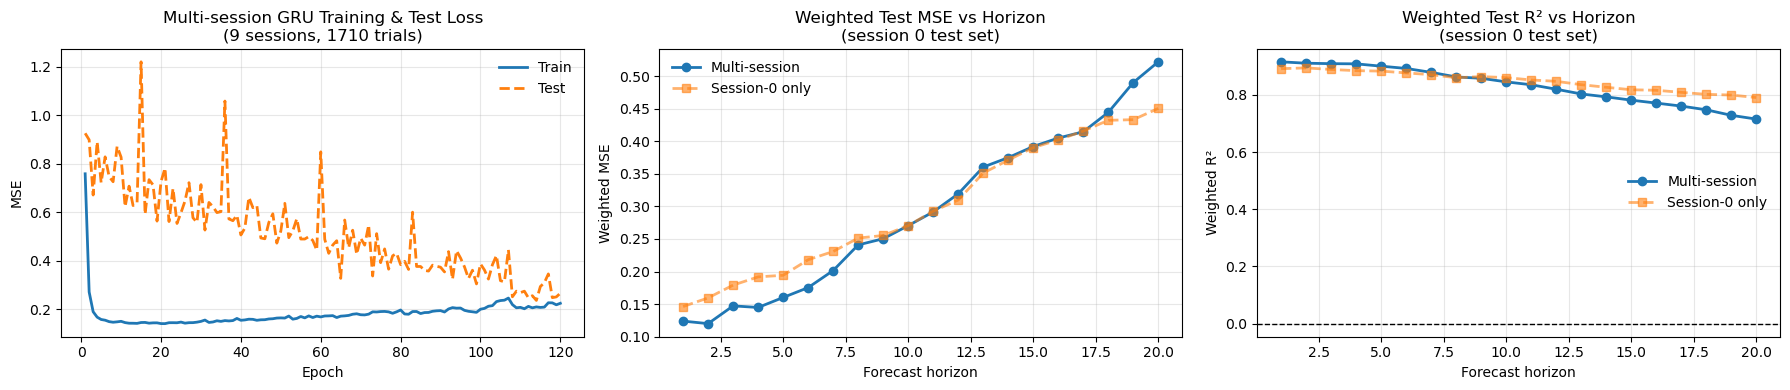

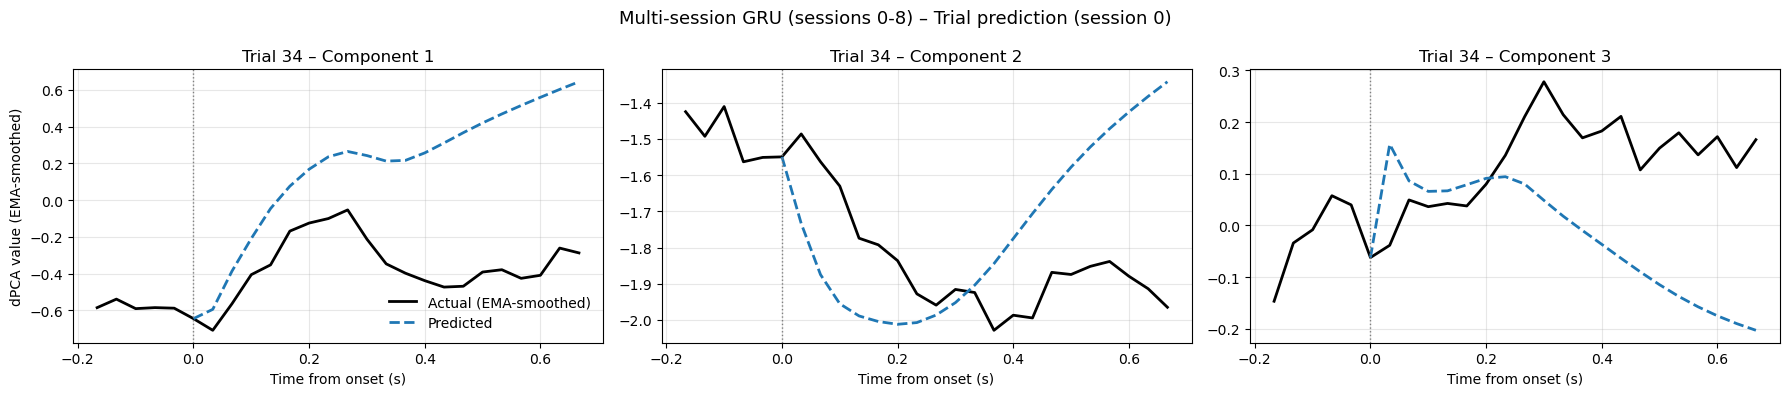

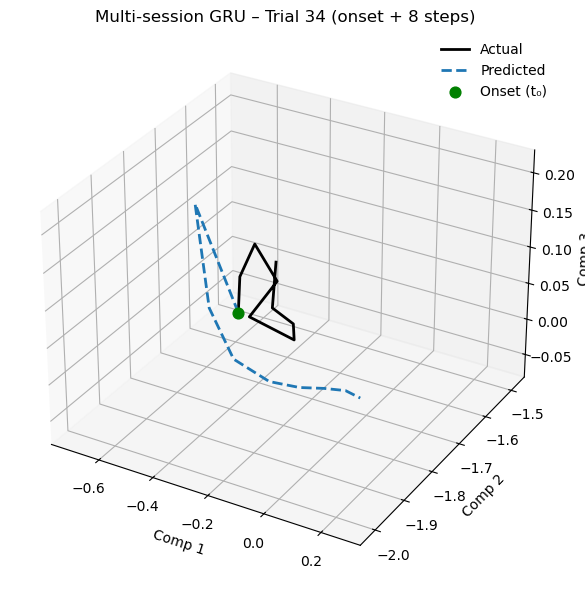


MULTI-SESSION GRU SUMMARY
Sessions       : [0, 1, 2, 3, 4, 5, 6, 7, 8]
Pooled train   : 1710 trials
Session-0 test : 33 trials
Architecture   : GRU 2-layer, hidden=256, stim_dim=1 (stim fraction)
Training time  : 106.75s (0.8896 s/epoch)
Inference time : 0.004577s

Weighted horizon metrics on session-0 test set (first 5):
         Multi-sess wR²   Baseline wR²
  t+01:          0.91589        0.89193
  t+02:          0.91103        0.89464
  t+03:          0.90947        0.88911
  t+04:          0.90882        0.88497
  t+05:          0.90069        0.88341


In [15]:
# ===================================================================
# Multi-Session GRU (sessions 0-8): 2 layers, 256 hidden
# ===================================================================

import time, builtins
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from dPCA import dPCA as dPCA_cls
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

SESSION_IDS_MS = list(range(9))
HORIZON_MS     = 20
N_COMP_MS      = 10
HIDDEN_DIM_MS  = 256
NUM_LAYERS_MS  = 2
EPOCHS_MS      = 120
BATCH_SIZE_MS  = 32
LR_MS          = 1e-3
STIM_DIM_MS    = 1          # stim fraction (cross-session compatible)
TRIAL_ID_MS    = 34         # evaluation trial (session 0 test set)
H3D_MS         = 8          # 3D plot: onset + 8 post-onset steps

device_ms = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device_ms}")

# ------------------------------------------------------------------
# 1) Compute common context length across sessions
# ------------------------------------------------------------------
zero_indices = {}
for sid in SESSION_IDS_MS:
    taxis_tmp = sessions[sid]['filter_ps_time'].copy()
    dt_tmp = taxis_tmp[1] - taxis_tmp[0]
    taxis_tmp = taxis_tmp + dt_tmp
    zero_indices[sid] = int(np.argmin(np.abs(taxis_tmp)))

# Use minimum context length so all sessions produce equally-sized tensors
COMMON_CTX = builtins.min(z + 1 for z in zero_indices.values())
print(f"Zero indices per session: {zero_indices}")
print(f"Common context length (min): {COMMON_CTX}")

# ------------------------------------------------------------------
# 2) Per-session processing → pooled training data
# ------------------------------------------------------------------
pool_cz, pool_cv, pool_fv, pool_tz = [], [], [], []     # training
s0te_cz, s0te_cv, s0te_fv, s0te_tz = [], [], [], []     # session-0 test

# Session-0 bookkeeping for evaluation / plotting
s0_zm = s0_zs = s0_cw = None
s0_ztrial = s0_sfrac = None
s0_zero = s0_taxis = s0_teidx = None

total_train = 0

for sid in SESSION_IDS_MS:
    sess = sessions[sid]

    # Timing correction (same as baseline)
    taxis = sess['filter_ps_time'].copy()
    dt_s = taxis[1] - taxis[0]
    taxis = taxis + dt_s
    zero_s = zero_indices[sid]

    neural = sess['behaviour_trials']          # (N, n_trials, T)
    ts     = sess['trial_subsets']
    nt     = sess['n_trials']
    N_s    = sess['n_cells']
    T_s    = sess['n_times']

    # 80/20 split (same strategy & random_state)
    tr_idx, te_idx = train_test_split(
        np.arange(nt), test_size=0.2, random_state=42, shuffle=True)
    tr_idx, te_idx = np.sort(tr_idx), np.sort(te_idx)

    # ---- dPCA on training trials (per-session) ----
    uconds = np.unique(ts)
    tpc    = {c: np.intersect1d(np.where(ts == c)[0], tr_idx) for c in uconds}
    min_t  = builtins.min(len(v_) for v_ in tpc.values())
    S_s    = len(uconds)
    rng_s  = np.random.default_rng(42)

    trialR_s = np.zeros((min_t, N_s, S_s, T_s))
    for si, cond in enumerate(uconds):
        sel = rng_s.choice(tpc[cond], size=min_t, replace=False)
        for i, tidx in enumerate(sel):
            trialR_s[i, :, si, :] = neural[:, tidx, :]

    R_s   = trialR_s.mean(axis=0)
    R_s_c = R_s - R_s.reshape(N_s, -1).mean(1)[:, None, None]

    dpca_s = dPCA_cls.dPCA(labels='st', regularizer='auto', n_components=N_COMP_MS)
    dpca_s.protect = ['t']
    dpca_s.fit_transform(R_s_c, trialR_s)

    # Project all trials
    sm  = R_s.reshape(N_s, -1).mean(1)[:, None, None]
    za  = dpca_s.transform(neural - sm)
    zt  = np.concatenate([za['s'], za['t'], za['st']], axis=0)   # (d_z, ntr, T)
    zt  = np.transpose(zt, (1, 2, 0)).astype(np.float32)        # (ntr, T, d_z)

    # Apply EMA smoothing to dPCA trajectories
    zt  = apply_ema(zt, alpha=EMA_ALPHA)

    d_z_s = zt.shape[-1]

    # Stim fraction per timestep: sum(is_target[:, trial, t]) / n_cells → (ntr, T, 1)
    sfrac = (sess['is_target'].sum(axis=0) / max(N_s, 1)).astype(np.float32)[:, :, None]

    # Normalise latents from training split
    zm = zt[tr_idx].mean(axis=(0, 1), keepdims=True)
    zs = zt[tr_idx].std(axis=(0, 1), keepdims=True) + 1e-6
    zt_n = (zt - zm) / zs

    # Use COMMON_CTX to ensure all contexts have the same length
    # Take the last COMMON_CTX timesteps up to and including onset
    ctx_start = zero_s + 1 - COMMON_CTX  # where to start slicing context

    # ---- Build tuples for training ----
    for tidx in tr_idx:
        tg = zt_n[tidx, zero_s + 1 : zero_s + 1 + HORIZON_MS, :]
        if tg.shape[0] == HORIZON_MS:
            pool_cz.append(zt_n[tidx, ctx_start : zero_s + 1, :])
            pool_cv.append(sfrac[tidx, ctx_start : zero_s + 1, :])
            pool_fv.append(sfrac[tidx, zero_s + 1 : zero_s + 1 + HORIZON_MS, :])
            pool_tz.append(tg)

    # ---- Session 0: test data + metadata for evaluation ----
    if sid == 0:
        s0_zm, s0_zs = zm, zs
        cvar = zt[tr_idx].var(axis=(0, 1))
        s0_cw = cvar / (cvar.sum() + 1e-12)
        s0_ztrial, s0_sfrac = zt, sfrac
        s0_zero, s0_taxis = zero_s, taxis
        s0_teidx = te_idx

        for tidx in te_idx:
            tg = zt_n[tidx, zero_s + 1 : zero_s + 1 + HORIZON_MS, :]
            if tg.shape[0] == HORIZON_MS:
                s0te_cz.append(zt_n[tidx, ctx_start : zero_s + 1, :])
                s0te_cv.append(sfrac[tidx, ctx_start : zero_s + 1, :])
                s0te_fv.append(sfrac[tidx, zero_s + 1 : zero_s + 1 + HORIZON_MS, :])
                s0te_tz.append(tg)

    total_train += len(tr_idx)
    print(f"Sess {sid} ({sess['mouse']:>5s}): {len(tr_idx):>3d} train, "
          f"{len(te_idx):>3d} test, N={N_s:>3d}, d_z={d_z_s}, zero_idx={zero_s}")

print(f"\nPooled training samples : {len(pool_cz)} "
      f"(from {total_train} train trials across {len(SESSION_IDS_MS)} sessions)")
print(f"Session-0 test samples  : {len(s0te_cz)}")

# ------------------------------------------------------------------
# 2) Datasets
# ------------------------------------------------------------------

class PooledOnsetDataset(Dataset):
    def __init__(self, cz, cv, fv, tz):
        self.data = [(torch.from_numpy(a), torch.from_numpy(b),
                      torch.from_numpy(c), torch.from_numpy(d))
                     for a, b, c, d in zip(cz, cv, fv, tz)]
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

train_ds_ms = PooledOnsetDataset(pool_cz, pool_cv, pool_fv, pool_tz)
test_ds_ms  = PooledOnsetDataset(s0te_cz, s0te_cv, s0te_fv, s0te_tz)

train_loader_ms = DataLoader(train_ds_ms, batch_size=BATCH_SIZE_MS, shuffle=True)
test_loader_ms  = DataLoader(test_ds_ms,  batch_size=len(test_ds_ms), shuffle=False)

# ------------------------------------------------------------------
# 3) GRU model (same architecture; stim_dim=1 for cross-session input)
# ------------------------------------------------------------------

class GRUStimForecastMS(nn.Module):
    def __init__(self, latent_dim, stim_dim, hidden_dim=256, num_layers=2, dropout=0.0):
        super().__init__()
        self.encoder = nn.GRU(
            input_size=latent_dim + stim_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
        )
        self.num_layers = num_layers
        self.decoder_cells = nn.ModuleList()
        self.decoder_cells.append(nn.GRUCell(latent_dim + stim_dim, hidden_dim))
        for _ in range(1, num_layers):
            self.decoder_cells.append(nn.GRUCell(hidden_dim, hidden_dim))
        self.readout = nn.Linear(hidden_dim, latent_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, context_z, context_v, future_v, target_z=None, teacher_forcing=0.0):
        enc_in = torch.cat([context_z, context_v], dim=-1)
        _, h_n = self.encoder(enc_in)
        prev_z = context_z[:, -1, :]
        preds = []
        H = future_v.shape[1]
        for k in range(H):
            dec_in = torch.cat([prev_z, future_v[:, k, :]], dim=-1)
            h_in = dec_in
            h_new = []
            for li, cell in enumerate(self.decoder_cells):
                h_l = cell(h_in, h_n[li])
                h_l = self.dropout(h_l)
                h_new.append(h_l)
                h_in = h_l
            h_n = torch.stack(h_new, dim=0)
            pred_z = self.readout(h_n[-1])
            preds.append(pred_z.unsqueeze(1))
            if self.training and target_z is not None and teacher_forcing > 0:
                mask = (torch.rand(pred_z.shape[0], device=pred_z.device) < teacher_forcing).float().unsqueeze(-1)
                prev_z = mask * target_z[:, k, :] + (1 - mask) * pred_z
            else:
                prev_z = pred_z
        return torch.cat(preds, dim=1)

d_z_ms = pool_cz[0].shape[-1]
model_ms = GRUStimForecastMS(
    latent_dim=d_z_ms, stim_dim=STIM_DIM_MS,
    hidden_dim=HIDDEN_DIM_MS, num_layers=NUM_LAYERS_MS, dropout=0.1
).to(device_ms)

optimizer_ms  = torch.optim.Adam(model_ms.parameters(), lr=LR_MS, weight_decay=1e-5)
criterion_ms  = nn.MSELoss()

print(f"\nModel: GRU {NUM_LAYERS_MS}-layer, hidden={HIDDEN_DIM_MS}, "
      f"input=d_z({d_z_ms})+stim({STIM_DIM_MS})")
print(f"Trainable params: {sum(p.numel() for p in model_ms.parameters() if p.requires_grad):,}")

# ------------------------------------------------------------------
# 4) Train
# ------------------------------------------------------------------

loss_hist_ms = []
test_loss_hist_ms = []
t0_train = time.perf_counter()

for epoch in range(1, EPOCHS_MS + 1):
    model_ms.train()
    running = 0.0
    tf = 0.7 + (0.1 - 0.7) * ((epoch - 1) / max(EPOCHS_MS - 1, 1))

    for cz_b, cv_b, fv_b, tz_b in train_loader_ms:
        cz_b = cz_b.to(device_ms); cv_b = cv_b.to(device_ms)
        fv_b = fv_b.to(device_ms); tz_b = tz_b.to(device_ms)

        optimizer_ms.zero_grad()
        pred = model_ms(cz_b, cv_b, fv_b, target_z=tz_b, teacher_forcing=tf)
        loss = criterion_ms(pred, tz_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_ms.parameters(), 1.0)
        optimizer_ms.step()
        running += loss.item() * cz_b.shape[0]

    ep = running / len(train_ds_ms)
    loss_hist_ms.append(ep)

    # Compute test loss (session-0 test set, open-loop)
    model_ms.eval()
    with torch.no_grad():
        test_running = 0.0
        for cz_b, cv_b, fv_b, tz_b in test_loader_ms:
            cz_b = cz_b.to(device_ms); cv_b = cv_b.to(device_ms)
            fv_b = fv_b.to(device_ms); tz_b = tz_b.to(device_ms)
            pred = model_ms(cz_b, cv_b, fv_b, target_z=None, teacher_forcing=0.0)
            test_running += criterion_ms(pred, tz_b).item() * cz_b.shape[0]
        test_loss_hist_ms.append(test_running / len(test_ds_ms))

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d}/{EPOCHS_MS} | loss={ep:.6f} | test_loss={test_loss_hist_ms[-1]:.6f} | tf={tf:.3f}")

training_time_ms = time.perf_counter() - t0_train

# ------------------------------------------------------------------
# 5) Evaluate on session-0 test set (weighted horizon-wise metrics)
# ------------------------------------------------------------------

model_ms.eval()
with torch.no_grad():
    cz_t, cv_t, fv_t, tz_t = next(iter(test_loader_ms))
    cz_t = cz_t.to(device_ms); cv_t = cv_t.to(device_ms); fv_t = fv_t.to(device_ms)
    if device_ms.type == 'cuda': torch.cuda.synchronize()
    inf_t0 = time.perf_counter()
    pred_t = model_ms(cz_t, cv_t, fv_t, target_z=None, teacher_forcing=0.0)
    if device_ms.type == 'cuda': torch.cuda.synchronize()
    inference_time_ms = time.perf_counter() - inf_t0

pred_arr = pred_t.cpu().numpy()
targ_arr = tz_t.numpy()

# Denormalise using session-0 stats
pred_dn = pred_arr * s0_zs + s0_zm
targ_dn = targ_arr * s0_zs + s0_zm

horizons_ms = np.arange(1, HORIZON_MS + 1)
wmse_h, wr2_h = [], []

for h in range(HORIZON_MS):
    yt, yp = targ_dn[:, h, :], pred_dn[:, h, :]
    mse_c = np.mean((yp - yt) ** 2, axis=0)
    wmse_h.append(float(np.sum(s0_cw * mse_c)))
    r2c = np.array([r2_score(yt[:, c], yp[:, c]) if np.var(yt[:, c]) > 1e-12 else 0.0
                    for c in range(d_z_ms)])
    wr2_h.append(float(np.sum(s0_cw * r2c)))

# ------------------------------------------------------------------
# 6) Plots
# ------------------------------------------------------------------

# --- Training curve + test loss + horizon metrics ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(np.arange(1, EPOCHS_MS + 1), loss_hist_ms, lw=2, label='Train')
axes[0].plot(np.arange(1, EPOCHS_MS + 1), test_loss_hist_ms, lw=2, ls='--', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
axes[0].set_title(f'Multi-session GRU Training & Test Loss\n'
                  f'({len(SESSION_IDS_MS)} sessions, {len(train_ds_ms)} trials)')
axes[0].grid(alpha=0.3); axes[0].legend(frameon=False)

axes[1].plot(horizons_ms, wmse_h, marker='o', lw=2, label='Multi-session')
# Overlay single-session baseline if available
try:
    axes[1].plot(horizons_ms, weighted_mse_by_h, marker='s', lw=2, ls='--',
                 alpha=0.6, label='Session-0 only')
    axes[1].legend(frameon=False)
except NameError:
    pass
axes[1].set_xlabel('Forecast horizon'); axes[1].set_ylabel('Weighted MSE')
axes[1].set_title('Weighted Test MSE vs Horizon\n(session 0 test set)')
axes[1].grid(alpha=0.3)

axes[2].plot(horizons_ms, wr2_h, marker='o', lw=2, label='Multi-session')
try:
    axes[2].plot(horizons_ms, weighted_r2_by_h, marker='s', lw=2, ls='--',
                 alpha=0.6, label='Session-0 only')
    axes[2].legend(frameon=False)
except NameError:
    pass
axes[2].axhline(0.0, color='k', ls='--', lw=1)
axes[2].set_xlabel('Forecast horizon'); axes[2].set_ylabel('Weighted R²')
axes[2].set_title('Weighted Test R² vs Horizon\n(session 0 test set)')
axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# --- Trial prediction: 2D time-series ---
pre_ms = 5
zt_n_s0 = (s0_ztrial - s0_zm) / s0_zs
ctx_start_s0 = s0_zero + 1 - COMMON_CTX

cz_s = torch.from_numpy(zt_n_s0[TRIAL_ID_MS, ctx_start_s0 : s0_zero + 1, :]).unsqueeze(0).to(device_ms)
cv_s = torch.from_numpy(s0_sfrac[TRIAL_ID_MS, ctx_start_s0 : s0_zero + 1, :]).unsqueeze(0).to(device_ms)
fv_s = torch.from_numpy(
    s0_sfrac[TRIAL_ID_MS, s0_zero + 1 : s0_zero + 1 + HORIZON_MS, :]
).unsqueeze(0).to(device_ms)

with torch.no_grad():
    pred_s = model_ms(cz_s, cv_s, fv_s, target_z=None, teacher_forcing=0.0)
pred_s_np = (pred_s.squeeze(0).cpu().numpy()
             * s0_zs.squeeze((0, 1)) + s0_zm.squeeze((0, 1)))

start_ms = s0_zero - pre_ms
end_ms   = s0_zero + 1 + HORIZON_MS
tw  = s0_taxis[start_ms:end_ms]
trw = s0_ztrial[TRIAL_ID_MS, start_ms:end_ms, :]

prw = np.full_like(trw, np.nan)
prw[pre_ms, :]    = trw[pre_ms, :]          # onset anchor
prw[pre_ms + 1:, :] = pred_s_np

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
for c in range(3):
    axes[c].plot(tw, trw[:, c], lw=2, label='Actual (EMA-smoothed)', color='black')
    axes[c].plot(tw, prw[:, c], lw=2, ls='--', label='Predicted', color='tab:blue')
    axes[c].axvline(0.0, color='gray', ls=':', lw=1)
    axes[c].set_title(f'Trial {TRIAL_ID_MS} – Component {c + 1}')
    axes[c].set_xlabel('Time from onset (s)')
    axes[c].grid(alpha=0.3)
axes[0].set_ylabel('dPCA value (EMA-smoothed)')
axes[0].legend(frameon=False)
plt.suptitle('Multi-session GRU (sessions 0-8) – Trial prediction (session 0)',
             fontsize=13)
plt.tight_layout(); plt.show()

# --- 3D trajectory (onset + H3D_MS post-onset steps) ---
onset_ms  = s0_ztrial[TRIAL_ID_MS, s0_zero, :]
true_3d   = np.vstack([onset_ms[None, :],
                        s0_ztrial[TRIAL_ID_MS, s0_zero + 1 : s0_zero + 1 + H3D_MS, :]])
pred_3d   = np.vstack([onset_ms[None, :], pred_s_np[:H3D_MS, :]])

fig = plt.figure(figsize=(7, 6))
ax  = fig.add_subplot(111, projection='3d')
ax.plot(true_3d[:, 0], true_3d[:, 1], true_3d[:, 2],
        color='black', lw=2, label='Actual')
ax.plot(pred_3d[:, 0], pred_3d[:, 1], pred_3d[:, 2],
        color='tab:blue', lw=2, ls='--', label='Predicted')
ax.scatter(*onset_ms[:3], color='green', s=60, zorder=5, label='Onset (t₀)')
ax.set_title(f'Multi-session GRU – Trial {TRIAL_ID_MS} (onset + {H3D_MS} steps)')
ax.set_xlabel('Comp 1'); ax.set_ylabel('Comp 2'); ax.set_zlabel('Comp 3')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

# ------------------------------------------------------------------
# 7) Summary
# ------------------------------------------------------------------

print('\n' + '=' * 60)
print('MULTI-SESSION GRU SUMMARY')
print('=' * 60)
print(f"Sessions       : {SESSION_IDS_MS}")
print(f"Pooled train   : {len(train_ds_ms)} trials")
print(f"Session-0 test : {len(test_ds_ms)} trials")
print(f"Architecture   : GRU {NUM_LAYERS_MS}-layer, hidden={HIDDEN_DIM_MS}, "
      f"stim_dim={STIM_DIM_MS} (stim fraction)")
print(f"Training time  : {training_time_ms:.2f}s "
      f"({training_time_ms / EPOCHS_MS:.4f} s/epoch)")
print(f"Inference time : {inference_time_ms:.6f}s")

print(f"\nWeighted horizon metrics on session-0 test set (first 5):")
print(f"{'':>6s}  {'Multi-sess wR²':>15s}", end='')
try:
    print(f"  {'Baseline wR²':>13s}", end='')
    has_baseline = True
except:
    has_baseline = False
print()

for h in range(min(5, HORIZON_MS)):
    line = f"  t+{h+1:02d}:  {wr2_h[h]:>15.5f}"
    if has_baseline:
        line += f"  {weighted_r2_by_h[h]:>13.5f}"
    print(line)

## Multi-Session GRU (sessions 0–2 only)

Same experiment as above but restricted to **sessions 0, 1, 2** (all from the same mouse, J064) to disentangle whether the gain from more data comes from *volume* or from *cross-subject diversity*.

Device: cuda
Zero indices: {0: 237, 1: 238, 2: 238}  →  common ctx = 238
You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set by changing self.n_trials (default = 3). Similarly,
                    use self.protect to set the list of axes that are not supposed to get to get shuffled
                    (e.g. upon splitting the data into test- and training, time-points should always
                    be drawn from the same trial, i.e. self.protect = ['t']). This can significantly
                    speed up the code.
Start optimizing regularization.
Starting trial  1 / 3


Starting trial  2 / 3
Starting trial  3 / 3
Optimized regularization, optimal lambda =  0.0008819763977946266
Regularization will be fixed; to compute the optimal                    parameter again on the next fit, please                    set opt_regularizer_flag to True.
Sess 0 ( J064): 129 train,  33 test, N=471, zero_idx=237
You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set by changing self.n_trials (default = 3). Similarly,
                    use self.protect to set the list of axes that are not supposed to get to get shuffled
                    (e.g. upon splitting the data into test- and training, time-points should always
                    be drawn from the same trial, i.e. self.protect = ['t']). This can significantly
                    speed up the code.
Start optimizing regularization.
Starting trial 

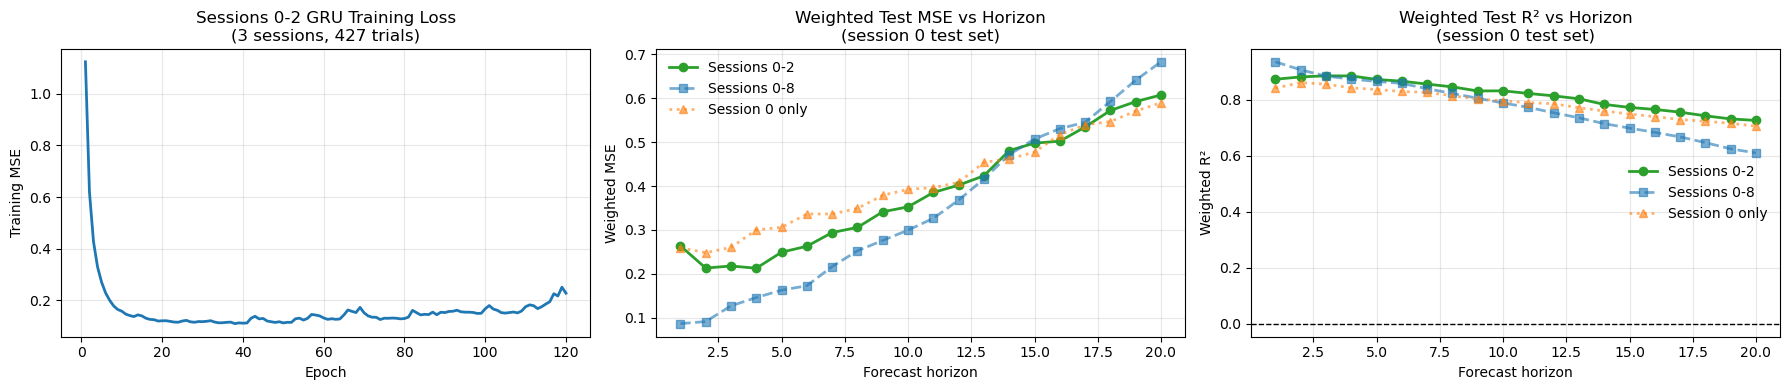

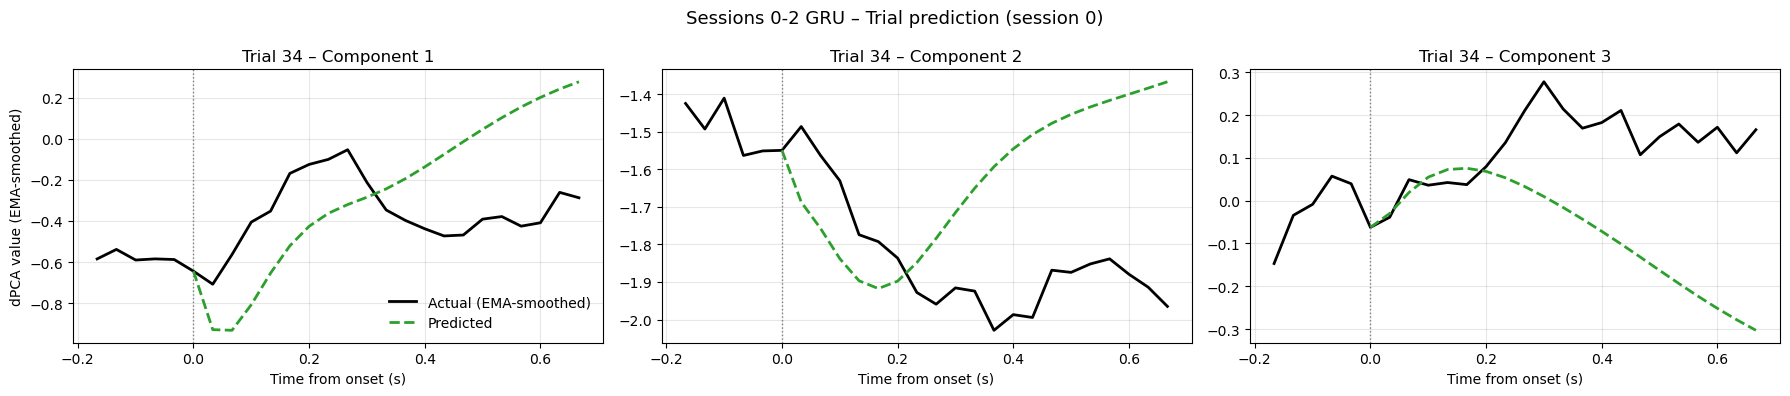

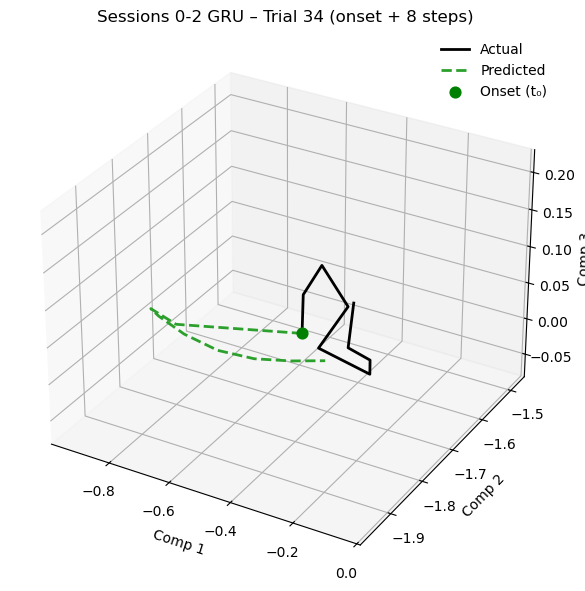


SESSIONS 0-2 GRU SUMMARY
Sessions       : [0, 1, 2]
Pooled train   : 427 trials
Session-0 test : 33 trials
Architecture   : GRU 2-layer, hidden=256
Training time  : 27.82s (0.2319 s/epoch)
Inference time : 0.004740s

Weighted horizon metrics on session-0 test set (first 5):
        Sess 0-2 wR²  Sess 0-8 wR²  Sess 0 only
  t+01:       0.87305       0.93537      0.84175
  t+02:       0.88156       0.90662      0.86119
  t+03:       0.88536       0.88438      0.85545
  t+04:       0.88496       0.87370      0.84243
  t+05:       0.87245       0.86536      0.83633


In [ ]:
# ===================================================================
# Multi-Session GRU (sessions 0-2): 2 layers, 256 hidden
# ===================================================================

SESSION_IDS_S3  = [0, 1, 2]
HORIZON_S3      = 20
N_COMP_S3       = 10
HIDDEN_DIM_S3   = 256
NUM_LAYERS_S3   = 2
EPOCHS_S3       = 120
BATCH_SIZE_S3   = 32
LR_S3           = 1e-3
STIM_DIM_S3     = 1
TRIAL_ID_S3     = 34
H3D_S3          = 8

device_s3 = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device_s3}")

# ------------------------------------------------------------------
# 1) Compute common context length across the 3 sessions
# ------------------------------------------------------------------
zero_idx_s3 = {}
for sid in SESSION_IDS_S3:
    taxis_tmp = sessions[sid]['filter_ps_time'].copy()
    dt_tmp    = taxis_tmp[1] - taxis_tmp[0]
    taxis_tmp = taxis_tmp + dt_tmp
    zero_idx_s3[sid] = int(np.argmin(np.abs(taxis_tmp)))

COMMON_CTX_S3 = builtins.min(z + 1 for z in zero_idx_s3.values())
print(f"Zero indices: {zero_idx_s3}  →  common ctx = {COMMON_CTX_S3}")

# ------------------------------------------------------------------
# 2) Per-session processing → pooled training data
# ------------------------------------------------------------------
pool_cz_s3, pool_cv_s3, pool_fv_s3, pool_tz_s3 = [], [], [], []
s0te_cz_s3, s0te_cv_s3, s0te_fv_s3, s0te_tz_s3 = [], [], [], []

s0_zm_s3 = s0_zs_s3 = s0_cw_s3 = None
s0_ztrial_s3 = s0_sfrac_s3 = None
s0_zero_s3 = s0_taxis_s3 = None

total_train_s3 = 0

for sid in SESSION_IDS_S3:
    sess  = sessions[sid]
    taxis = sess['filter_ps_time'].copy()
    dt_s  = taxis[1] - taxis[0]
    taxis = taxis + dt_s
    zero_s = zero_idx_s3[sid]

    neural = sess['behaviour_trials']
    ts     = sess['trial_subsets']
    nt     = sess['n_trials']
    N_s    = sess['n_cells']
    T_s    = sess['n_times']

    tr_idx, te_idx = train_test_split(
        np.arange(nt), test_size=0.2, random_state=42, shuffle=True)
    tr_idx, te_idx = np.sort(tr_idx), np.sort(te_idx)

    uconds = np.unique(ts)
    tpc    = {c: np.intersect1d(np.where(ts == c)[0], tr_idx) for c in uconds}
    min_t  = builtins.min(len(v_) for v_ in tpc.values())
    S_s    = len(uconds)
    rng_s  = np.random.default_rng(42)

    trialR_s = np.zeros((min_t, N_s, S_s, T_s))
    for si, cond in enumerate(uconds):
        sel = rng_s.choice(tpc[cond], size=min_t, replace=False)
        for i, tidx in enumerate(sel):
            trialR_s[i, :, si, :] = neural[:, tidx, :]

    R_s   = trialR_s.mean(axis=0)
    R_s_c = R_s - R_s.reshape(N_s, -1).mean(1)[:, None, None]

    dpca_s3 = dPCA_cls.dPCA(labels='st', regularizer='auto', n_components=N_COMP_S3)
    dpca_s3.protect = ['t']
    dpca_s3.fit_transform(R_s_c, trialR_s)

    sm  = R_s.reshape(N_s, -1).mean(1)[:, None, None]
    za  = dpca_s3.transform(neural - sm)
    zt  = np.concatenate([za['s'], za['t'], za['st']], axis=0)
    zt  = np.transpose(zt, (1, 2, 0)).astype(np.float32)

    # Apply EMA smoothing to dPCA trajectories
    zt  = apply_ema(zt, alpha=EMA_ALPHA)

    sfrac = (sess['is_target'].sum(axis=0) / max(N_s, 1)).astype(np.float32)[:, :, None]

    zm = zt[tr_idx].mean(axis=(0, 1), keepdims=True)
    zs = zt[tr_idx].std(axis=(0, 1), keepdims=True) + 1e-6
    zt_n = (zt - zm) / zs

    ctx_start = zero_s + 1 - COMMON_CTX_S3

    for tidx in tr_idx:
        tg = zt_n[tidx, zero_s + 1 : zero_s + 1 + HORIZON_S3, :]
        if tg.shape[0] == HORIZON_S3:
            pool_cz_s3.append(zt_n[tidx, ctx_start : zero_s + 1, :])
            pool_cv_s3.append(sfrac[tidx, ctx_start : zero_s + 1, :])
            pool_fv_s3.append(sfrac[tidx, zero_s + 1 : zero_s + 1 + HORIZON_S3, :])
            pool_tz_s3.append(tg)

    if sid == 0:
        s0_zm_s3, s0_zs_s3 = zm, zs
        cvar = zt[tr_idx].var(axis=(0, 1))
        s0_cw_s3 = cvar / (cvar.sum() + 1e-12)
        s0_ztrial_s3, s0_sfrac_s3 = zt, sfrac
        s0_zero_s3, s0_taxis_s3 = zero_s, taxis

        for tidx in te_idx:
            tg = zt_n[tidx, zero_s + 1 : zero_s + 1 + HORIZON_S3, :]
            if tg.shape[0] == HORIZON_S3:
                s0te_cz_s3.append(zt_n[tidx, ctx_start : zero_s + 1, :])
                s0te_cv_s3.append(sfrac[tidx, ctx_start : zero_s + 1, :])
                s0te_fv_s3.append(sfrac[tidx, zero_s + 1 : zero_s + 1 + HORIZON_S3, :])
                s0te_tz_s3.append(tg)

    total_train_s3 += len(tr_idx)
    print(f"Sess {sid} ({sess['mouse']:>5s}): {len(tr_idx):>3d} train, "
          f"{len(te_idx):>3d} test, N={N_s:>3d}, zero_idx={zero_s}")

print(f"\nPooled training samples : {len(pool_cz_s3)} "
      f"(from {total_train_s3} train trials across {len(SESSION_IDS_S3)} sessions)")
print(f"Session-0 test samples  : {len(s0te_cz_s3)}")

# ------------------------------------------------------------------
# 3) Datasets & model (reuse PooledOnsetDataset and GRUStimForecastMS)
# ------------------------------------------------------------------
train_ds_s3 = PooledOnsetDataset(pool_cz_s3, pool_cv_s3, pool_fv_s3, pool_tz_s3)
test_ds_s3  = PooledOnsetDataset(s0te_cz_s3, s0te_cv_s3, s0te_fv_s3, s0te_tz_s3)

train_loader_s3 = DataLoader(train_ds_s3, batch_size=BATCH_SIZE_S3, shuffle=True)
test_loader_s3  = DataLoader(test_ds_s3,  batch_size=len(test_ds_s3), shuffle=False)

d_z_s3 = pool_cz_s3[0].shape[-1]
model_s3 = GRUStimForecastMS(
    latent_dim=d_z_s3, stim_dim=STIM_DIM_S3,
    hidden_dim=HIDDEN_DIM_S3, num_layers=NUM_LAYERS_S3, dropout=0.1
).to(device_s3)

optimizer_s3 = torch.optim.Adam(model_s3.parameters(), lr=LR_S3, weight_decay=1e-5)
criterion_s3 = nn.MSELoss()

print(f"\nModel: GRU {NUM_LAYERS_S3}-layer, hidden={HIDDEN_DIM_S3}, "
      f"input=d_z({d_z_s3})+stim({STIM_DIM_S3})")
print(f"Trainable params: {sum(p.numel() for p in model_s3.parameters() if p.requires_grad):,}")

# ------------------------------------------------------------------
# 4) Train
# ------------------------------------------------------------------
loss_hist_s3 = []
test_loss_hist_s3 = []
t0_train_s3  = time.perf_counter()

for epoch in range(1, EPOCHS_S3 + 1):
    model_s3.train()
    running = 0.0
    tf = 0.7 + (0.1 - 0.7) * ((epoch - 1) / max(EPOCHS_S3 - 1, 1))

    for cz_b, cv_b, fv_b, tz_b in train_loader_s3:
        cz_b = cz_b.to(device_s3); cv_b = cv_b.to(device_s3)
        fv_b = fv_b.to(device_s3); tz_b = tz_b.to(device_s3)

        optimizer_s3.zero_grad()
        pred_s3_ = model_s3(cz_b, cv_b, fv_b, target_z=tz_b, teacher_forcing=tf)
        loss_s3_ = criterion_s3(pred_s3_, tz_b)
        loss_s3_.backward()
        torch.nn.utils.clip_grad_norm_(model_s3.parameters(), 1.0)
        optimizer_s3.step()
        running += loss_s3_.item() * cz_b.shape[0]

    ep = running / len(train_ds_s3)
    loss_hist_s3.append(ep)

    # Compute test loss (session-0 test set, open-loop)
    model_s3.eval()
    with torch.no_grad():
        test_running = 0.0
        for cz_b, cv_b, fv_b, tz_b in test_loader_s3:
            cz_b = cz_b.to(device_s3); cv_b = cv_b.to(device_s3)
            fv_b = fv_b.to(device_s3); tz_b = tz_b.to(device_s3)
            pred = model_s3(cz_b, cv_b, fv_b, target_z=None, teacher_forcing=0.0)
            test_running += criterion_s3(pred, tz_b).item() * cz_b.shape[0]
        test_loss_hist_s3.append(test_running / len(test_ds_s3))

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d}/{EPOCHS_S3} | loss={ep:.6f} | test_loss={test_loss_hist_s3[-1]:.6f} | tf={tf:.3f}")

training_time_s3 = time.perf_counter() - t0_train_s3

# ------------------------------------------------------------------
# 5) Evaluate on session-0 test set
# ------------------------------------------------------------------
model_s3.eval()
with torch.no_grad():
    cz_t3, cv_t3, fv_t3, tz_t3 = next(iter(test_loader_s3))
    cz_t3 = cz_t3.to(device_s3); cv_t3 = cv_t3.to(device_s3); fv_t3 = fv_t3.to(device_s3)
    if device_s3.type == 'cuda': torch.cuda.synchronize()
    inf_t0_s3 = time.perf_counter()
    pred_t3   = model_s3(cz_t3, cv_t3, fv_t3, target_z=None, teacher_forcing=0.0)
    if device_s3.type == 'cuda': torch.cuda.synchronize()
    inference_time_s3 = time.perf_counter() - inf_t0_s3

pred_arr_s3 = pred_t3.cpu().numpy()
targ_arr_s3 = tz_t3.numpy()
pred_dn_s3  = pred_arr_s3 * s0_zs_s3 + s0_zm_s3
targ_dn_s3  = targ_arr_s3 * s0_zs_s3 + s0_zm_s3

horizons_s3 = np.arange(1, HORIZON_S3 + 1)
wmse_h_s3, wr2_h_s3 = [], []

for h in range(HORIZON_S3):
    yt3, yp3 = targ_dn_s3[:, h, :], pred_dn_s3[:, h, :]
    mse_c3 = np.mean((yp3 - yt3) ** 2, axis=0)
    wmse_h_s3.append(float(np.sum(s0_cw_s3 * mse_c3)))
    r2c3 = np.array([r2_score(yt3[:, c], yp3[:, c]) if np.var(yt3[:, c]) > 1e-12 else 0.0
                     for c in range(d_z_s3)])
    wr2_h_s3.append(float(np.sum(s0_cw_s3 * r2c3)))

# ------------------------------------------------------------------
# 6) Plots
# ------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(np.arange(1, EPOCHS_S3 + 1), loss_hist_s3, lw=2, label='Train')
axes[0].plot(np.arange(1, EPOCHS_S3 + 1), test_loss_hist_s3, lw=2, ls='--', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
axes[0].set_title(f'Sessions 0-2 GRU Training & Test Loss\n'
                  f'({len(SESSION_IDS_S3)} sessions, {len(train_ds_s3)} trials)')
axes[0].grid(alpha=0.3); axes[0].legend(frameon=False)

axes[1].plot(horizons_s3, wmse_h_s3, marker='o', lw=2, color='tab:green', label='Sessions 0-2')
try:
    axes[1].plot(horizons_ms, wmse_h, marker='s', lw=2, ls='--', alpha=0.6, color='tab:blue', label='Sessions 0-8')
    axes[1].plot(horizons, weighted_mse_by_h, marker='^', lw=2, ls=':', alpha=0.6, color='tab:orange', label='Session 0 only')
    axes[1].legend(frameon=False)
except NameError:
    pass
axes[1].set_xlabel('Forecast horizon'); axes[1].set_ylabel('Weighted MSE')
axes[1].set_title('Weighted Test MSE vs Horizon\n(session 0 test set)')
axes[1].grid(alpha=0.3)

axes[2].plot(horizons_s3, wr2_h_s3, marker='o', lw=2, color='tab:green', label='Sessions 0-2')
try:
    axes[2].plot(horizons_ms, wr2_h, marker='s', lw=2, ls='--', alpha=0.6, color='tab:blue', label='Sessions 0-8')
    axes[2].plot(horizons, weighted_r2_by_h, marker='^', lw=2, ls=':', alpha=0.6, color='tab:orange', label='Session 0 only')
    axes[2].legend(frameon=False)
except NameError:
    pass
axes[2].axhline(0.0, color='k', ls='--', lw=1)
axes[2].set_xlabel('Forecast horizon'); axes[2].set_ylabel('Weighted R²')
axes[2].set_title('Weighted Test R² vs Horizon\n(session 0 test set)')
axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# --- Trial 34: 2D time-series ---
pre_s3   = 5
zt_n_s3  = (s0_ztrial_s3 - s0_zm_s3) / s0_zs_s3
ctx_st_s3 = s0_zero_s3 + 1 - COMMON_CTX_S3

cz_s3 = torch.from_numpy(zt_n_s3[TRIAL_ID_S3, ctx_st_s3 : s0_zero_s3 + 1, :]).unsqueeze(0).to(device_s3)
cv_s3 = torch.from_numpy(s0_sfrac_s3[TRIAL_ID_S3, ctx_st_s3 : s0_zero_s3 + 1, :]).unsqueeze(0).to(device_s3)
fv_s3 = torch.from_numpy(
    s0_sfrac_s3[TRIAL_ID_S3, s0_zero_s3 + 1 : s0_zero_s3 + 1 + HORIZON_S3, :]
).unsqueeze(0).to(device_s3)

with torch.no_grad():
    pred_s3_np_r = model_s3(cz_s3, cv_s3, fv_s3, target_z=None, teacher_forcing=0.0)
pred_s3_np = (pred_s3_np_r.squeeze(0).cpu().numpy()
              * s0_zs_s3.squeeze((0, 1)) + s0_zm_s3.squeeze((0, 1)))

t_s3 = s0_zero_s3 - pre_s3
e_s3 = s0_zero_s3 + 1 + HORIZON_S3
tw3  = s0_taxis_s3[t_s3:e_s3]
trw3 = s0_ztrial_s3[TRIAL_ID_S3, t_s3:e_s3, :]
prw3 = np.full_like(trw3, np.nan)
prw3[pre_s3, :]      = trw3[pre_s3, :]
prw3[pre_s3 + 1:, :] = pred_s3_np

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
for c in range(3):
    axes[c].plot(tw3, trw3[:, c], lw=2, label='Actual (EMA-smoothed)', color='black')
    axes[c].plot(tw3, prw3[:, c], lw=2, ls='--', label='Predicted', color='tab:green')
    axes[c].axvline(0.0, color='gray', ls=':', lw=1)
    axes[c].set_title(f'Trial {TRIAL_ID_S3} – Component {c + 1}')
    axes[c].set_xlabel('Time from onset (s)')
    axes[c].grid(alpha=0.3)
axes[0].set_ylabel('dPCA value (EMA-smoothed)')
axes[0].legend(frameon=False)
plt.suptitle('Sessions 0-2 GRU – Trial prediction (session 0)', fontsize=13)
plt.tight_layout(); plt.show()

# --- 3D trajectory ---
onset_s3  = s0_ztrial_s3[TRIAL_ID_S3, s0_zero_s3, :]
true_3d_s3 = np.vstack([onset_s3[None, :],
                         s0_ztrial_s3[TRIAL_ID_S3, s0_zero_s3 + 1 : s0_zero_s3 + 1 + H3D_S3, :]])
pred_3d_s3 = np.vstack([onset_s3[None, :], pred_s3_np[:H3D_S3, :]])

fig = plt.figure(figsize=(7, 6))
ax  = fig.add_subplot(111, projection='3d')
ax.plot(true_3d_s3[:, 0], true_3d_s3[:, 1], true_3d_s3[:, 2],
        color='black', lw=2, label='Actual')
ax.plot(pred_3d_s3[:, 0], pred_3d_s3[:, 1], pred_3d_s3[:, 2],
        color='tab:green', lw=2, ls='--', label='Predicted')
ax.scatter(*onset_s3[:3], color='green', s=60, zorder=5, label='Onset (t₀)')
ax.set_title(f'Sessions 0-2 GRU – Trial {TRIAL_ID_S3} (onset + {H3D_S3} steps)')
ax.set_xlabel('Comp 1'); ax.set_ylabel('Comp 2'); ax.set_zlabel('Comp 3')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

# ------------------------------------------------------------------
# 7) Summary
# ------------------------------------------------------------------
print('\n' + '=' * 60)
print('SESSIONS 0-2 GRU SUMMARY')
print('=' * 60)
print(f"Sessions       : {SESSION_IDS_S3}")
print(f"Pooled train   : {len(train_ds_s3)} trials")
print(f"Session-0 test : {len(test_ds_s3)} trials")
print(f"Architecture   : GRU {NUM_LAYERS_S3}-layer, hidden={HIDDEN_DIM_S3}")
print(f"Training time  : {training_time_s3:.2f}s "
      f"({training_time_s3 / EPOCHS_S3:.4f} s/epoch)")
print(f"Inference time : {inference_time_s3:.6f}s")

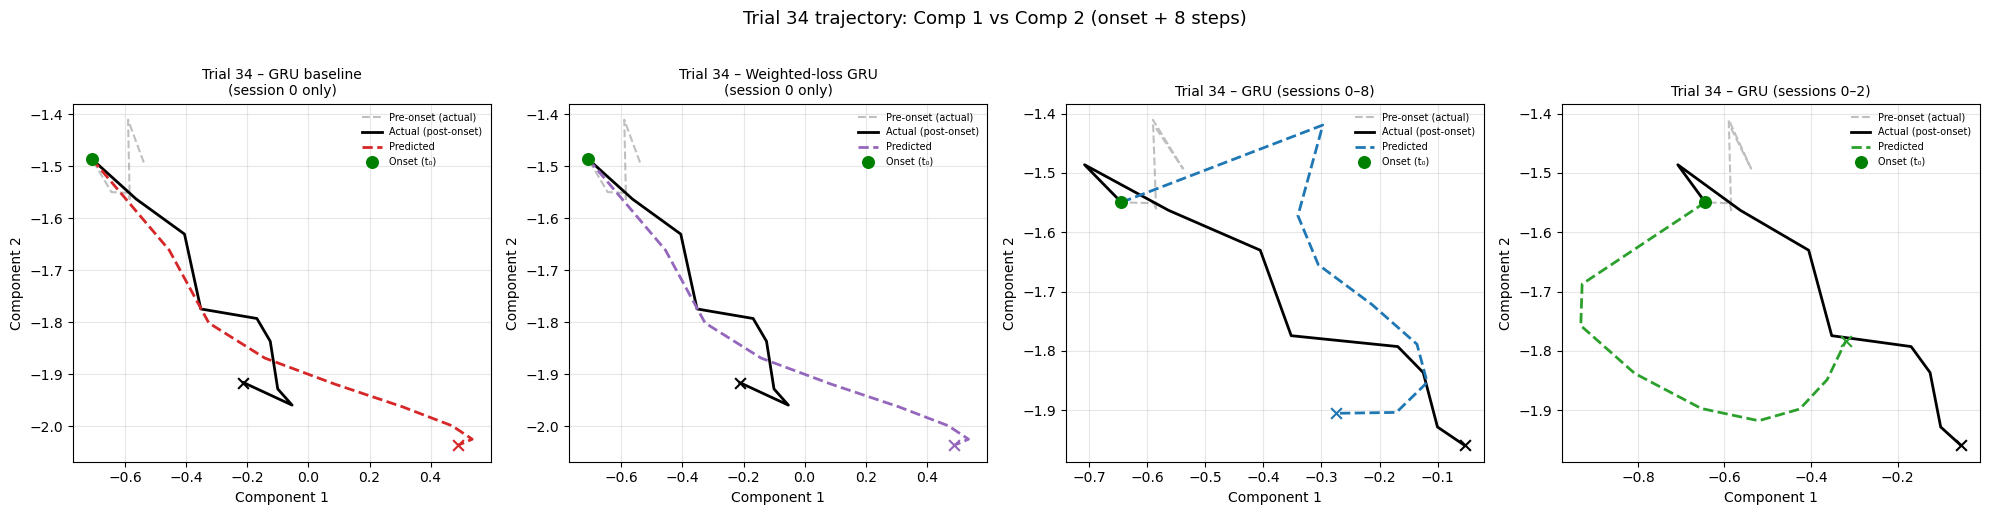

In [ ]:
# ===================================================================
# 2D phase-plane comparison – Trial 34, Comp 1 vs Comp 2
# All four models: GRU baseline | Weighted-loss GRU | Sess 0-8 | Sess 0-2
# ===================================================================

H2D   = H3D          # 8 post-onset steps (same as 3D plots)
PRE   = 5             # pre-onset steps shown

# ---- collect (actual_pre, actual_post, onset, pred_post) per model ----
# Each entry: (actual_full[pre+1+H, 2], onset[2], pred[H, 2], label, colour)
models_2d = []

# 1) GRU baseline  (uses z_trial, zero_idx, pred_single)
_z   = z_trial[trial_id]                               # (T, d_z)
_pre = _z[zero_idx - PRE : zero_idx + 1, :2]          # pre→onset (inclusive)
_pos = _z[zero_idx + 1 : zero_idx + 1 + H2D, :2]
_on  = _z[zero_idx, :2]
models_2d.append((_pre, _pos, _on, pred_single[:H2D, :2],
                  'GRU baseline\n(session 0 only)', 'tab:red'))

# 2) Weighted-loss GRU  (uses z_trial_local, zero_idx, pred_single_w)
_z   = z_trial_local[trial_id_local]
_pre = _z[zero_idx - PRE : zero_idx + 1, :2]
_pos = _z[zero_idx + 1 : zero_idx + 1 + H2D, :2]
_on  = _z[zero_idx, :2]
models_2d.append((_pre, _pos, _on, pred_single_w[:H2D, :2],
                  'Weighted-loss GRU\n(session 0 only)', 'tab:purple'))

# 3) Multi-session (0-8)  (uses s0_ztrial, s0_zero, pred_s_np)
_z   = s0_ztrial[TRIAL_ID_MS]
_pre = _z[s0_zero - PRE : s0_zero + 1, :2]
_pos = _z[s0_zero + 1 : s0_zero + 1 + H2D, :2]
_on  = _z[s0_zero, :2]
models_2d.append((_pre, _pos, _on, pred_s_np[:H2D, :2],
                  'GRU (sessions 0–8)', 'tab:blue'))

# 4) Multi-session (0-2)  (uses s0_ztrial_s3, s0_zero_s3, pred_s3_np)
_z   = s0_ztrial_s3[TRIAL_ID_S3]
_pre = _z[s0_zero_s3 - PRE : s0_zero_s3 + 1, :2]
_pos = _z[s0_zero_s3 + 1 : s0_zero_s3 + 1 + H2D, :2]
_on  = _z[s0_zero_s3, :2]
models_2d.append((_pre, _pos, _on, pred_s3_np[:H2D, :2],
                  'GRU (sessions 0–2)', 'tab:green'))

# ---- plot ----
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (pre, pos, on, pred, title, col) in zip(axes, models_2d):
    # actual: pre-onset segment (light gray)
    ax.plot(pre[:, 0], pre[:, 1],
            color='gray', lw=1.5, ls='--', alpha=0.5, label='Pre-onset (actual)')
    # actual: onset → post-onset
    post_full = np.vstack([on[None, :], pos])
    ax.plot(post_full[:, 0], post_full[:, 1],
            color='black', lw=2, label='Actual (post-onset)')
    # predicted: onset → post-onset
    pred_full = np.vstack([on[None, :], pred])
    ax.plot(pred_full[:, 0], pred_full[:, 1],
            color=col, lw=2, ls='--', label='Predicted')

    # markers: onset, first post-onset actual, first post-onset predicted
    ax.scatter(*on, color='green', s=70, zorder=5, label='Onset (t₀)')
    ax.scatter(pos[-1, 0], pos[-1, 1],
               color='black', marker='x', s=60, zorder=5)
    ax.scatter(pred[-1, 0], pred[-1, 1],
               color=col, marker='x', s=60, zorder=5)

    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.set_title(f'Trial 34 – {title}', fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, frameon=False)

plt.suptitle(f'Trial 34 trajectory: Comp 1 vs Comp 2 (onset + {H2D} steps)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## Vanilla RNN + Post-dPCA Augmentation — Multi-Session (Sessions 0–2)

Same strategy as the single-session Vanilla RNN + post-dPCA augmentation experiment (cell 14), but now **training on pooled data from sessions 0, 1, and 2**.

**Key differences from the single-session version:**
- **EMA smoothing**: $\alpha = 0.5$ (instead of 0.3) for both this experiment and the single-session re-run used in the comparison.
- **Stimulation input**: 1-D stim fraction (fraction of targeted neurons per timestep) for cross-session compatibility.
- **Post-dPCA augmentation**: 15 noisy copies per stimulated trial (noise fraction 0.15) injected in the peri-onset window of the already-projected dPCA latent space.
- **Separate dPCA per session**: each session's neurons are projected to a common 10-component latent dimensionality (30-d total: 10 stimulus + 10 time + 10 interaction).
- **Evaluation**: exclusively on session 0's test set (80/20 split, `random_state=42`).

Device: cuda
EMA alpha: 0.5
Zero indices: {0: 237, 1: 238, 2: 238}  →  common ctx = 238
You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set by changing self.n_trials (default = 3). Similarly,
                    use self.protect to set the list of axes that are not supposed to get to get shuffled
                    (e.g. upon splitting the data into test- and training, time-points should always
                    be drawn from the same trial, i.e. self.protect = ['t']). This can significantly
                    speed up the code.
Start optimizing regularization.
Starting trial  1 / 3
Starting trial  2 / 3
Starting trial  3 / 3
Optimized regularization, optimal lambda =  0.0008819763977946266
Regularization will be fixed; to compute the optimal                    parameter again on the next fit, please                

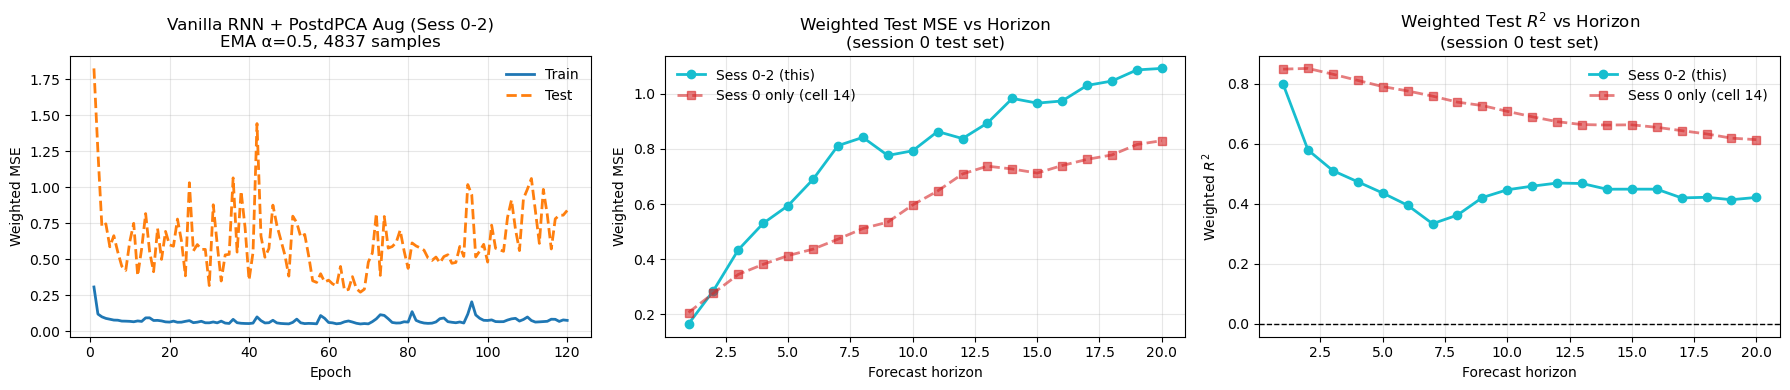

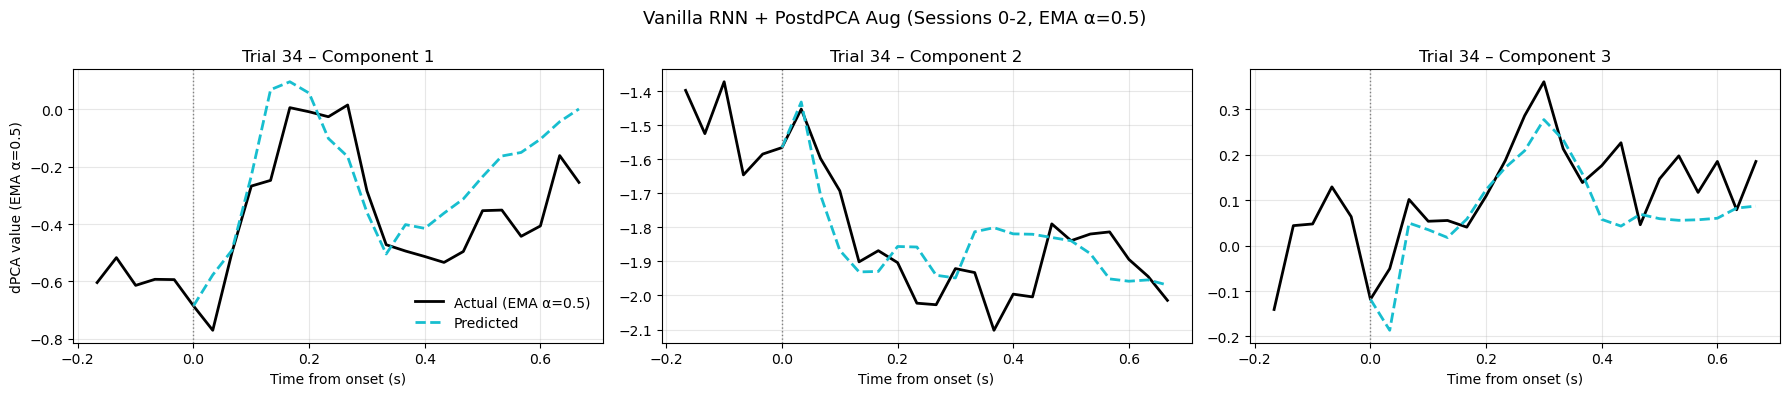

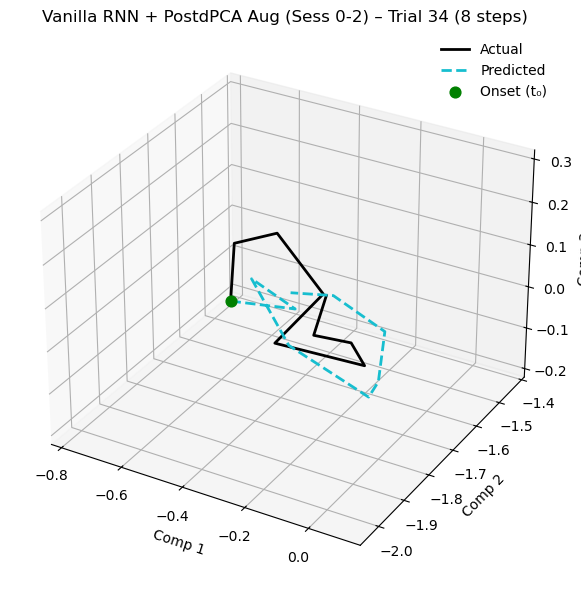


VANILLA RNN + POST-dPCA AUG (SESSIONS 0-2) SUMMARY
Sessions       : [0, 1, 2]
EMA alpha      : 0.5
Aug copies     : 15 per stimulated trial
Train samples  : 4837
Test (sess 0)  : 33
Architecture   : Vanilla RNN 2L, hidden=256
Params         : 418,846
Training time  : 171.83s (1.4319 s/epoch)
Inference time : 0.002225s

Weighted horizon metrics (first 5):
   h        wMSE         wR²
t+01     0.16544     0.79834
t+02     0.28612     0.57909
t+03     0.43420     0.51031
t+04     0.53016     0.47321
t+05     0.59435     0.43583


In [16]:
# ===================================================================
# Vanilla RNN + Post-dPCA Augmentation — Multi-Session (Sessions 0–2)
# ===================================================================
# EMA α = 0.5 (instead of default 0.3)

SESSION_IDS_VR   = [0, 1, 2]
HORIZON_VR       = 20
N_COMP_VR        = 10
HIDDEN_DIM_VR    = 256
NUM_LAYERS_VR    = 2
EPOCHS_VR        = 120
BATCH_SIZE_VR    = 32
LR_VR            = 1e-3
STIM_DIM_VR      = 1          # stim fraction (cross-session)
TRIAL_ID_VR      = 34
H3D_VR           = 8
EMA_ALPHA_VR     = 0.5        # NEW: 0.5 instead of 0.3
N_AUGMENT_VR     = 15
NOISE_FRAC_VR    = 0.075
AUG_HALF_WIN_VR  = 5

device_vr = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device_vr}")
print(f"EMA alpha: {EMA_ALPHA_VR}")

# ---------- 1) Common context length ----------
zero_idx_vr = {}
for sid in SESSION_IDS_VR:
    taxis_tmp = sessions[sid]['filter_ps_time'].copy()
    dt_tmp    = taxis_tmp[1] - taxis_tmp[0]
    taxis_tmp = taxis_tmp + dt_tmp
    zero_idx_vr[sid] = int(np.argmin(np.abs(taxis_tmp)))

COMMON_CTX_VR = builtins.min(z + 1 for z in zero_idx_vr.values())
print(f"Zero indices: {zero_idx_vr}  →  common ctx = {COMMON_CTX_VR}")

# ---------- 2) Per-session processing ----------
pool_cz_vr, pool_cv_vr, pool_fv_vr, pool_tz_vr = [], [], [], []
pool_stim_mask_vr = []  # whether each pooled sample is from a stimulated trial

s0te_cz_vr, s0te_cv_vr, s0te_fv_vr, s0te_tz_vr = [], [], [], []

# Session-0 metadata for evaluation
s0_zm_vr = s0_zs_vr = s0_cw_vr = None
s0_ztrial_vr = s0_sfrac_vr = None
s0_zero_vr = s0_taxis_vr = None
s0_z_comp_std_vr = None  # for noise injection

total_train_vr = 0

for sid in SESSION_IDS_VR:
    sess  = sessions[sid]
    taxis = sess['filter_ps_time'].copy()
    dt_s  = taxis[1] - taxis[0]
    taxis = taxis + dt_s
    zero_s = zero_idx_vr[sid]

    neural = sess['behaviour_trials']
    ts     = sess['trial_subsets']
    nt     = sess['n_trials']
    N_s    = sess['n_cells']
    T_s    = sess['n_times']

    # 80/20 split
    tr_idx, te_idx = train_test_split(
        np.arange(nt), test_size=0.2, random_state=42, shuffle=True)
    tr_idx, te_idx = np.sort(tr_idx), np.sort(te_idx)

    # dPCA on training trials
    uconds = np.unique(ts)
    tpc    = {c: np.intersect1d(np.where(ts == c)[0], tr_idx) for c in uconds}
    min_t  = builtins.min(len(v_) for v_ in tpc.values())
    S_s    = len(uconds)
    rng_s  = np.random.default_rng(42)

    trialR_s = np.zeros((min_t, N_s, S_s, T_s))
    for si, cond in enumerate(uconds):
        sel = rng_s.choice(tpc[cond], size=min_t, replace=False)
        for i, tidx in enumerate(sel):
            trialR_s[i, :, si, :] = neural[:, tidx, :]

    R_s   = trialR_s.mean(axis=0)
    R_s_c = R_s - R_s.reshape(N_s, -1).mean(1)[:, None, None]

    dpca_vr = dPCA_cls.dPCA(labels='st', regularizer='auto', n_components=N_COMP_VR)
    dpca_vr.protect = ['t']
    dpca_vr.fit_transform(R_s_c, trialR_s)

    sm  = R_s.reshape(N_s, -1).mean(1)[:, None, None]
    za  = dpca_vr.transform(neural - sm)
    zt  = np.concatenate([za['s'], za['t'], za['st']], axis=0)
    zt  = np.transpose(zt, (1, 2, 0)).astype(np.float32)

    # EMA with alpha=0.5
    zt = apply_ema(zt, alpha=EMA_ALPHA_VR)

    d_z_vr = zt.shape[-1]

    # Stim fraction
    sfrac = (sess['is_target'].sum(axis=0) / max(N_s, 1)).astype(np.float32)[:, :, None]

    # Identify stimulated trials
    is_stim_sess = sess['is_target'].reshape(N_s, nt, T_s).any(axis=(0, 2))  # (nt,)

    # Normalise
    zm = zt[tr_idx].mean(axis=(0, 1), keepdims=True)
    zs = zt[tr_idx].std(axis=(0, 1), keepdims=True) + 1e-6
    zt_n = (zt - zm) / zs

    ctx_start = zero_s + 1 - COMMON_CTX_VR

    # Build training tuples (clean)
    for i_loc, tidx in enumerate(tr_idx):
        tg = zt_n[tidx, zero_s + 1 : zero_s + 1 + HORIZON_VR, :]
        if tg.shape[0] == HORIZON_VR:
            pool_cz_vr.append(zt_n[tidx, ctx_start : zero_s + 1, :])
            pool_cv_vr.append(sfrac[tidx, ctx_start : zero_s + 1, :])
            pool_fv_vr.append(sfrac[tidx, zero_s + 1 : zero_s + 1 + HORIZON_VR, :])
            pool_tz_vr.append(tg)
            pool_stim_mask_vr.append(bool(is_stim_sess[tidx]))

    # Session 0: test data + metadata
    if sid == 0:
        s0_zm_vr, s0_zs_vr = zm, zs
        cvar = zt[tr_idx].var(axis=(0, 1))
        s0_cw_vr = cvar / (cvar.sum() + 1e-12)
        s0_ztrial_vr, s0_sfrac_vr = zt, sfrac
        s0_zero_vr, s0_taxis_vr = zero_s, taxis

        # Per-component std for noise injection (from session-0 normalized train)
        s0_z_comp_std_vr = zt_n[tr_idx].std(axis=(0, 1)).astype(np.float32)

        for tidx in te_idx:
            tg = zt_n[tidx, zero_s + 1 : zero_s + 1 + HORIZON_VR, :]
            if tg.shape[0] == HORIZON_VR:
                s0te_cz_vr.append(zt_n[tidx, ctx_start : zero_s + 1, :])
                s0te_cv_vr.append(sfrac[tidx, ctx_start : zero_s + 1, :])
                s0te_fv_vr.append(sfrac[tidx, zero_s + 1 : zero_s + 1 + HORIZON_VR, :])
                s0te_tz_vr.append(tg)

    total_train_vr += len(tr_idx)
    print(f"Sess {sid} ({sess['mouse']:>5s}): {len(tr_idx):>3d} train, "
          f"{len(te_idx):>3d} test, N={N_s:>3d}, d_z={d_z_vr}, zero_idx={zero_s}")

pool_stim_mask_vr = np.array(pool_stim_mask_vr)
n_stim_pool = int(pool_stim_mask_vr.sum())
n_ctrl_pool = len(pool_stim_mask_vr) - n_stim_pool

print(f"\nClean pooled training samples: {len(pool_cz_vr)} "
      f"({n_stim_pool} stimulated, {n_ctrl_pool} control)")
print(f"Session-0 test samples: {len(s0te_cz_vr)}")
print(f"After augmentation: {n_stim_pool * (1 + N_AUGMENT_VR) + n_ctrl_pool} samples/epoch")

# ---------- 3) Post-dPCA Augmented Dataset ----------

noise_std_vr = (NOISE_FRAC_VR * s0_z_comp_std_vr).astype(np.float32)

# Peri-onset window indices
onset_in_ctx = COMMON_CTX_VR - 1
aug_ctx_start_vr = max(onset_in_ctx - AUG_HALF_WIN_VR, 0)
aug_ctx_end_vr   = COMMON_CTX_VR  # up to end of context
aug_tgt_end_vr   = min(AUG_HALF_WIN_VR, HORIZON_VR)


class PostDPCAAugPooledDataset(Dataset):
    """Post-dPCA noise augmentation for pooled multi-session data.
    Stimulated trials: 1 clean + N_AUGMENT noisy copies.
    Control trials: 1 clean copy only.
    """

    def __init__(self, cz_list, cv_list, fv_list, tz_list, stim_mask,
                 n_augment, noise_std, ctx_aug_start, ctx_aug_end, tgt_aug_end):
        self.cz = cz_list
        self.cv = cv_list
        self.fv = fv_list
        self.tz = tz_list
        self.noise_std = noise_std
        self.ctx_aug_start = ctx_aug_start
        self.ctx_aug_end = ctx_aug_end
        self.tgt_aug_end = tgt_aug_end

        self.items = []
        for i in range(len(cz_list)):
            self.items.append((i, 0))  # clean
            if stim_mask[i]:
                for k in range(1, n_augment + 1):
                    self.items.append((i, k))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        pool_i, copy_k = self.items[idx]

        context_z = self.cz[pool_i].copy()
        context_v = self.cv[pool_i]
        future_v  = self.fv[pool_i]
        target_z  = self.tz[pool_i].copy()

        if copy_k > 0:
            n_ctx = self.ctx_aug_end - self.ctx_aug_start
            if n_ctx > 0:
                context_z[self.ctx_aug_start:self.ctx_aug_end, :] += (
                    np.random.randn(n_ctx, len(self.noise_std)).astype(np.float32)
                    * self.noise_std
                )
            if self.tgt_aug_end > 0:
                target_z[:self.tgt_aug_end, :] += (
                    np.random.randn(self.tgt_aug_end, len(self.noise_std)).astype(np.float32)
                    * self.noise_std
                )

        return (
            torch.from_numpy(context_z),
            torch.from_numpy(context_v),
            torch.from_numpy(future_v),
            torch.from_numpy(target_z),
        )


aug_train_ds_vr = PostDPCAAugPooledDataset(
    pool_cz_vr, pool_cv_vr, pool_fv_vr, pool_tz_vr,
    stim_mask=pool_stim_mask_vr,
    n_augment=N_AUGMENT_VR,
    noise_std=noise_std_vr,
    ctx_aug_start=aug_ctx_start_vr,
    ctx_aug_end=aug_ctx_end_vr,
    tgt_aug_end=aug_tgt_end_vr,
)
aug_train_loader_vr = DataLoader(aug_train_ds_vr, batch_size=BATCH_SIZE_VR, shuffle=True)

# Test set (clean, session 0 only)
test_ds_vr = PooledOnsetDataset(s0te_cz_vr, s0te_cv_vr, s0te_fv_vr, s0te_tz_vr)
test_loader_vr = DataLoader(test_ds_vr, batch_size=len(test_ds_vr), shuffle=False)

print(f"Augmented train dataset: {len(aug_train_ds_vr)} samples")
print(f"Test dataset (session 0): {len(test_ds_vr)} samples")

# ---------- 4) Vanilla RNN Model ----------

class VanillaRNNStimForecastMS(nn.Module):
    def __init__(self, latent_dim, stim_dim, hidden_dim=256, num_layers=2, dropout=0.1):
        super().__init__()
        self.encoder = nn.RNN(
            input_size=latent_dim + stim_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity='tanh',
            dropout=0.0,
        )
        self.num_layers = num_layers
        self.decoder_cells = nn.ModuleList()
        self.decoder_cells.append(nn.RNNCell(latent_dim + stim_dim, hidden_dim, nonlinearity='tanh'))
        for _ in range(1, num_layers):
            self.decoder_cells.append(nn.RNNCell(hidden_dim, hidden_dim, nonlinearity='tanh'))
        self.readout = nn.Linear(hidden_dim, latent_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, context_z, context_v, future_v, target_z=None, teacher_forcing=0.0):
        enc_in = torch.cat([context_z, context_v], dim=-1)
        _, h_n = self.encoder(enc_in)
        prev_z = context_z[:, -1, :]
        preds = []
        H = future_v.shape[1]
        for k in range(H):
            dec_in = torch.cat([prev_z, future_v[:, k, :]], dim=-1)
            h_in = dec_in
            h_new = []
            for li, cell in enumerate(self.decoder_cells):
                h_l = cell(h_in, h_n[li])
                h_l = self.dropout(h_l)
                h_new.append(h_l)
                h_in = h_l
            h_n = torch.stack(h_new, dim=0)
            pred_z = self.readout(h_n[-1])
            preds.append(pred_z.unsqueeze(1))
            if self.training and target_z is not None and teacher_forcing > 0:
                mask = (torch.rand(pred_z.shape[0], device=pred_z.device) < teacher_forcing).float().unsqueeze(-1)
                prev_z = mask * target_z[:, k, :] + (1 - mask) * pred_z
            else:
                prev_z = pred_z
        return torch.cat(preds, dim=1)


d_z_vr = pool_cz_vr[0].shape[-1]
model_vr = VanillaRNNStimForecastMS(
    latent_dim=d_z_vr, stim_dim=STIM_DIM_VR,
    hidden_dim=HIDDEN_DIM_VR, num_layers=NUM_LAYERS_VR, dropout=0.1
).to(device_vr)

optimizer_vr = torch.optim.Adam(model_vr.parameters(), lr=LR_VR, weight_decay=1e-5)
cw_t_vr = torch.from_numpy(s0_cw_vr).float().to(device_vr)

def weighted_mse_vr(pred, target, weights):
    per_comp = ((pred - target) ** 2).mean(dim=(0, 1))
    return (weights * per_comp).sum()

n_params_vr = sum(p.numel() for p in model_vr.parameters() if p.requires_grad)
print(f"\nModel: Vanilla RNN {NUM_LAYERS_VR}-layer, hidden={HIDDEN_DIM_VR}, "
      f"stim_dim={STIM_DIM_VR}")
print(f"Trainable params: {n_params_vr:,}")

# ---------- 5) Train ----------

loss_hist_vr = []
test_loss_hist_vr = []
t0_vr = time.perf_counter()

for epoch in range(1, EPOCHS_VR + 1):
    model_vr.train()
    running = 0.0
    tf = 0.7 + (0.1 - 0.7) * ((epoch - 1) / max(EPOCHS_VR - 1, 1))

    for cz_b, cv_b, fv_b, tz_b in aug_train_loader_vr:
        cz_b = cz_b.to(device_vr); cv_b = cv_b.to(device_vr)
        fv_b = fv_b.to(device_vr); tz_b = tz_b.to(device_vr)

        optimizer_vr.zero_grad()
        pred_b = model_vr(cz_b, cv_b, fv_b, target_z=tz_b, teacher_forcing=tf)
        loss = weighted_mse_vr(pred_b, tz_b, cw_t_vr)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_vr.parameters(), 1.0)
        optimizer_vr.step()
        running += loss.item() * cz_b.shape[0]

    ep = running / len(aug_train_ds_vr)
    loss_hist_vr.append(ep)

    # Test loss (open-loop)
    model_vr.eval()
    with torch.no_grad():
        test_run = 0.0
        for cz_b, cv_b, fv_b, tz_b in test_loader_vr:
            cz_b = cz_b.to(device_vr); cv_b = cv_b.to(device_vr)
            fv_b = fv_b.to(device_vr); tz_b = tz_b.to(device_vr)
            pred_b = model_vr(cz_b, cv_b, fv_b, target_z=None, teacher_forcing=0.0)
            test_run += weighted_mse_vr(pred_b, tz_b, cw_t_vr).item() * cz_b.shape[0]
        test_loss_hist_vr.append(test_run / len(test_ds_vr))

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d}/{EPOCHS_VR} | loss={ep:.6f} | "
              f"test_loss={test_loss_hist_vr[-1]:.6f} | tf={tf:.3f}")

training_time_vr = time.perf_counter() - t0_vr

# ---------- 6) Evaluate on session-0 test set ----------

model_vr.eval()
with torch.no_grad():
    cz_t, cv_t, fv_t, tz_t = next(iter(test_loader_vr))
    cz_t = cz_t.to(device_vr); cv_t = cv_t.to(device_vr); fv_t = fv_t.to(device_vr)
    if device_vr.type == 'cuda': torch.cuda.synchronize()
    inf_t0_vr = time.perf_counter()
    pred_t_vr = model_vr(cz_t, cv_t, fv_t, target_z=None, teacher_forcing=0.0)
    if device_vr.type == 'cuda': torch.cuda.synchronize()
    inference_time_vr = time.perf_counter() - inf_t0_vr

pred_arr_vr = pred_t_vr.cpu().numpy()
targ_arr_vr = tz_t.numpy()
pred_dn_vr  = pred_arr_vr * s0_zs_vr + s0_zm_vr
targ_dn_vr  = targ_arr_vr * s0_zs_vr + s0_zm_vr

horizons_vr = np.arange(1, HORIZON_VR + 1)
wmse_h_vr, wr2_h_vr = [], []

for h in range(HORIZON_VR):
    yt, yp = targ_dn_vr[:, h, :], pred_dn_vr[:, h, :]
    mse_c = np.mean((yp - yt) ** 2, axis=0)
    wmse_h_vr.append(float(np.sum(s0_cw_vr * mse_c)))
    r2c = np.array([r2_score(yt[:, c], yp[:, c]) if np.var(yt[:, c]) > 1e-12 else 0.0
                    for c in range(d_z_vr)])
    wr2_h_vr.append(float(np.sum(s0_cw_vr * r2c)))

# ---------- 7) Plots: training + horizon metrics ----------

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(np.arange(1, EPOCHS_VR + 1), loss_hist_vr, lw=2, label='Train')
axes[0].plot(np.arange(1, EPOCHS_VR + 1), test_loss_hist_vr, lw=2, ls='--', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Weighted MSE')
axes[0].set_title(f'Vanilla RNN + PostdPCA Aug (Sess 0-2)\n'
                  f'EMA α={EMA_ALPHA_VR}, {len(aug_train_ds_vr)} samples')
axes[0].grid(alpha=0.3); axes[0].legend(frameon=False)

axes[1].plot(horizons_vr, wmse_h_vr, marker='o', lw=2, color='tab:cyan', label='Sess 0-2 (this)')
try:
    axes[1].plot(horizons_rnn, wmse_rnn_postaug, marker='s', lw=2, ls='--',
                 alpha=0.6, color='tab:red', label='Sess 0 only (cell 14)')
except NameError:
    pass
axes[1].set_xlabel('Forecast horizon'); axes[1].set_ylabel('Weighted MSE')
axes[1].set_title('Weighted Test MSE vs Horizon\n(session 0 test set)')
axes[1].legend(frameon=False); axes[1].grid(alpha=0.3)

axes[2].plot(horizons_vr, wr2_h_vr, marker='o', lw=2, color='tab:cyan', label='Sess 0-2 (this)')
try:
    axes[2].plot(horizons_rnn, wr2_rnn_postaug, marker='s', lw=2, ls='--',
                 alpha=0.6, color='tab:red', label='Sess 0 only (cell 14)')
except NameError:
    pass
axes[2].axhline(0.0, color='k', ls='--', lw=1)
axes[2].set_xlabel('Forecast horizon'); axes[2].set_ylabel('Weighted $R^2$')
axes[2].set_title('Weighted Test $R^2$ vs Horizon\n(session 0 test set)')
axes[2].legend(frameon=False); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# ---------- 8) Trial 34 time-series plots ----------

pre_vr   = 5
zt_n_s0_vr = (s0_ztrial_vr - s0_zm_vr) / s0_zs_vr
ctx_st_vr  = s0_zero_vr + 1 - COMMON_CTX_VR

cz_s_vr = torch.from_numpy(zt_n_s0_vr[TRIAL_ID_VR, ctx_st_vr : s0_zero_vr + 1, :]).unsqueeze(0).to(device_vr)
cv_s_vr = torch.from_numpy(s0_sfrac_vr[TRIAL_ID_VR, ctx_st_vr : s0_zero_vr + 1, :]).unsqueeze(0).to(device_vr)
fv_s_vr = torch.from_numpy(
    s0_sfrac_vr[TRIAL_ID_VR, s0_zero_vr + 1 : s0_zero_vr + 1 + HORIZON_VR, :]
).unsqueeze(0).to(device_vr)

with torch.no_grad():
    pred_s_vr = model_vr(cz_s_vr, cv_s_vr, fv_s_vr, target_z=None, teacher_forcing=0.0)
pred_s_vr_np = (pred_s_vr.squeeze(0).cpu().numpy()
                * s0_zs_vr.squeeze((0, 1)) + s0_zm_vr.squeeze((0, 1)))

start_vr = s0_zero_vr - pre_vr
end_vr   = s0_zero_vr + 1 + HORIZON_VR
tw_vr    = s0_taxis_vr[start_vr:end_vr]
trw_vr   = s0_ztrial_vr[TRIAL_ID_VR, start_vr:end_vr, :]

prw_vr = np.full_like(trw_vr, np.nan)
prw_vr[pre_vr, :]      = trw_vr[pre_vr, :]
prw_vr[pre_vr + 1:, :] = pred_s_vr_np

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
for c in range(3):
    axes[c].plot(tw_vr, trw_vr[:, c], lw=2, label='Actual (EMA α=0.5)', color='black')
    axes[c].plot(tw_vr, prw_vr[:, c], lw=2, ls='--', label='Predicted', color='tab:cyan')
    axes[c].axvline(0.0, color='gray', ls=':', lw=1)
    axes[c].set_title(f'Trial {TRIAL_ID_VR} – Component {c + 1}')
    axes[c].set_xlabel('Time from onset (s)')
    axes[c].grid(alpha=0.3)
axes[0].set_ylabel('dPCA value (EMA α=0.5)')
axes[0].legend(frameon=False)
plt.suptitle('Vanilla RNN + PostdPCA Aug (Sessions 0-2, EMA α=0.5)', fontsize=13)
plt.tight_layout(); plt.show()

# 3D trajectory
onset_vr  = s0_ztrial_vr[TRIAL_ID_VR, s0_zero_vr, :]
true_3d_vr = np.vstack([onset_vr[None, :],
                         s0_ztrial_vr[TRIAL_ID_VR, s0_zero_vr + 1 : s0_zero_vr + 1 + H3D_VR, :]])
pred_3d_vr = np.vstack([onset_vr[None, :], pred_s_vr_np[:H3D_VR, :]])

fig = plt.figure(figsize=(7, 6))
ax  = fig.add_subplot(111, projection='3d')
ax.plot(true_3d_vr[:, 0], true_3d_vr[:, 1], true_3d_vr[:, 2],
        color='black', lw=2, label='Actual')
ax.plot(pred_3d_vr[:, 0], pred_3d_vr[:, 1], pred_3d_vr[:, 2],
        color='tab:cyan', lw=2, ls='--', label='Predicted')
ax.scatter(*onset_vr[:3], color='green', s=60, zorder=5, label='Onset (t₀)')
ax.set_title(f'Vanilla RNN + PostdPCA Aug (Sess 0-2) – Trial {TRIAL_ID_VR} ({H3D_VR} steps)')
ax.set_xlabel('Comp 1'); ax.set_ylabel('Comp 2'); ax.set_zlabel('Comp 3')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

# ---------- 9) Summary ----------

print('\n' + '=' * 70)
print('VANILLA RNN + POST-dPCA AUG (SESSIONS 0-2) SUMMARY')
print('=' * 70)
print(f"Sessions       : {SESSION_IDS_VR}")
print(f"EMA alpha      : {EMA_ALPHA_VR}")
print(f"Aug copies     : {N_AUGMENT_VR} per stimulated trial")
print(f"Train samples  : {len(aug_train_ds_vr)}")
print(f"Test (sess 0)  : {len(test_ds_vr)}")
print(f"Architecture   : Vanilla RNN {NUM_LAYERS_VR}L, hidden={HIDDEN_DIM_VR}")
print(f"Params         : {n_params_vr:,}")
print(f"Training time  : {training_time_vr:.2f}s ({training_time_vr / EPOCHS_VR:.4f} s/epoch)")
print(f"Inference time : {inference_time_vr:.6f}s")

print(f"\nWeighted horizon metrics (first 5):")
print(f"{'h':>4s}  {'wMSE':>10s}  {'wR²':>10s}")
for h in range(min(5, HORIZON_VR)):
    print(f"t+{h+1:02d}  {wmse_h_vr[h]:10.5f}  {wr2_h_vr[h]:10.5f}")

## Procrustes-Aligned Vanilla RNN + Post-dPCA Augmentation — Multi-Session (Sessions 0–2)

### Problem: dPCA axes are session-specific

In the previous cell, `dpca_vr` is fitted **independently** on each session's training data.
Because the neuron populations differ across sessions, the resulting demixed axes are determined only up to an arbitrary orthogonal rotation.
Concretely, Component 1 in Session 0 may capture a completely different mixture of stimulus/time variance than Component 1 in Session 2.

When these latent trajectories are pooled and fed into a **shared Vanilla RNN**, the network is forced to learn multiple *conflicting* dynamical rules simultaneously — one per session's unaligned coordinate frame.
A GRU can partially gate away the conflicts; a Vanilla RNN cannot.

### Solution: Orthogonal Procrustes alignment

We align every session's dPCA latent space to a **reference session** (Session 0) using the classical **Orthogonal Procrustes** problem (Schönemann, 1966):

$$
\hat{R}_s = \arg\min_{R \in \mathcal{O}(d)} \| Z_{\mathrm{ref}} - Z_s\, R \|_F
\quad \text{subject to} \quad R^\top R = I_d,
$$

where $Z_{\mathrm{ref}} \in \mathbb{R}^{T \times d}$ is the **trial-averaged** latent trajectory of
Session 0 and $Z_s$ is the corresponding trajectory of session $s$, both evaluated on the
*stimulus-condition-averaged* dPCA output (prior to any EMA smoothing or $z$-scoring).

The closed-form solution is given by the SVD of the cross-covariance matrix:

$$
Z_{\mathrm{ref}}^\top Z_s = U \Sigma V^\top
\quad \Longrightarrow \quad
\hat{R}_s = V U^\top.
$$

After computing $\hat{R}_s$ for each non-reference session, we apply the alignment to **all**
single-trial latent matrices:

$$
\tilde{Z}_s^{(k)} = Z_s^{(k)}\, \hat{R}_s, \qquad k = 1, \dots, K_s,
$$

where $Z_s^{(k)}$ is the $k$-th trial's dPCA latent data for session $s$.

This rotation is applied **immediately** after the dPCA `transform` step and **before**:
1. EMA smoothing ($\alpha$-filtering),
2. $z$-score normalisation.

Because $\hat{R}_s$ is orthogonal, it preserves norms and inner products; the only information it
changes is the coordinate frame alignment, eliminating cross-session axis ambiguity.

### Implementation note

We use `scipy.linalg.orthogonal_procrustes`, which returns the optimal $\hat{R}_s$ and the
residual Frobenius norm.  The alignment reference is the **condition-averaged** dPCA output
(averaged across all training trials per condition, then averaged across conditions) for
Session 0.  This gives a clean, low-noise target that captures the dominant stimulus and time
structure.

Device: cuda
EMA alpha: 0.5
Zero indices: {0: 237, 1: 238, 2: 238}  →  common ctx = 238
You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set by changing self.n_trials (default = 3). Similarly,
                    use self.protect to set the list of axes that are not supposed to get to get shuffled
                    (e.g. upon splitting the data into test- and training, time-points should always
                    be drawn from the same trial, i.e. self.protect = ['t']). This can significantly
                    speed up the code.
Start optimizing regularization.
Starting trial  1 / 3
Starting trial  2 / 3
Starting trial  3 / 3
Optimized regularization, optimal lambda =  0.0008819763977946266
Regularization will be fixed; to compute the optimal                    parameter again on the next fit, please                

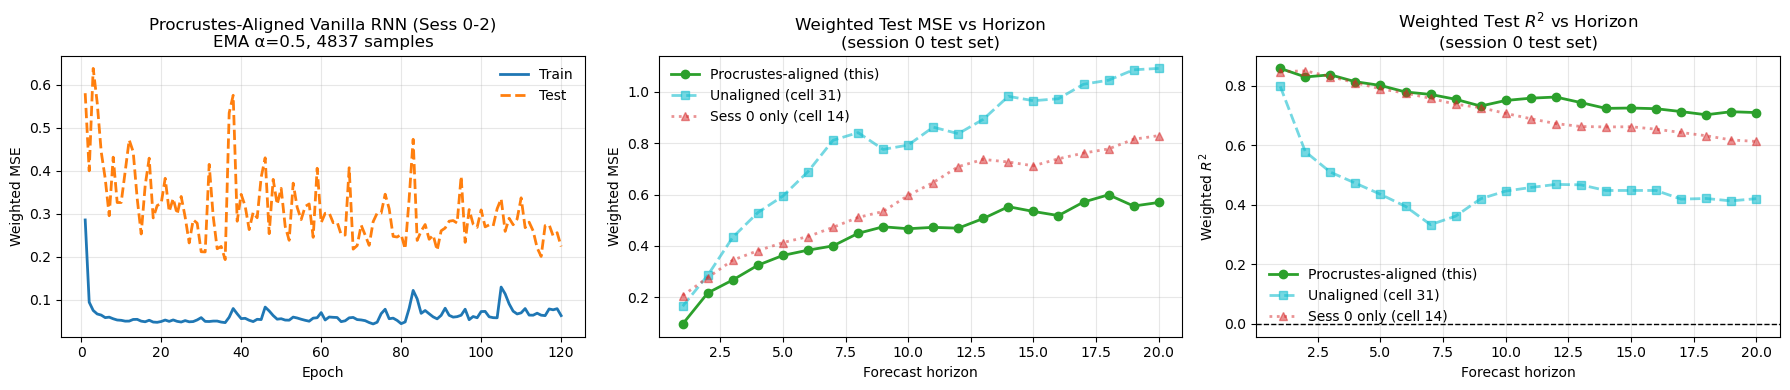

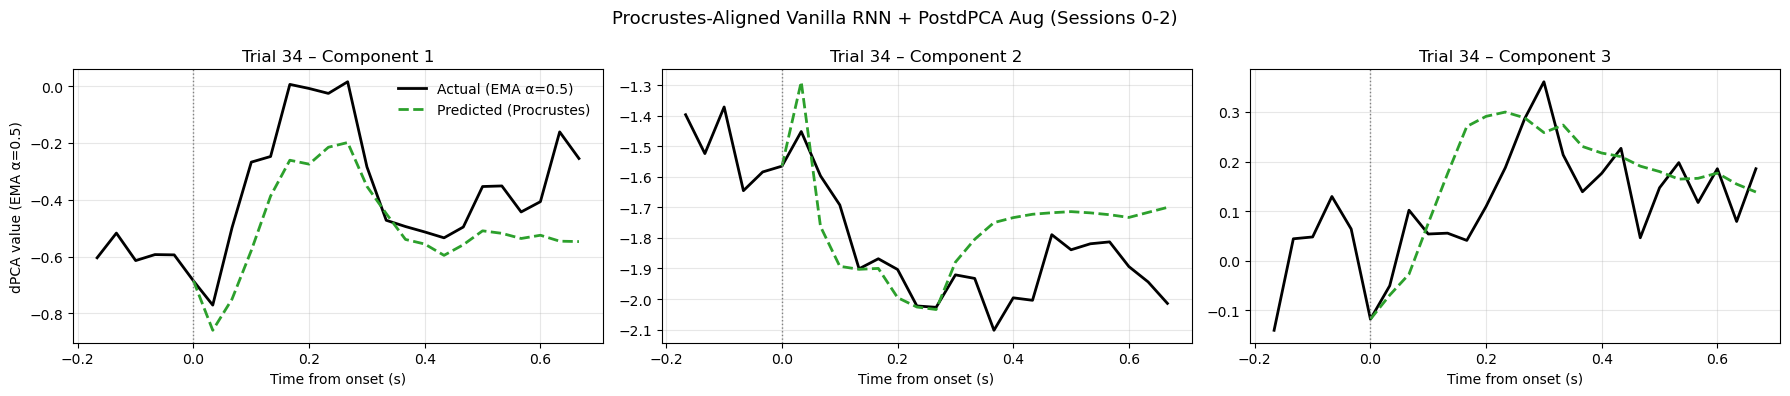

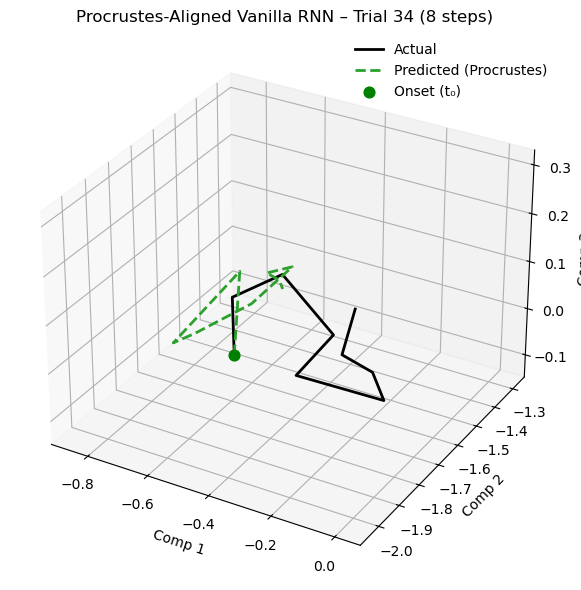


PROCRUSTES-ALIGNED VANILLA RNN + POST-dPCA AUG (SESS 0-2) SUMMARY
Sessions           : [0, 1, 2]
Reference session  : 0
EMA alpha          : 0.5
Aug copies         : 15 per stimulated trial
Train samples      : 4837
Test (sess 0)      : 33
Architecture       : Vanilla RNN 2L, hidden=256
Params             : 418,846
Training time      : 173.87s (1.4489 s/epoch)
Inference time     : 0.002204s

Weighted horizon metrics (first 5):
   h        wMSE         wR²   Δ wMSE vs unaligned
t+01     0.09641     0.85899    -0.06903
t+02     0.21721     0.83028    -0.06891
t+03     0.26772     0.83745    -0.16648
t+04     0.32512     0.81423    -0.20504
t+05     0.36326     0.80175    -0.23109

Mean wR² (aligned):   0.76069
Mean wR² (unaligned): 0.45865
Improvement:          +0.30204


In [18]:
# ============================================================================
# Procrustes-Aligned Vanilla RNN + Post-dPCA Augmentation  (Sessions 0–2)
# ============================================================================
# Identical to the previous cell EXCEPT:
#   - After dPCA.transform but BEFORE EMA & z-score, each non-reference
#     session's latent space is rotated onto Session 0 via Orthogonal
#     Procrustes (scipy.linalg.orthogonal_procrustes).

from scipy.linalg import orthogonal_procrustes

# ---------- Hyperparameters (mirror cell 31) ----------
SESSION_IDS_PA  = [0, 1, 2]
REF_SID_PA      = 0              # alignment reference session
HORIZON_PA      = 20
N_COMP_PA       = 10
HIDDEN_DIM_PA   = 256
NUM_LAYERS_PA   = 2
EPOCHS_PA       = 120
BATCH_SIZE_PA   = 32
LR_PA           = 1e-3
STIM_DIM_PA     = 1
TRIAL_ID_PA     = 34
H3D_PA          = 8
EMA_ALPHA_PA    = 0.5
N_AUGMENT_PA    = 15
NOISE_FRAC_PA   = 0.075
AUG_HALF_WIN_PA = 5

device_pa = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device_pa}")
print(f"EMA alpha: {EMA_ALPHA_PA}")

# ---------- 1) Common context length ----------
zero_idx_pa = {}
for sid in SESSION_IDS_PA:
    taxis_tmp = sessions[sid]['filter_ps_time'].copy()
    dt_tmp    = taxis_tmp[1] - taxis_tmp[0]
    taxis_tmp = taxis_tmp + dt_tmp
    zero_idx_pa[sid] = int(np.argmin(np.abs(taxis_tmp)))

COMMON_CTX_PA = builtins.min(z + 1 for z in zero_idx_pa.values())
print(f"Zero indices: {zero_idx_pa}  →  common ctx = {COMMON_CTX_PA}")

# =====================================================================
# PASS 1 — Fit dPCA per session, store RAW latents + alignment anchors
# =====================================================================
raw_dpca_pa = {}          # sid → dict of raw data
align_anchors_pa = {}     # sid → condition-averaged dPCA trajectory  (M, d_z)

for sid in SESSION_IDS_PA:
    sess  = sessions[sid]
    taxis = sess['filter_ps_time'].copy()
    dt_s  = taxis[1] - taxis[0]
    taxis = taxis + dt_s
    zero_s = zero_idx_pa[sid]

    neural = sess['behaviour_trials']
    ts     = sess['trial_subsets']
    nt     = sess['n_trials']
    N_s    = sess['n_cells']
    T_s    = sess['n_times']

    # 80/20 split (same seed → exact same split as cell 31)
    tr_idx, te_idx = train_test_split(
        np.arange(nt), test_size=0.2, random_state=42, shuffle=True)
    tr_idx, te_idx = np.sort(tr_idx), np.sort(te_idx)

    # Build balanced trial tensor for dPCA
    uconds = np.unique(ts)
    tpc    = {c: np.intersect1d(np.where(ts == c)[0], tr_idx) for c in uconds}
    min_t  = builtins.min(len(v_) for v_ in tpc.values())
    S_s    = len(uconds)
    rng_s  = np.random.default_rng(42)

    trialR_s = np.zeros((min_t, N_s, S_s, T_s))
    for si, cond in enumerate(uconds):
        sel = rng_s.choice(tpc[cond], size=min_t, replace=False)
        for i, tidx in enumerate(sel):
            trialR_s[i, :, si, :] = neural[:, tidx, :]

    R_s   = trialR_s.mean(axis=0)                                # (N, S, T)
    R_s_c = R_s - R_s.reshape(N_s, -1).mean(1)[:, None, None]    # centered

    dpca_fit = dPCA_cls.dPCA(labels='st', regularizer='auto', n_components=N_COMP_PA)
    dpca_fit.protect = ['t']
    dpca_fit.fit_transform(R_s_c, trialR_s)

    # --- Raw per-trial latents (BEFORE EMA / z-score) ---
    sm  = R_s.reshape(N_s, -1).mean(1)[:, None, None]
    za  = dpca_fit.transform(neural - sm)
    zt_raw = np.concatenate([za['s'], za['t'], za['st']], axis=0)   # (d_z, nt, T)
    zt_raw = np.transpose(zt_raw, (1, 2, 0)).astype(np.float32)    # (nt, T, d_z)

    # --- Condition-averaged dPCA output → alignment anchor ---
    za_avg  = dpca_fit.transform(R_s_c)                             # dict
    zt_avg  = np.concatenate([za_avg['s'], za_avg['t'], za_avg['st']], axis=0)  # (d_z, S, T)
    zt_avg  = zt_avg.reshape(zt_avg.shape[0], -1).T.astype(np.float64)         # (S*T, d_z)

    # --- Stim fraction & stim mask ---
    sfrac = (sess['is_target'].sum(axis=0) / max(N_s, 1)).astype(np.float32)[:, :, None]
    is_stim_sess = sess['is_target'].reshape(N_s, nt, T_s).any(axis=(0, 2))

    raw_dpca_pa[sid] = dict(
        zt_raw=zt_raw, sfrac=sfrac, is_stim=is_stim_sess,
        tr_idx=tr_idx, te_idx=te_idx,
        zero_s=zero_s, taxis=taxis, nt=nt,
        N_s=N_s, T_s=T_s, mouse=sess['mouse'],
    )
    align_anchors_pa[sid] = zt_avg
    print(f"[Pass 1] Sess {sid} ({sess['mouse']:>5s}): anchor shape {zt_avg.shape}, "
          f"N={N_s}, T={T_s}")

# =====================================================================
# PROCRUSTES ALIGNMENT  — rotate every session onto Session 0
# =====================================================================
Z_ref_pa = align_anchors_pa[REF_SID_PA]   # (M_ref, d_z)

# Use common row count (in case S×T differs across sessions)
min_anchor_rows = builtins.min(a.shape[0] for a in align_anchors_pa.values())
Z_ref_trunc = Z_ref_pa[:min_anchor_rows]

procrustes_rotations = {REF_SID_PA: np.eye(Z_ref_pa.shape[1], dtype=np.float32)}

print(f"\nProcrustes alignment (reference = Session {REF_SID_PA}):")
for sid in SESSION_IDS_PA:
    if sid == REF_SID_PA:
        print(f"  Session {sid}: identity (reference)")
        continue
    Z_s = align_anchors_pa[sid][:min_anchor_rows]
    R_proc, _ = orthogonal_procrustes(Z_s, Z_ref_trunc)
    procrustes_rotations[sid] = R_proc.astype(np.float32)
    residual = np.linalg.norm(Z_ref_trunc - Z_s @ R_proc, 'fro')
    print(f"  Session {sid} → Session {REF_SID_PA}: "
          f"||Z_ref − Z_s R||_F = {residual:.4f}")

# =====================================================================
# PASS 2 — Apply rotation → EMA → z-score → build training tuples
# =====================================================================
pool_cz_pa, pool_cv_pa, pool_fv_pa, pool_tz_pa = [], [], [], []
pool_stim_mask_pa = []

s0te_cz_pa, s0te_cv_pa, s0te_fv_pa, s0te_tz_pa = [], [], [], []

s0_zm_pa = s0_zs_pa = s0_cw_pa = None
s0_ztrial_pa = s0_sfrac_pa = None
s0_zero_pa = s0_taxis_pa = None
s0_z_comp_std_pa = None

total_train_pa = 0

for sid in SESSION_IDS_PA:
    info   = raw_dpca_pa[sid]
    zt     = info['zt_raw'].copy()          # (nt, T, d_z)

    # ---- Procrustes rotation (BEFORE EMA & z-score) ----
    R_proc = procrustes_rotations[sid]
    n_tr, T_s, d_z_pa = zt.shape
    zt = (zt.reshape(-1, d_z_pa) @ R_proc).reshape(n_tr, T_s, d_z_pa)

    # ---- EMA smoothing ----
    zt = apply_ema(zt, alpha=EMA_ALPHA_PA)

    tr_idx       = info['tr_idx']
    te_idx       = info['te_idx']
    zero_s       = info['zero_s']
    sfrac        = info['sfrac']
    is_stim_sess = info['is_stim']

    # ---- z-score (fit on train) ----
    zm = zt[tr_idx].mean(axis=(0, 1), keepdims=True)
    zs = zt[tr_idx].std(axis=(0, 1), keepdims=True) + 1e-6
    zt_n = (zt - zm) / zs

    ctx_start = zero_s + 1 - COMMON_CTX_PA

    # Build clean training tuples
    for tidx in tr_idx:
        tg = zt_n[tidx, zero_s + 1 : zero_s + 1 + HORIZON_PA, :]
        if tg.shape[0] == HORIZON_PA:
            pool_cz_pa.append(zt_n[tidx, ctx_start : zero_s + 1, :])
            pool_cv_pa.append(sfrac[tidx, ctx_start : zero_s + 1, :])
            pool_fv_pa.append(sfrac[tidx, zero_s + 1 : zero_s + 1 + HORIZON_PA, :])
            pool_tz_pa.append(tg)
            pool_stim_mask_pa.append(bool(is_stim_sess[tidx]))

    # Session 0: test data + metadata
    if sid == 0:
        s0_zm_pa, s0_zs_pa = zm, zs
        cvar = zt[tr_idx].var(axis=(0, 1))
        s0_cw_pa = cvar / (cvar.sum() + 1e-12)
        s0_ztrial_pa, s0_sfrac_pa = zt, sfrac
        s0_zero_pa, s0_taxis_pa = zero_s, info['taxis']
        s0_z_comp_std_pa = zt_n[tr_idx].std(axis=(0, 1)).astype(np.float32)

        for tidx in te_idx:
            tg = zt_n[tidx, zero_s + 1 : zero_s + 1 + HORIZON_PA, :]
            if tg.shape[0] == HORIZON_PA:
                s0te_cz_pa.append(zt_n[tidx, ctx_start : zero_s + 1, :])
                s0te_cv_pa.append(sfrac[tidx, ctx_start : zero_s + 1, :])
                s0te_fv_pa.append(sfrac[tidx, zero_s + 1 : zero_s + 1 + HORIZON_PA, :])
                s0te_tz_pa.append(tg)

    total_train_pa += len(tr_idx)
    flag = 'Identity' if sid == REF_SID_PA else 'Aligned'
    print(f"[Pass 2] Sess {sid} ({info['mouse']:>5s}): {len(tr_idx):>3d} train, "
          f"{len(te_idx):>3d} test, d_z={d_z_pa}, Procrustes={flag}")

pool_stim_mask_pa = np.array(pool_stim_mask_pa)
n_stim_pool_pa = int(pool_stim_mask_pa.sum())
n_ctrl_pool_pa = len(pool_stim_mask_pa) - n_stim_pool_pa

print(f"\nAligned pooled training samples: {len(pool_cz_pa)} "
      f"({n_stim_pool_pa} stimulated, {n_ctrl_pool_pa} control)")
print(f"Session-0 test samples: {len(s0te_cz_pa)}")
print(f"After augmentation: {n_stim_pool_pa * (1 + N_AUGMENT_PA) + n_ctrl_pool_pa} samples/epoch")

# ---------- 3) Post-dPCA Augmented Dataset (reuse class from cell 31) ----------

noise_std_pa = (NOISE_FRAC_PA * s0_z_comp_std_pa).astype(np.float32)

onset_in_ctx_pa    = COMMON_CTX_PA - 1
aug_ctx_start_pa   = max(onset_in_ctx_pa - AUG_HALF_WIN_PA, 0)
aug_ctx_end_pa     = COMMON_CTX_PA
aug_tgt_end_pa     = min(AUG_HALF_WIN_PA, HORIZON_PA)

aug_train_ds_pa = PostDPCAAugPooledDataset(
    pool_cz_pa, pool_cv_pa, pool_fv_pa, pool_tz_pa,
    stim_mask=pool_stim_mask_pa,
    n_augment=N_AUGMENT_PA,
    noise_std=noise_std_pa,
    ctx_aug_start=aug_ctx_start_pa,
    ctx_aug_end=aug_ctx_end_pa,
    tgt_aug_end=aug_tgt_end_pa,
)
aug_train_loader_pa = DataLoader(aug_train_ds_pa, batch_size=BATCH_SIZE_PA, shuffle=True)

test_ds_pa = PooledOnsetDataset(s0te_cz_pa, s0te_cv_pa, s0te_fv_pa, s0te_tz_pa)
test_loader_pa = DataLoader(test_ds_pa, batch_size=len(test_ds_pa), shuffle=False)

print(f"Augmented train dataset: {len(aug_train_ds_pa)} samples")
print(f"Test dataset (session 0): {len(test_ds_pa)} samples")

# ---------- 4) Vanilla RNN (reuse VanillaRNNStimForecastMS from cell 31) ----------

d_z_pa = pool_cz_pa[0].shape[-1]
model_pa = VanillaRNNStimForecastMS(
    latent_dim=d_z_pa, stim_dim=STIM_DIM_PA,
    hidden_dim=HIDDEN_DIM_PA, num_layers=NUM_LAYERS_PA, dropout=0.1
).to(device_pa)

optimizer_pa = torch.optim.Adam(model_pa.parameters(), lr=LR_PA, weight_decay=1e-5)
cw_t_pa = torch.from_numpy(s0_cw_pa).float().to(device_pa)

def weighted_mse_pa(pred, target, weights):
    per_comp = ((pred - target) ** 2).mean(dim=(0, 1))
    return (weights * per_comp).sum()

n_params_pa = sum(p.numel() for p in model_pa.parameters() if p.requires_grad)
print(f"\nModel: Vanilla RNN {NUM_LAYERS_PA}-layer, hidden={HIDDEN_DIM_PA}, "
      f"stim_dim={STIM_DIM_PA}")
print(f"Trainable params: {n_params_pa:,}")

# ---------- 5) Train ----------

loss_hist_pa = []
test_loss_hist_pa = []
t0_pa = time.perf_counter()

for epoch in range(1, EPOCHS_PA + 1):
    model_pa.train()
    running = 0.0
    tf = 0.7 + (0.1 - 0.7) * ((epoch - 1) / max(EPOCHS_PA - 1, 1))

    for cz_b, cv_b, fv_b, tz_b in aug_train_loader_pa:
        cz_b = cz_b.to(device_pa); cv_b = cv_b.to(device_pa)
        fv_b = fv_b.to(device_pa); tz_b = tz_b.to(device_pa)

        optimizer_pa.zero_grad()
        pred_b = model_pa(cz_b, cv_b, fv_b, target_z=tz_b, teacher_forcing=tf)
        loss = weighted_mse_pa(pred_b, tz_b, cw_t_pa)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_pa.parameters(), 1.0)
        optimizer_pa.step()
        running += loss.item() * cz_b.shape[0]

    ep = running / len(aug_train_ds_pa)
    loss_hist_pa.append(ep)

    # Test loss (open-loop)
    model_pa.eval()
    with torch.no_grad():
        test_run = 0.0
        for cz_b, cv_b, fv_b, tz_b in test_loader_pa:
            cz_b = cz_b.to(device_pa); cv_b = cv_b.to(device_pa)
            fv_b = fv_b.to(device_pa); tz_b = tz_b.to(device_pa)
            pred_b = model_pa(cz_b, cv_b, fv_b, target_z=None, teacher_forcing=0.0)
            test_run += weighted_mse_pa(pred_b, tz_b, cw_t_pa).item() * cz_b.shape[0]
        test_loss_hist_pa.append(test_run / len(test_ds_pa))

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d}/{EPOCHS_PA} | loss={ep:.6f} | "
              f"test_loss={test_loss_hist_pa[-1]:.6f} | tf={tf:.3f}")

training_time_pa = time.perf_counter() - t0_pa

# ---------- 6) Evaluate on session-0 test set ----------

model_pa.eval()
with torch.no_grad():
    cz_t, cv_t, fv_t, tz_t = next(iter(test_loader_pa))
    cz_t = cz_t.to(device_pa); cv_t = cv_t.to(device_pa); fv_t = fv_t.to(device_pa)
    if device_pa.type == 'cuda': torch.cuda.synchronize()
    inf_t0_pa = time.perf_counter()
    pred_t_pa = model_pa(cz_t, cv_t, fv_t, target_z=None, teacher_forcing=0.0)
    if device_pa.type == 'cuda': torch.cuda.synchronize()
    inference_time_pa = time.perf_counter() - inf_t0_pa

pred_arr_pa = pred_t_pa.cpu().numpy()
targ_arr_pa = tz_t.numpy()
pred_dn_pa  = pred_arr_pa * s0_zs_pa + s0_zm_pa
targ_dn_pa  = targ_arr_pa * s0_zs_pa + s0_zm_pa

horizons_pa = np.arange(1, HORIZON_PA + 1)
wmse_h_pa, wr2_h_pa = [], []

for h in range(HORIZON_PA):
    yt, yp = targ_dn_pa[:, h, :], pred_dn_pa[:, h, :]
    mse_c = np.mean((yp - yt) ** 2, axis=0)
    wmse_h_pa.append(float(np.sum(s0_cw_pa * mse_c)))
    r2c = np.array([r2_score(yt[:, c], yp[:, c]) if np.var(yt[:, c]) > 1e-12 else 0.0
                    for c in range(d_z_pa)])
    wr2_h_pa.append(float(np.sum(s0_cw_pa * r2c)))

# ---------- 7) Plots: training + horizon metrics ----------

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(np.arange(1, EPOCHS_PA + 1), loss_hist_pa, lw=2, label='Train')
axes[0].plot(np.arange(1, EPOCHS_PA + 1), test_loss_hist_pa, lw=2, ls='--', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Weighted MSE')
axes[0].set_title(f'Procrustes-Aligned Vanilla RNN (Sess 0-2)\n'
                  f'EMA α={EMA_ALPHA_PA}, {len(aug_train_ds_pa)} samples')
axes[0].grid(alpha=0.3); axes[0].legend(frameon=False)

# Compare against the unaligned version from cell 31
axes[1].plot(horizons_pa, wmse_h_pa, marker='o', lw=2, color='tab:green',
             label='Procrustes-aligned (this)')
try:
    axes[1].plot(horizons_vr, wmse_h_vr, marker='s', lw=2, ls='--',
                 alpha=0.6, color='tab:cyan', label='Unaligned (cell 31)')
except NameError:
    pass
try:
    axes[1].plot(horizons_rnn, wmse_rnn_postaug, marker='^', lw=2, ls=':',
                 alpha=0.5, color='tab:red', label='Sess 0 only (cell 14)')
except NameError:
    pass
axes[1].set_xlabel('Forecast horizon'); axes[1].set_ylabel('Weighted MSE')
axes[1].set_title('Weighted Test MSE vs Horizon\n(session 0 test set)')
axes[1].legend(frameon=False); axes[1].grid(alpha=0.3)

axes[2].plot(horizons_pa, wr2_h_pa, marker='o', lw=2, color='tab:green',
             label='Procrustes-aligned (this)')
try:
    axes[2].plot(horizons_vr, wr2_h_vr, marker='s', lw=2, ls='--',
                 alpha=0.6, color='tab:cyan', label='Unaligned (cell 31)')
except NameError:
    pass
try:
    axes[2].plot(horizons_rnn, wr2_rnn_postaug, marker='^', lw=2, ls=':',
                 alpha=0.5, color='tab:red', label='Sess 0 only (cell 14)')
except NameError:
    pass
axes[2].axhline(0.0, color='k', ls='--', lw=1)
axes[2].set_xlabel('Forecast horizon'); axes[2].set_ylabel('Weighted $R^2$')
axes[2].set_title('Weighted Test $R^2$ vs Horizon\n(session 0 test set)')
axes[2].legend(frameon=False); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# ---------- 8) Trial 34 time-series plots ----------

pre_pa = 5
zt_n_s0_pa = (s0_ztrial_pa - s0_zm_pa) / s0_zs_pa
ctx_st_pa  = s0_zero_pa + 1 - COMMON_CTX_PA

cz_s_pa = torch.from_numpy(
    zt_n_s0_pa[TRIAL_ID_PA, ctx_st_pa : s0_zero_pa + 1, :]
).unsqueeze(0).to(device_pa)
cv_s_pa = torch.from_numpy(
    s0_sfrac_pa[TRIAL_ID_PA, ctx_st_pa : s0_zero_pa + 1, :]
).unsqueeze(0).to(device_pa)
fv_s_pa = torch.from_numpy(
    s0_sfrac_pa[TRIAL_ID_PA, s0_zero_pa + 1 : s0_zero_pa + 1 + HORIZON_PA, :]
).unsqueeze(0).to(device_pa)

with torch.no_grad():
    pred_s_pa = model_pa(cz_s_pa, cv_s_pa, fv_s_pa,
                         target_z=None, teacher_forcing=0.0)
pred_s_pa_np = (pred_s_pa.squeeze(0).cpu().numpy()
                * s0_zs_pa.squeeze((0, 1)) + s0_zm_pa.squeeze((0, 1)))

start_pa = s0_zero_pa - pre_pa
end_pa   = s0_zero_pa + 1 + HORIZON_PA
tw_pa    = s0_taxis_pa[start_pa:end_pa]
trw_pa   = s0_ztrial_pa[TRIAL_ID_PA, start_pa:end_pa, :]

prw_pa = np.full_like(trw_pa, np.nan)
prw_pa[pre_pa, :]      = trw_pa[pre_pa, :]
prw_pa[pre_pa + 1:, :] = pred_s_pa_np

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
for c in range(3):
    axes[c].plot(tw_pa, trw_pa[:, c], lw=2,
                 label='Actual (EMA α=0.5)', color='black')
    axes[c].plot(tw_pa, prw_pa[:, c], lw=2, ls='--',
                 label='Predicted (Procrustes)', color='tab:green')
    axes[c].axvline(0.0, color='gray', ls=':', lw=1)
    axes[c].set_title(f'Trial {TRIAL_ID_PA} – Component {c + 1}')
    axes[c].set_xlabel('Time from onset (s)')
    axes[c].grid(alpha=0.3)
axes[0].set_ylabel('dPCA value (EMA α=0.5)')
axes[0].legend(frameon=False)
plt.suptitle('Procrustes-Aligned Vanilla RNN + PostdPCA Aug (Sessions 0-2)',
             fontsize=13)
plt.tight_layout(); plt.show()

# 3D trajectory
onset_pa   = s0_ztrial_pa[TRIAL_ID_PA, s0_zero_pa, :]
true_3d_pa = np.vstack([onset_pa[None, :],
    s0_ztrial_pa[TRIAL_ID_PA, s0_zero_pa + 1 : s0_zero_pa + 1 + H3D_PA, :]])
pred_3d_pa = np.vstack([onset_pa[None, :], pred_s_pa_np[:H3D_PA, :]])

fig = plt.figure(figsize=(7, 6))
ax  = fig.add_subplot(111, projection='3d')
ax.plot(true_3d_pa[:, 0], true_3d_pa[:, 1], true_3d_pa[:, 2],
        color='black', lw=2, label='Actual')
ax.plot(pred_3d_pa[:, 0], pred_3d_pa[:, 1], pred_3d_pa[:, 2],
        color='tab:green', lw=2, ls='--', label='Predicted (Procrustes)')
ax.scatter(*onset_pa[:3], color='green', s=60, zorder=5, label='Onset (t₀)')
ax.set_title(f'Procrustes-Aligned Vanilla RNN – Trial {TRIAL_ID_PA} ({H3D_PA} steps)')
ax.set_xlabel('Comp 1'); ax.set_ylabel('Comp 2'); ax.set_zlabel('Comp 3')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

# ---------- 9) Summary ----------

print('\n' + '=' * 70)
print('PROCRUSTES-ALIGNED VANILLA RNN + POST-dPCA AUG (SESS 0-2) SUMMARY')
print('=' * 70)
print(f"Sessions           : {SESSION_IDS_PA}")
print(f"Reference session  : {REF_SID_PA}")
print(f"EMA alpha          : {EMA_ALPHA_PA}")
print(f"Aug copies         : {N_AUGMENT_PA} per stimulated trial")
print(f"Train samples      : {len(aug_train_ds_pa)}")
print(f"Test (sess 0)      : {len(test_ds_pa)}")
print(f"Architecture       : Vanilla RNN {NUM_LAYERS_PA}L, hidden={HIDDEN_DIM_PA}")
print(f"Params             : {n_params_pa:,}")
print(f"Training time      : {training_time_pa:.2f}s "
      f"({training_time_pa / EPOCHS_PA:.4f} s/epoch)")
print(f"Inference time     : {inference_time_pa:.6f}s")

print(f"\nWeighted horizon metrics (first 5):")
print(f"{'h':>4s}  {'wMSE':>10s}  {'wR²':>10s}  {'Δ wMSE vs unaligned':>20s}")
for h in range(min(5, HORIZON_PA)):
    try:
        delta = wmse_h_pa[h] - wmse_h_vr[h]
        delta_str = f"{delta:+10.5f}"
    except (NameError, IndexError):
        delta_str = "      N/A"
    print(f"t+{h+1:02d}  {wmse_h_pa[h]:10.5f}  {wr2_h_pa[h]:10.5f}  {delta_str}")

# Improvement summary
try:
    avg_wr2_pa = np.mean(wr2_h_pa)
    avg_wr2_vr = np.mean(wr2_h_vr)
    print(f"\nMean wR² (aligned):   {avg_wr2_pa:.5f}")
    print(f"Mean wR² (unaligned): {avg_wr2_vr:.5f}")
    print(f"Improvement:          {avg_wr2_pa - avg_wr2_vr:+.5f}")
except NameError:
    pass